In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
import sys

curr_dir = os.path.abspath(os.getcwd())
PROJECT_DIR = os.path.abspath(os.path.join(curr_dir, '..', '..', '..'))
Unlearn_Simple_DIR = os.path.join(PROJECT_DIR, 'Unlearn-Simple')
MUSE_DIR = os.path.join(Unlearn_Simple_DIR, 'MUSE')

# clean GPU mem
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    
# Import the evaluation function from eval.py
sys.path.append(MUSE_DIR)
# sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import eval

/home/liranc6/miniconda3/envs/unlearn_simple/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from eval import load_then_eval_models 

# Load your single model and tokenizer
model_name = "OPTML-Group/SimNPO-MUSE-News-llama-2-7b"
tokenizer_dir = "meta-llama/Llama-2-7b-hf"  # Or use model_name if appropriate

tokenizer = AutoTokenizer.from_pretrained(tokenizer_dir)

# metrics = ["verbmem_f", "privleak", "knowmem_f", "knowmem_r"]  # Optional
out_file_full = os.path.join(os.getcwd(), "simnpo_news_eval.csv")

params = {
    "model_dirs": ["OPTML-Group/SimNPO-MUSE-News-llama-2-7b"],
    "names": ["SimNPO-MUSE-News"],
    "corpus": "news",
    "out_file": out_file_full,
    "metrics": ['loss_landscape'], #["privleak", "verbmem_f", "knowmem_f", "knowmem_r", "loss_landscape"],
    "tokenizer_dir": "meta-llama/Llama-2-7b-hf",
    "temp_dir": "temp",
    "DEBUG": True
}

# model_name='distilgpt2-finetuned-wikitext2'
create_new_file = True

forget_data, retain_data, holdout_data, model, tokenizer, loss_landscape = load_then_eval_models(**params)

/home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/MUSE/notebooks/simnpo_news_eval.csv


Loading checkpoint shards:  33%|███▎      | 1/3 [00:00<00:01,  1.29it/s]

Loading checkpoint shards: 100%|██████████| 3/3 [00:02<00:00,  1.37it/s]


privleak_forget_file=None, privleak_retain_file=None, privleak_holdout_file=None
DEBUG=True
os.path.abspath(privleak_forget_file)='/home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/MUSE/notebooks/data/news/privleak/forget.json'


In [ ]:
import json

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', 'src')))
import input_loss_landscape.utils as input_loss_landscape_utils

privleak_forget_file = os.path.join(MUSE_DIR, 'data/news/raw/forget.json')
privleak_retain_file = os.path.join(MUSE_DIR, 'data/news/raw/retain1.json')
privleak_holdout_file = os.path.join(MUSE_DIR, 'data/news/raw/holdout.json')

def read_json(fpath: str):
    with open(fpath, 'r') as f:
        return json.load(f)

forget_data = read_json(privleak_forget_file)
retain_data = read_json(privleak_retain_file)
holdout_data = read_json(privleak_holdout_file)

subset_len = -1
forget_data = forget_data[:subset_len]
retain_data = retain_data[:subset_len]
holdout_data = holdout_data[:subset_len]

In [4]:
sys.path.append(PROJECT_DIR)

import src.utils as project_utils

In [ ]:
from input_loss_landscape.utils import *

'\ndef get_features(kwargs):\n    model_name = kwargs.get(\'model_name\', \'\')\n    model = kwargs.get(\'model\', None)\n    tokenizer = kwargs.get(\'tokenizer\', None)\n    dataset_dict = kwargs.get(\'dataset\', None)\n    prompt_column = kwargs.get(\'prompt_column\', \'text\')\n    create_new_file = kwargs.get(\'create_new_file\', False)\n    cosine_similarities_file = kwargs.get(\'cosine_similarities_file\', \'\')\n    strategy = kwargs.get(\'strategy\', None)\n    max_neighbors = kwargs.get(\'max_neighbors\', 15)\n\n    if not model_name:\n        raise ValueError("model_name is required")\n    if not model:\n        raise ValueError("model is required")\n    if not tokenizer:\n        raise ValueError("tokenizer is required")\n    if dataset_dict:\n        dataset_name = dataset_dict.get(\'name\', None)\n        dataset_data = dataset_dict.get(\'data\', None)\n        if not dataset_name or not dataset_data:\n            raise ValueError("members_dataset is required")\n    else:\

In [ ]:
from input_loss_landscape.utils import new_ILL_eval

sub_len = 30
datasets = {'forget': {'name': 'forget', 'data': forget_data[:sub_len]},
            'retain': {'name': 'retain', 'data': retain_data[:sub_len]},
            'holdout': {'name': 'holdout', 'data': holdout_data[:sub_len]}
            }

perc_of_tokens_to_replace=0.1
n_tokens = int(300*perc_of_tokens_to_replace)

strategy = {'name': 'embeddings', 'peak_top_k': 20, 'n_tokens': n_tokens, 'max_neighbors': 15}

cosine_similarities_file = os.path.join(PROJECT_DIR,
                                            'models', 
                                            'distilgpt2-finetuned-wikitext2',
                                            'embeddings', 
                                            'token_knn_mapping_70_cosine.pth'
                                            )

new_ILL_eval_kwargs = {
    'model_name': model_name,
    'model': model,
    'tokenizer': tokenizer,
    'datasets': datasets,
    'prompt_column': 'text',
    'create_new_neighbors_file': True,
    'showplts': False,
    'cosine_similarities_file': cosine_similarities_file,
    'plots_output_dir': None,
    'strategy': strategy,
    'output_dirs': {'neighbors': 'privleak'}
}
features_dict = new_ILL_eval(new_ILL_eval_kwargs)

working on forget subset


Filter: 100%|██████████| 30/30 [00:00<00:00, 8903.84 examples/s]


Stage 0: Filtering examples by number of tokens...


Filter: 100%|██████████| 30/30 [00:00<00:00, 17628.06 examples/s]


Stage 1: Generating neighbors for all examples...


...

Filter: 100%|██████████| 30/30 [00:00<00:00, 6952.65 examples/s]


Stage 2: Calculating loss for examples and their neighbors...


Filter: 100%|██████████| 28/28 [00:00<00:00, 6156.13 examples/s]


output_file='/home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/holdout.json'
Saved final dataset with 28 examples to /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/holdout.json.
type(final_dataset)=<class 'datasets.arrow_dataset.Dataset'>
Extracting features


Batches: 100%|██████████| 7/7 [00:00<00:00, 30.87it/s]


In [8]:
forget_tensor = features_dict['forget']['unnormalized_features_tensor']
retain_tensor = features_dict['retain']['unnormalized_features_tensor']
holdout_tensor = features_dict['holdout']['unnormalized_features_tensor']

min_examples_num = min(len(forget_tensor), len(retain_tensor), len(holdout_tensor))
forget_tensor = forget_tensor[:min_examples_num]
retain_tensor = retain_tensor[:min_examples_num]
holdout_tensor = holdout_tensor[:min_examples_num]

In [9]:
forget_tensor.shape, retain_tensor.shape, holdout_tensor.shape

(torch.Size([26, 15]), torch.Size([26, 15]), torch.Size([26, 15]))

In [10]:
print(f"{type(features_dict)=}, {features_dict.keys()=}, {features_dict['forget'].keys()=}, {features_dict['forget']['unnormalized_features_tensor'].shape=}")

type(features_dict)=<class 'dict'>, features_dict.keys()=dict_keys(['forget', 'retain', 'holdout']), features_dict['forget'].keys()=dict_keys(['unnormalized_features_tensor', 'features_names']), features_dict['forget']['unnormalized_features_tensor'].shape=torch.Size([30, 15])


In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

def compute_auc_dict(features_dict):
    """
    Compute AUCs for all feature pairs between splits in features_dict.
    Returns a dict: {f"{split0}_{split1}_{feat}": auc_value}
    """
    auc_dict = {}
    split_names = list(features_dict.keys())
    feature_names = features_dict[split_names[0]]['features_names']
    for i, split0 in enumerate(split_names):
        for j, split1 in enumerate(split_names):
            if split0 == split1:
                continue
            for feat_idx, feat in enumerate(feature_names):
                vals0 = features_dict[split0]['unnormalized_features_tensor'][:, feat_idx].numpy()
                vals1 = features_dict[split1]['unnormalized_features_tensor'][:, feat_idx].numpy()
                vals = np.concatenate([vals0, vals1])
                labels = np.concatenate([np.zeros(len(vals0)), np.ones(len(vals1))])
                try:
                    fpr, tpr, _ = roc_curve(labels, vals)
                    auc_score = auc(fpr, tpr)
                except Exception:
                    auc_score = 0.5
                auc_dict[f"{split0}_{split1}_{feat}"] = auc_score
    return auc_dict

def plot_landscape_results_from_features(features_dict, plot_base_dir="loss_landscape_plots"):
    """
    Plots histograms, ROC curves, and AUC heatmaps from features_dict.
    """
    os.makedirs(plot_base_dir, exist_ok=True)
    split_names = list(features_dict.keys())
    feature_names = features_dict[split_names[0]]['features_names']
    auc = compute_auc_dict(features_dict)
    plots = {}

    # 1. Histograms for each feature and split
    for feat_idx, feat in enumerate(feature_names):
        plt.figure(figsize=(10, 6))
        for split in split_names:
            values = features_dict[split]['unnormalized_features_tensor'][:, feat_idx].numpy()
            sns.histplot(values, kde=True, label=split, stat="density", element="step", fill=True)
        plt.title(f"Histogram: {feat}")
        plt.legend()
        hist_path = os.path.join(plot_base_dir, f"hist_{feat.replace('/', '_')}.png")
        plt.savefig(hist_path, bbox_inches='tight')
        plt.close()
        plots[f"hist_{feat.replace('/', '_')}"] = hist_path

    # 2. ROC curves and collect AUCs for heatmap
    auc_matrix = {feat: np.zeros((len(split_names), len(split_names))) for feat in feature_names}
    for i, split0 in enumerate(split_names):
        for j, split1 in enumerate(split_names):
            if split0 == split1:
                continue
            for feat_idx, feat in enumerate(feature_names):
                auc_key = f"{split0}_{split1}_{feat}"
                if auc_key in auc:
                    auc_score = auc[auc_key]
                    auc_matrix[feat][i, j] = auc_score
                    # ROC curve
                    vals0 = features_dict[split0]['unnormalized_features_tensor'][:, feat_idx].numpy()
                    vals1 = features_dict[split1]['unnormalized_features_tensor'][:, feat_idx].numpy()
                    vals = np.concatenate([vals0, vals1])
                    y = np.concatenate([np.zeros(len(vals0)), np.ones(len(vals1))])
                    try:
                        fpr, tpr, _ = roc_curve(y, vals)
                        plt.figure(figsize=(8, 6))
                        plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
                        plt.plot([0, 1], [0, 1], 'k--', label="Random")
                        plt.xlabel("False Positive Rate")
                        plt.ylabel("True Positive Rate")
                        plt.title(f"ROC Curve: {split0} vs {split1} - {feat}")
                        plt.legend(loc="lower right")
                        plt.grid(alpha=0.3)
                        roc_path = os.path.join(plot_base_dir, f"roc_{auc_key.replace('/', '_')}.png")
                        plt.savefig(roc_path, bbox_inches='tight')
                        plt.close()
                        plots[f"roc_{auc_key.replace('/', '_')}"] = roc_path
                    except Exception as e:
                        print(f"Error creating ROC curve for {auc_key}: {e}")

    # 3. AUC Heatmaps for each feature
    for feat in feature_names:
        try:
            plt.figure(figsize=(8, 7))
            sns.heatmap(auc_matrix[feat], annot=True, fmt=".3f",
                        xticklabels=split_names, yticklabels=split_names,
                        cmap="viridis", vmin=0.5, vmax=1.0)
            plt.title(f"AUC Heatmap: {feat}")
            plt.tight_layout()
            heatmap_path = os.path.join(plot_base_dir, f"auc_heatmap_{feat.replace('/', '_')}.png")
            plt.savefig(heatmap_path, bbox_inches='tight')
            plt.close()
            plots[f"auc_heatmap_{feat.replace('/', '_')}"] = heatmap_path
        except Exception as e:
            print(f"Error creating heatmap for {feat}: {e}")

    return plots

plots_base_dir = "loss_landscape_plots"
plots = plot_landscape_results_from_features(features_dict, plot_base_dir=plots_base_dir)

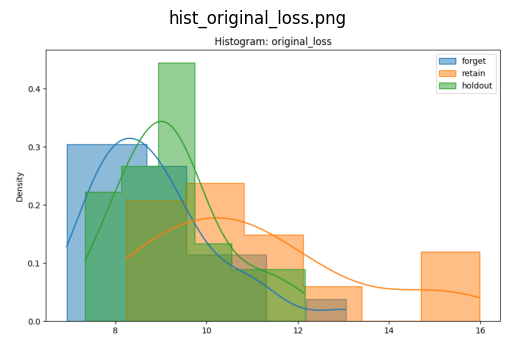

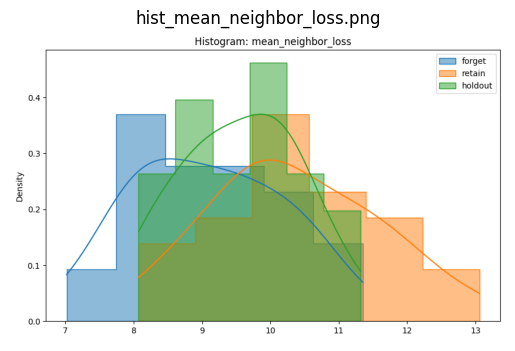

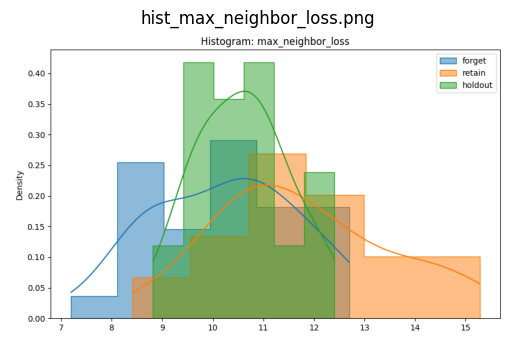

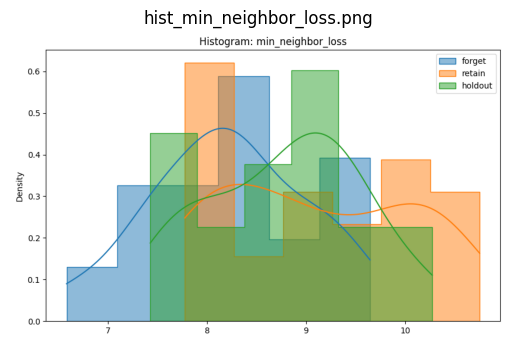

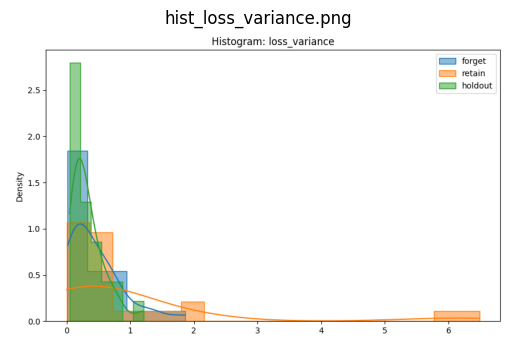

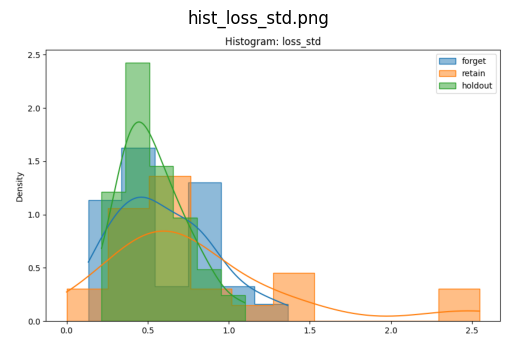

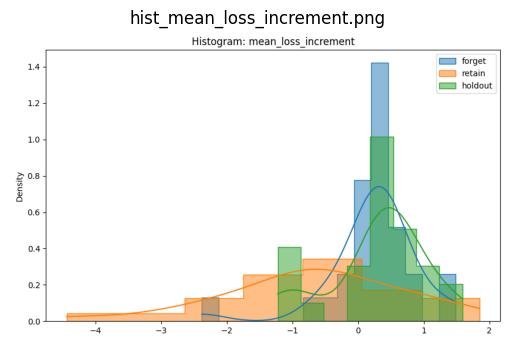

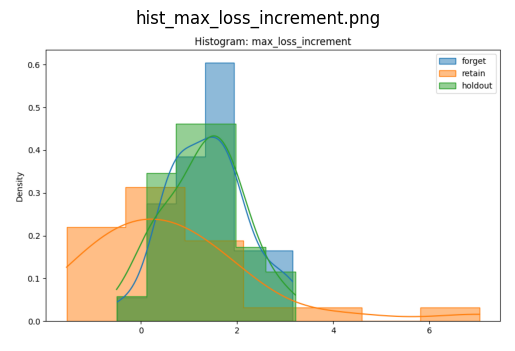

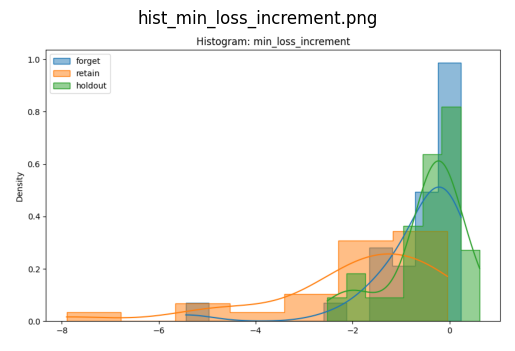

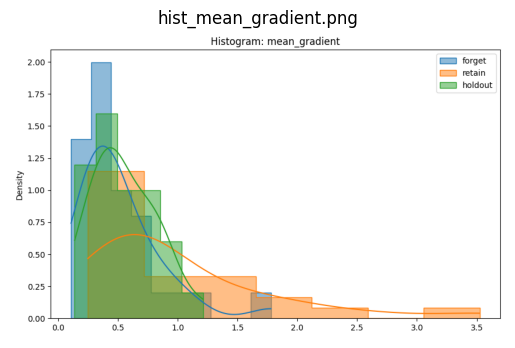

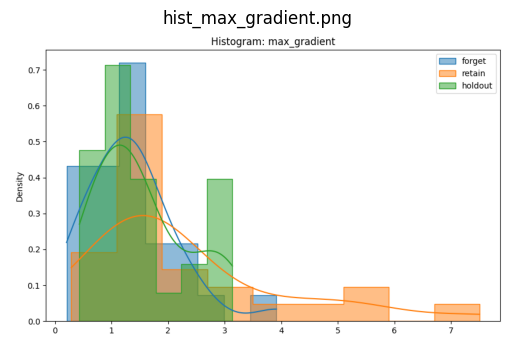

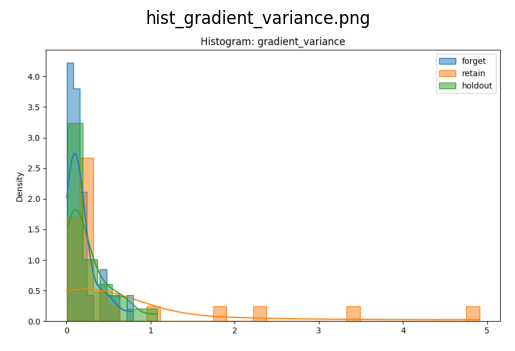

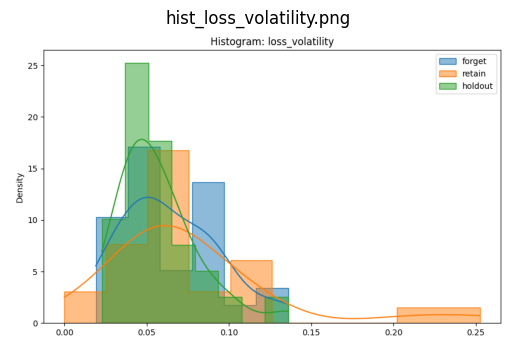

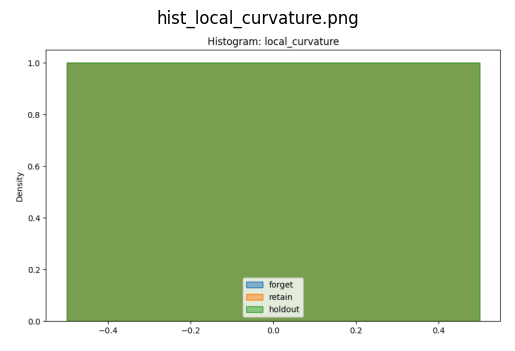

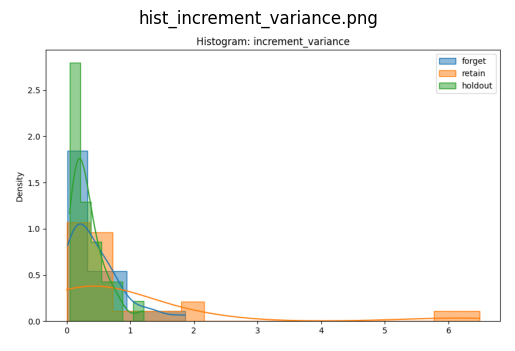

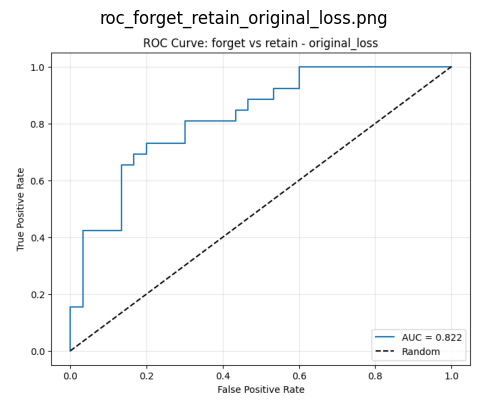

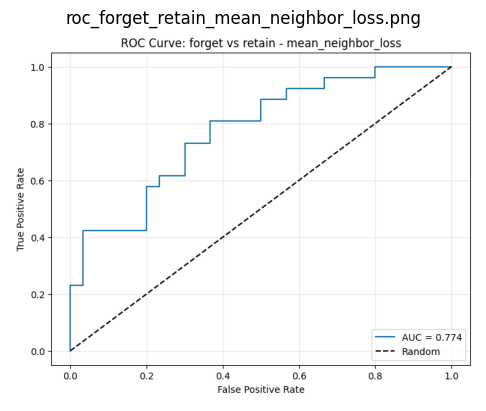

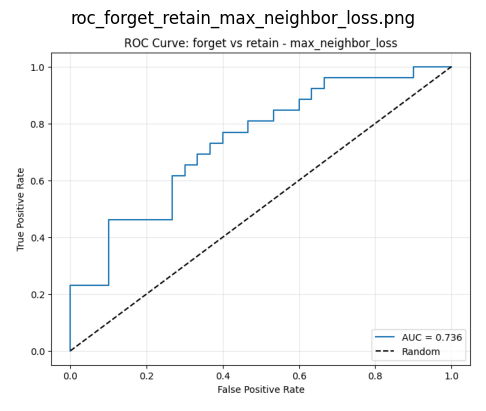

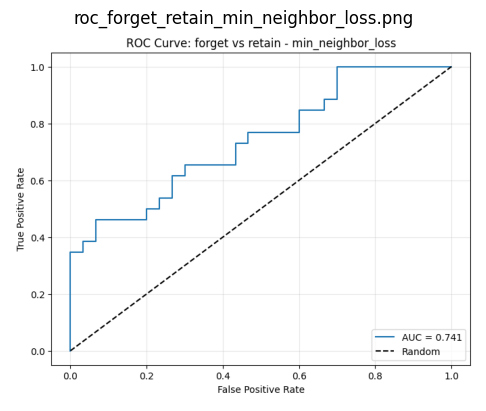

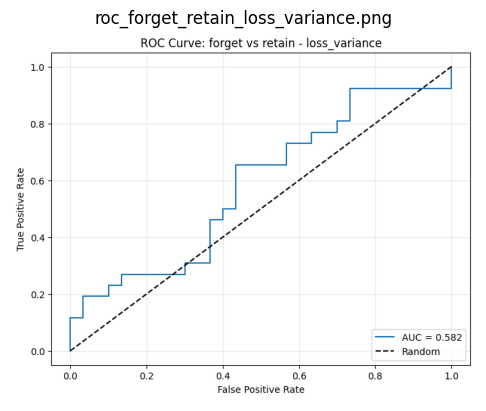

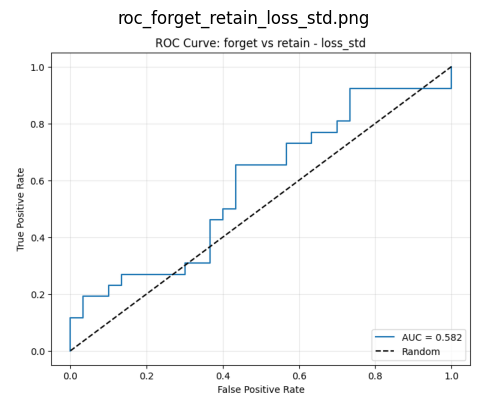

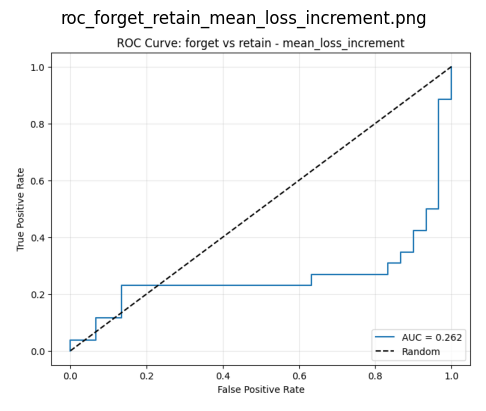

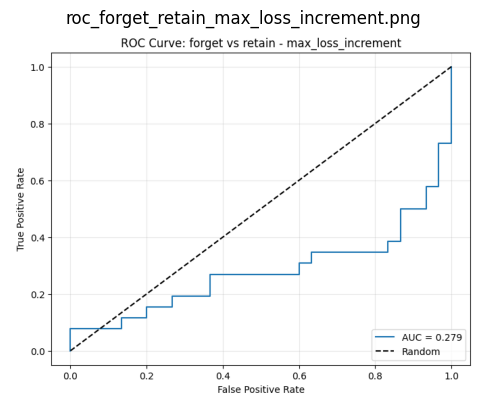

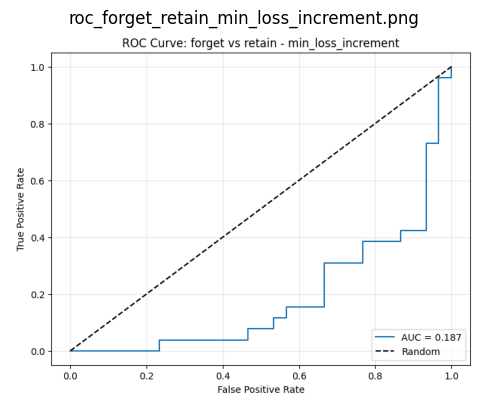

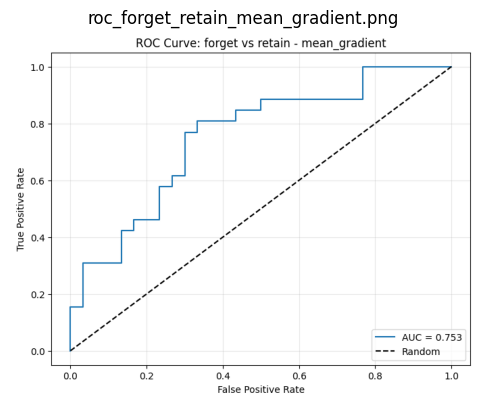

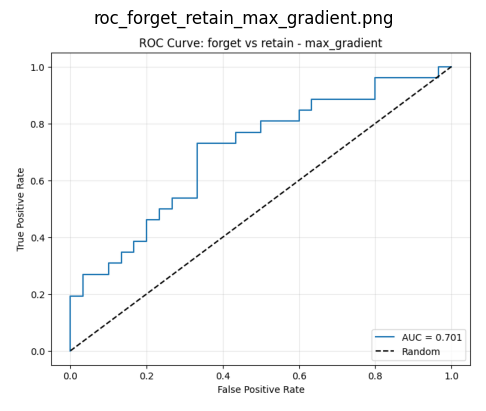

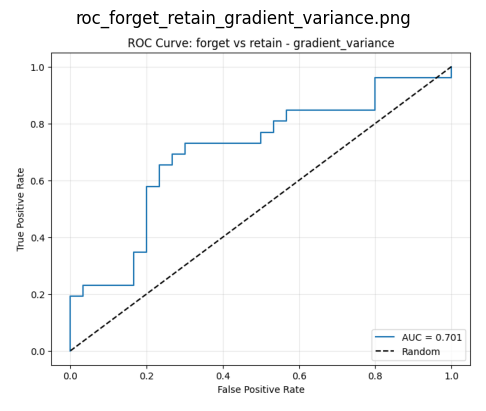

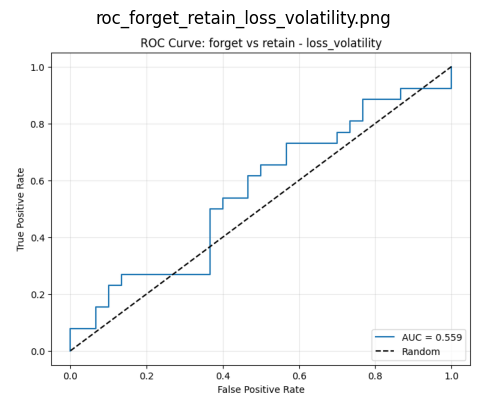

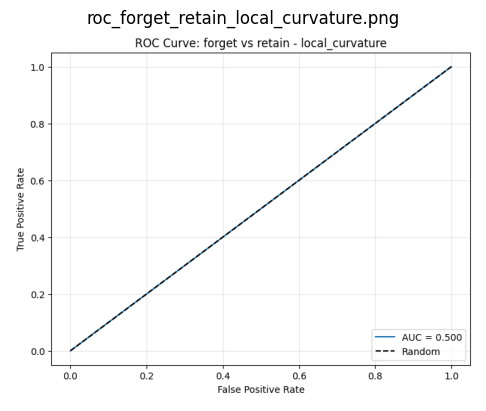

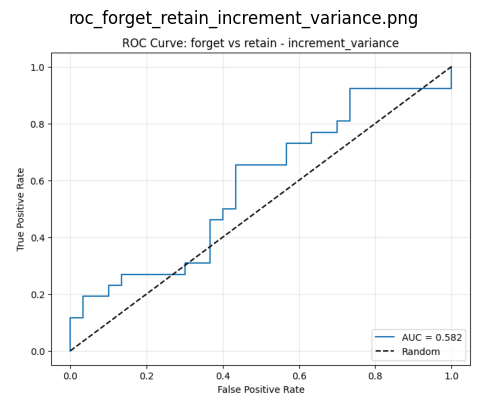

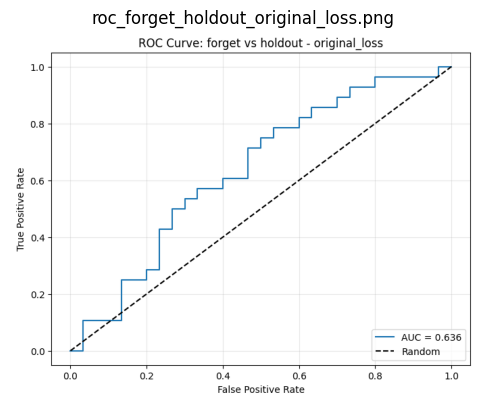

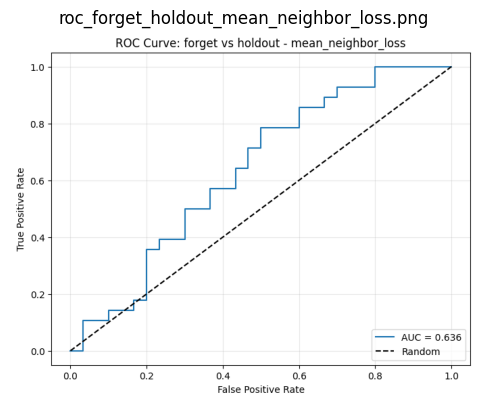

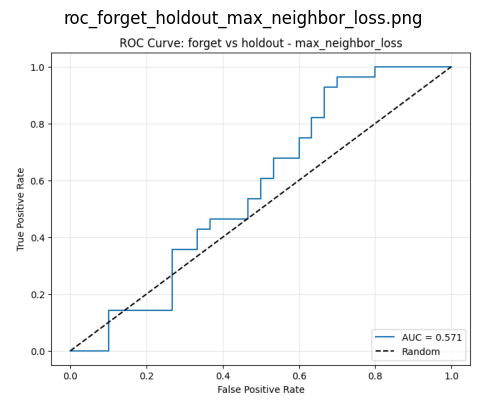

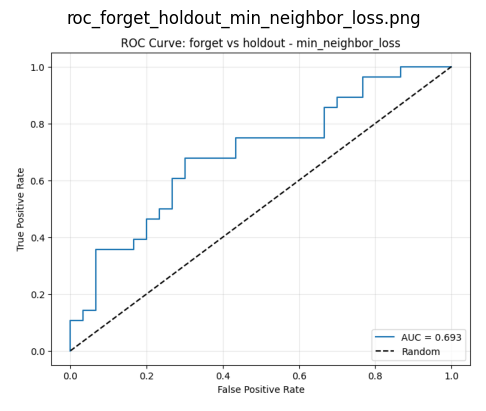

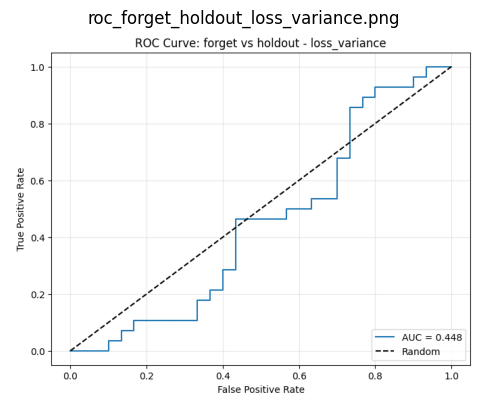

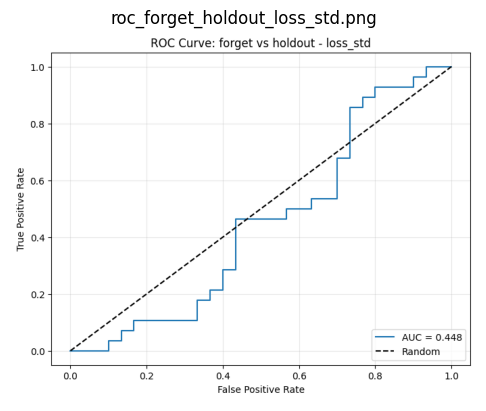

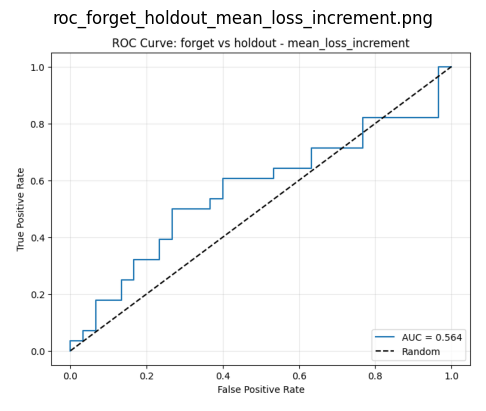

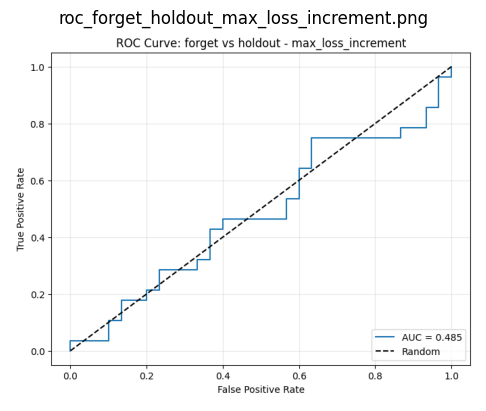

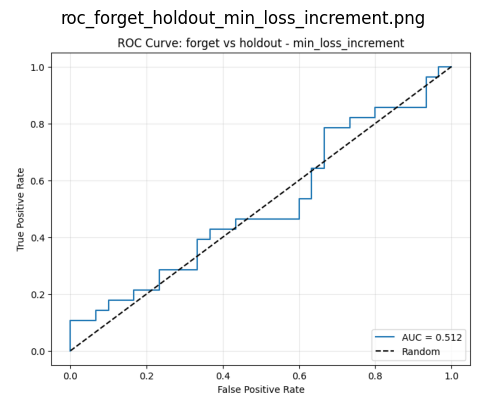

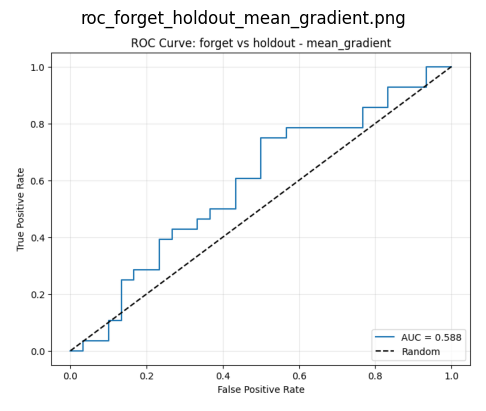

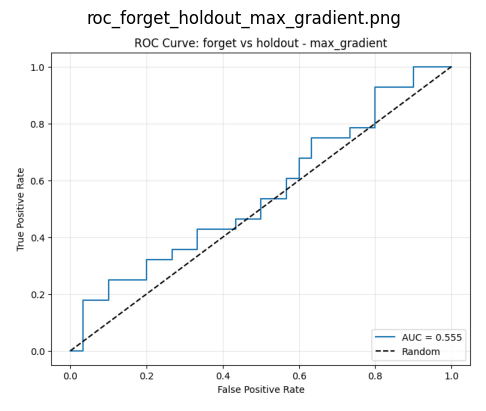

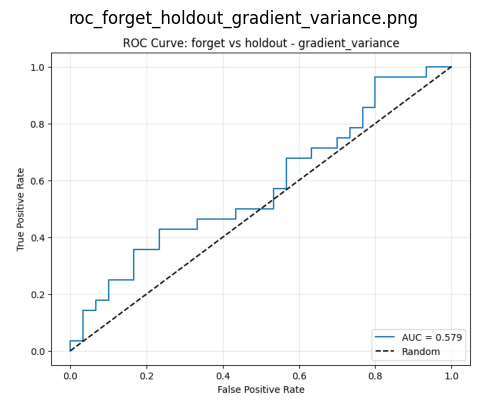

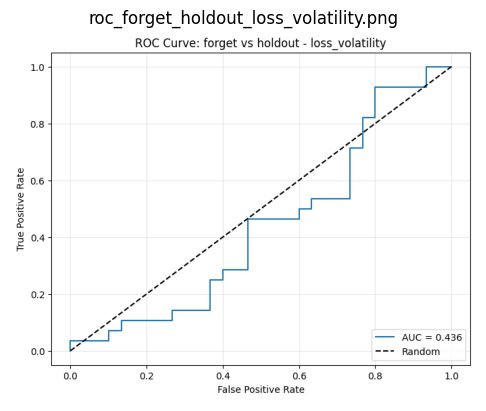

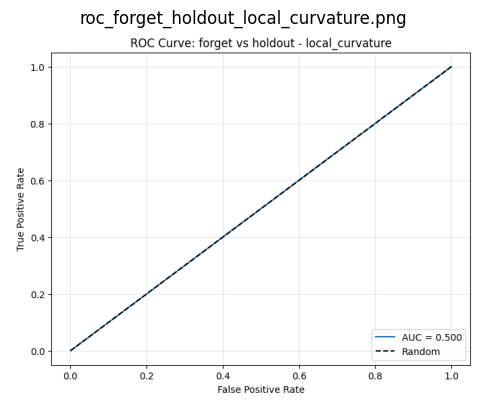

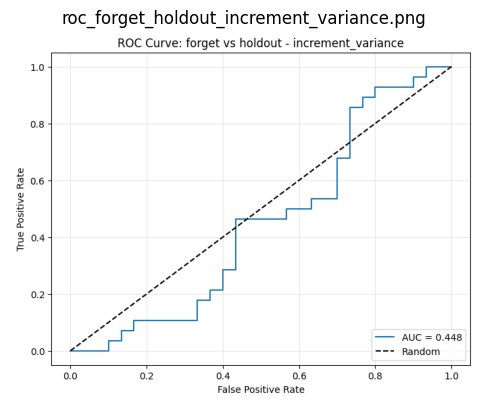

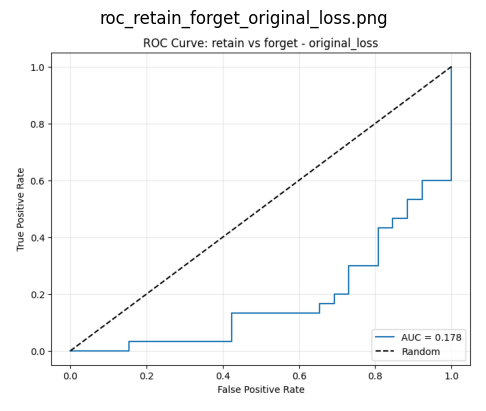

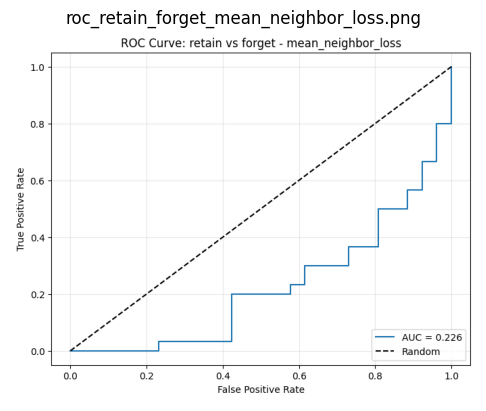

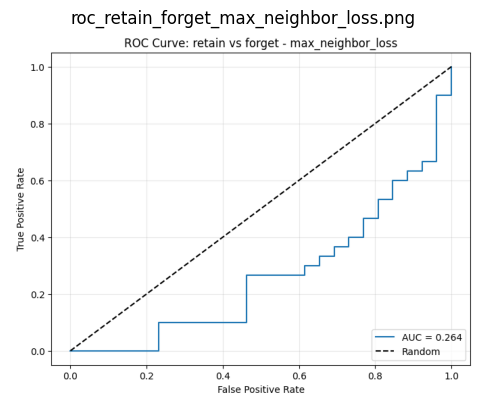

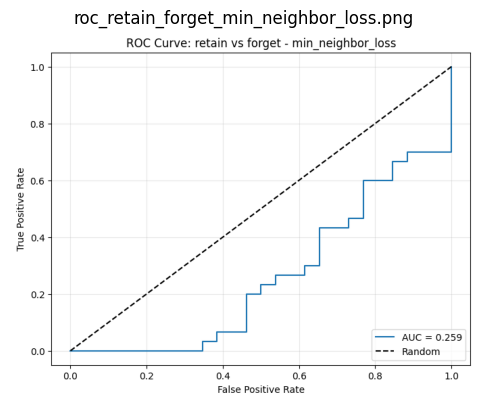

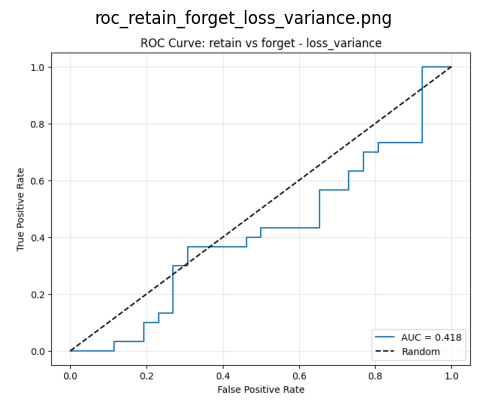

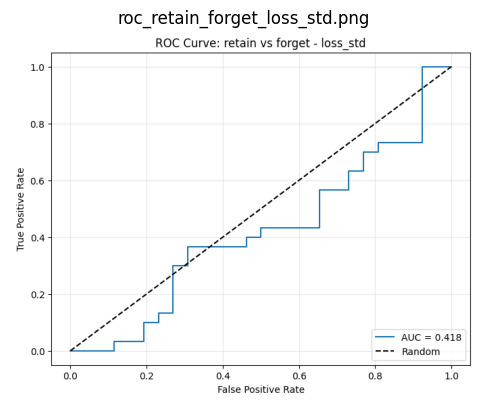

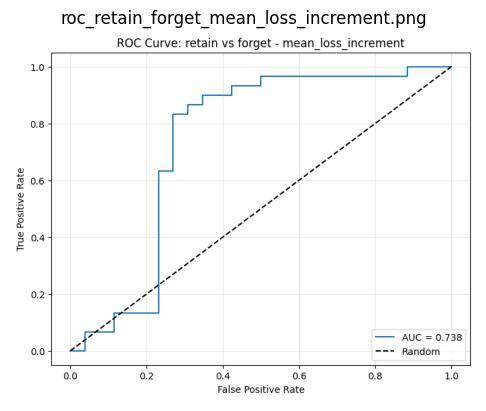

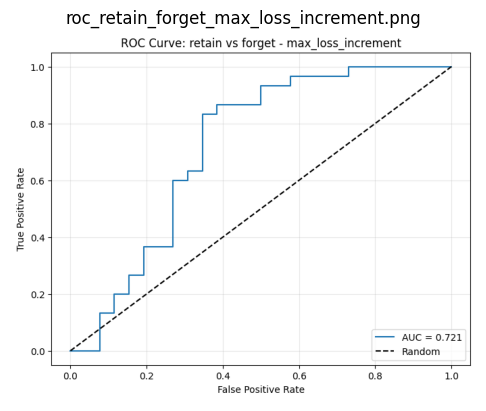

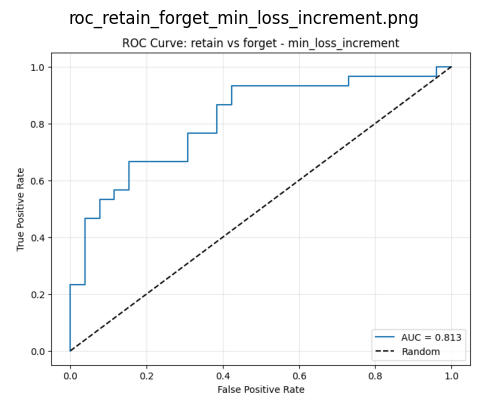

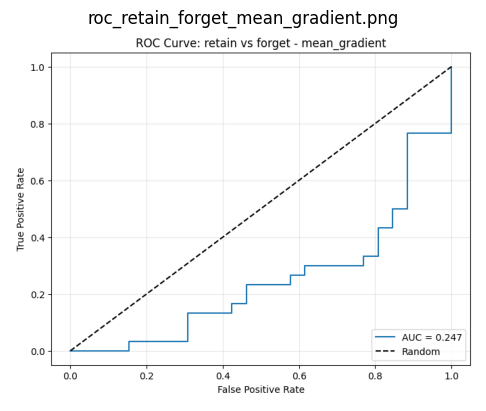

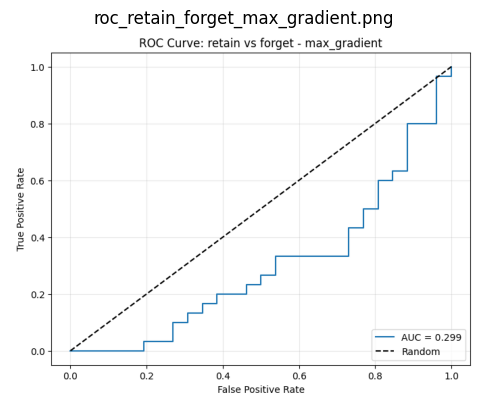

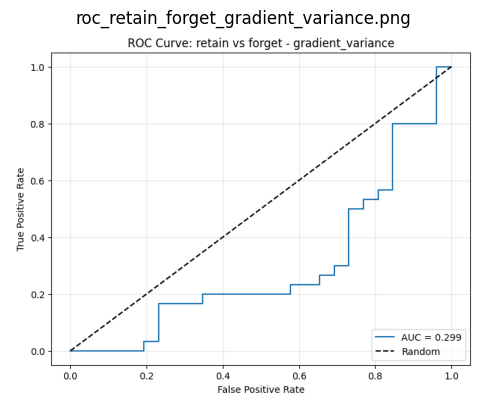

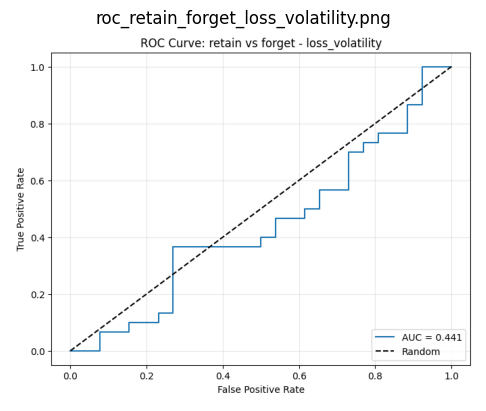

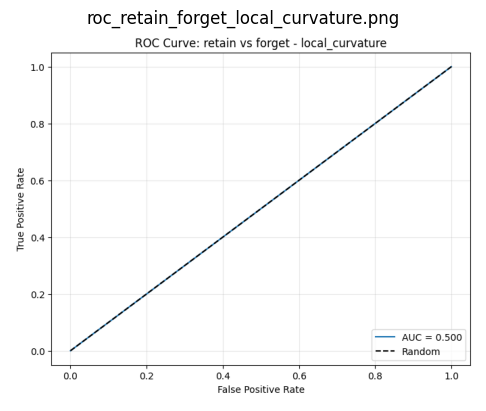

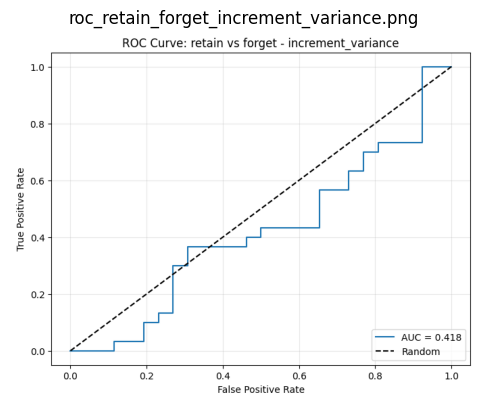

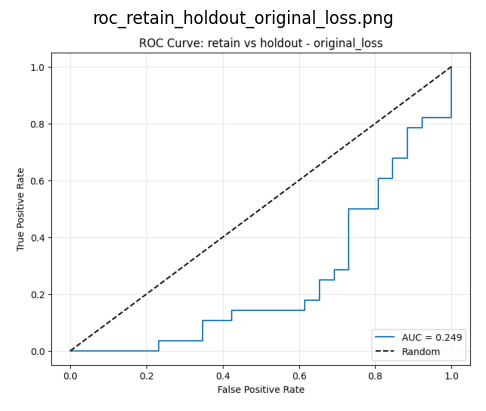

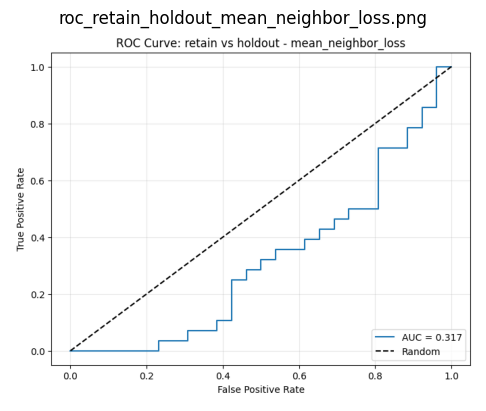

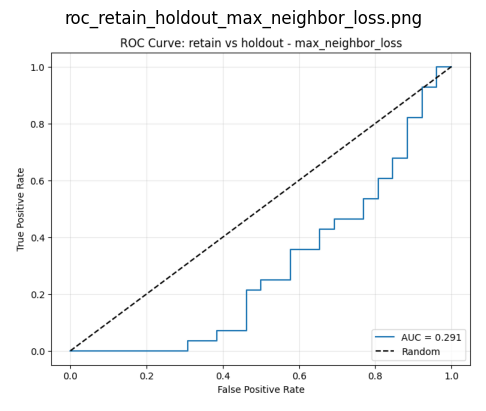

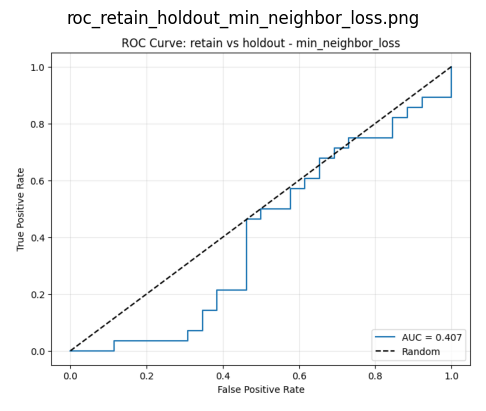

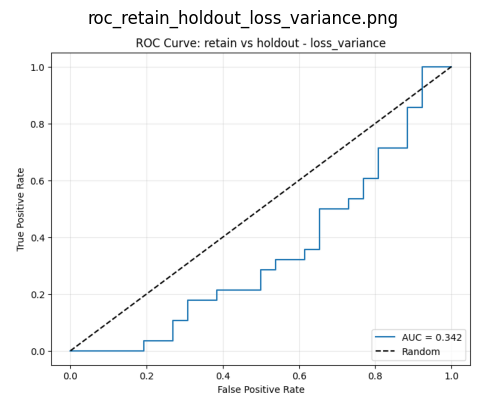

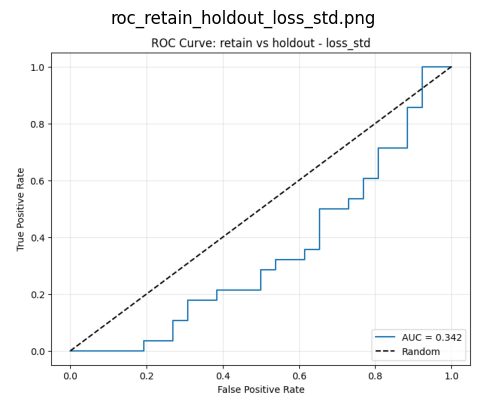

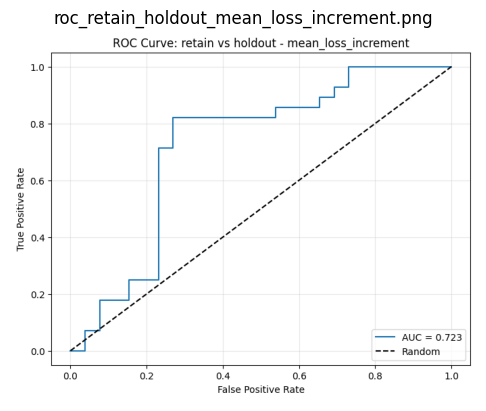

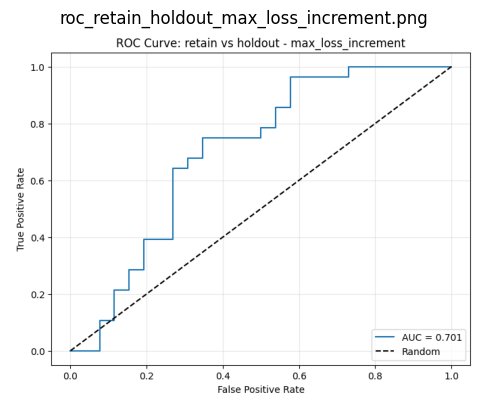

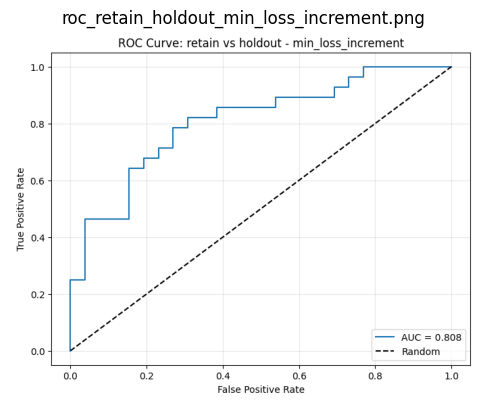

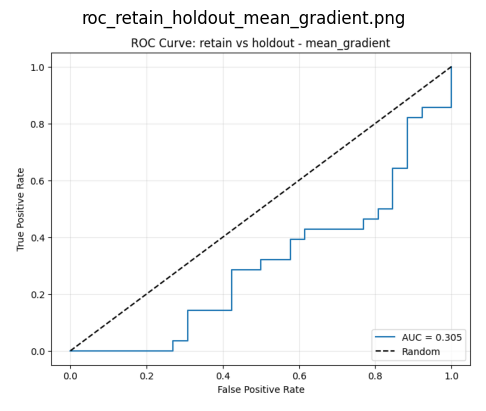

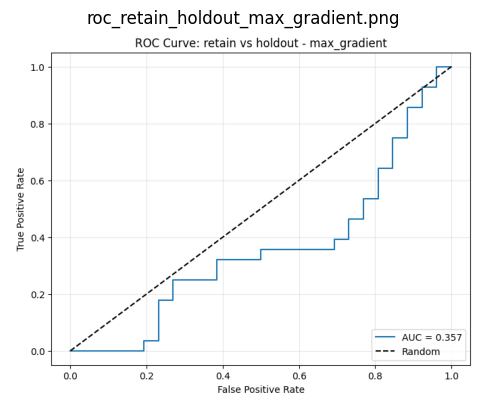

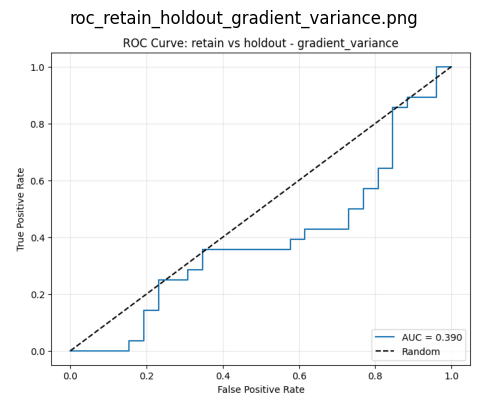

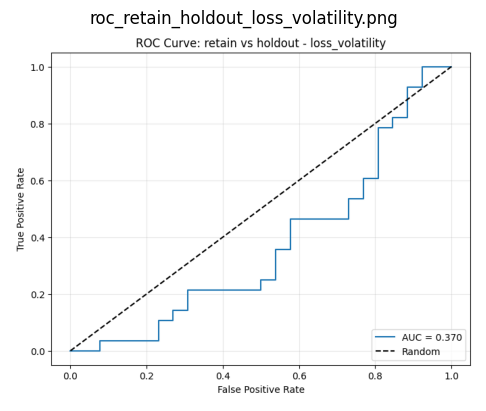

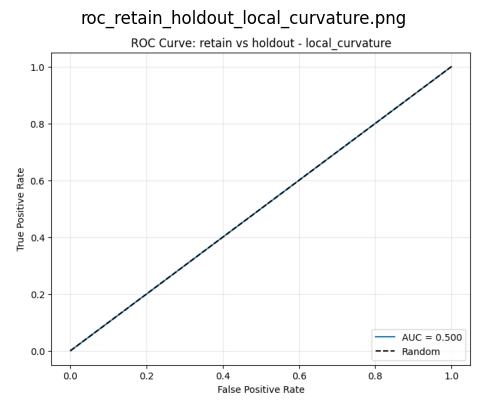

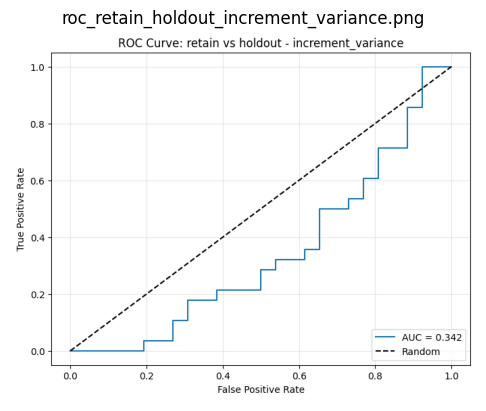

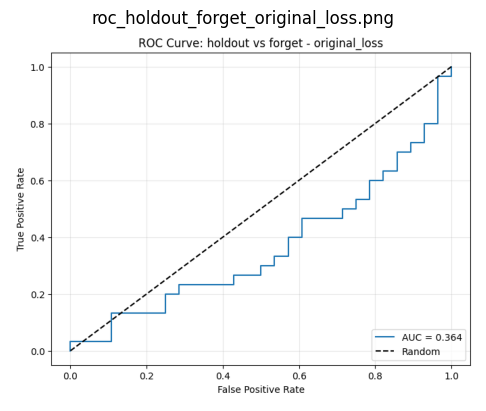

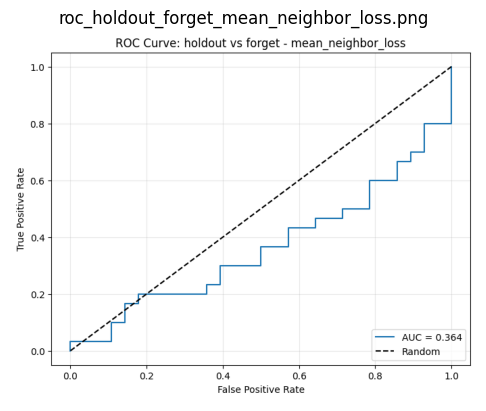

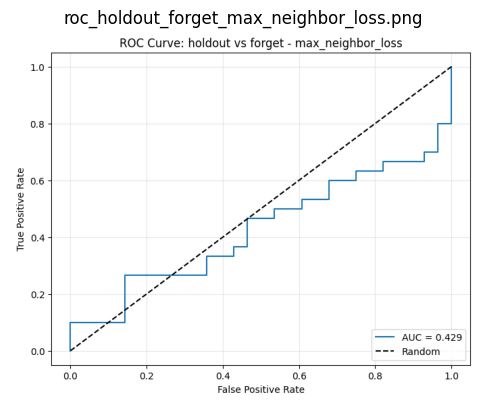

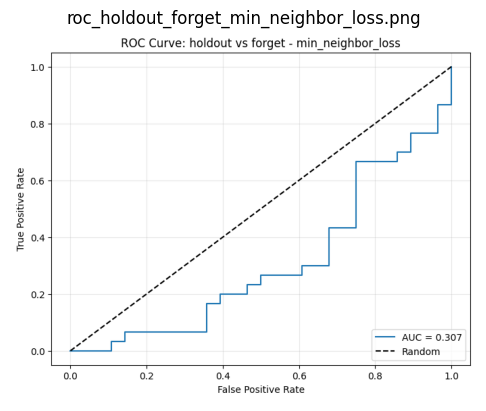

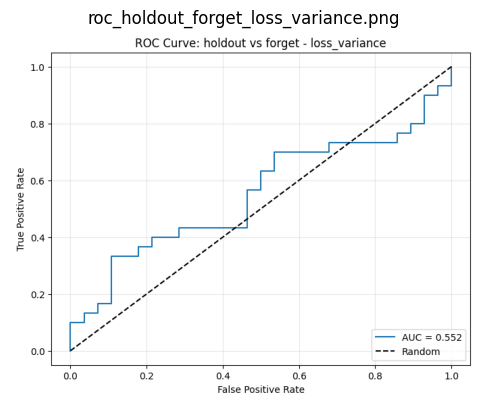

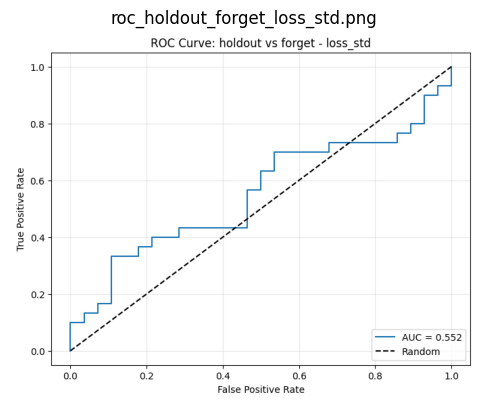

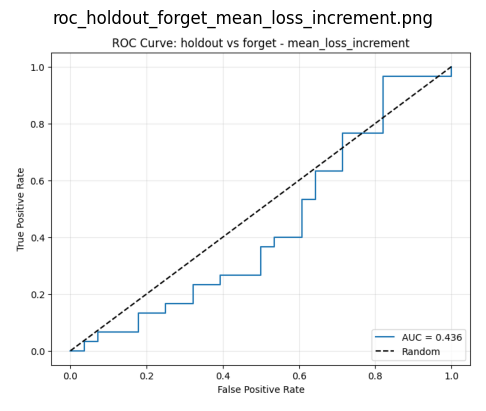

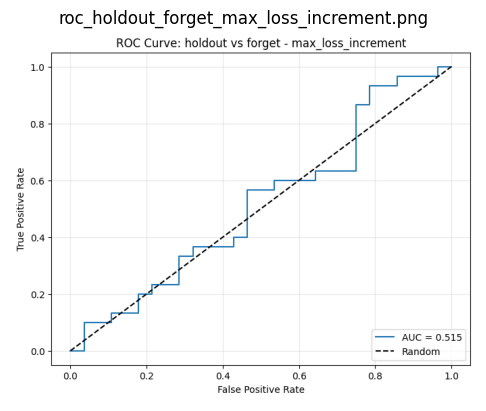

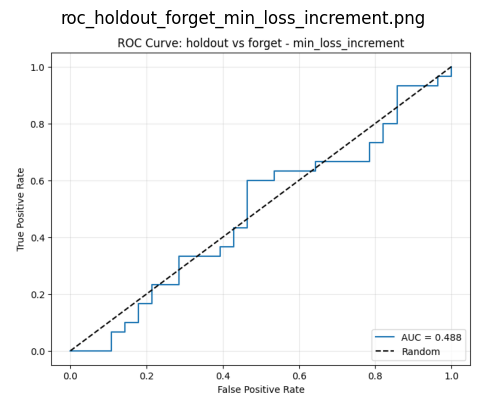

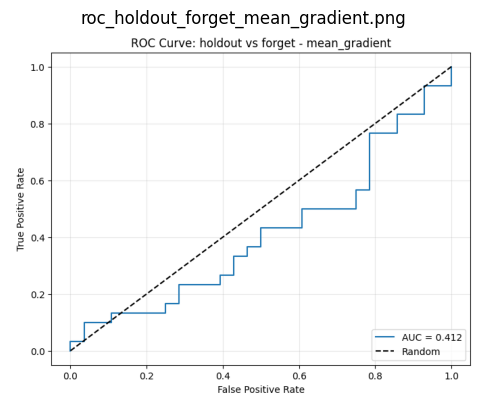

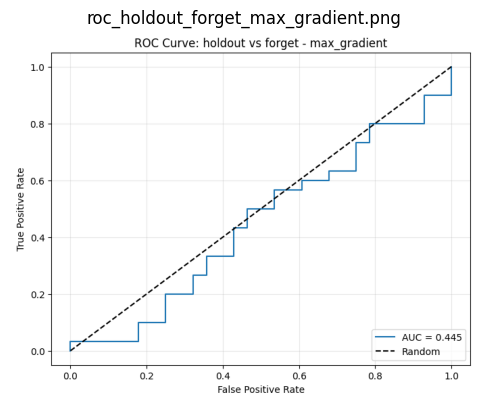

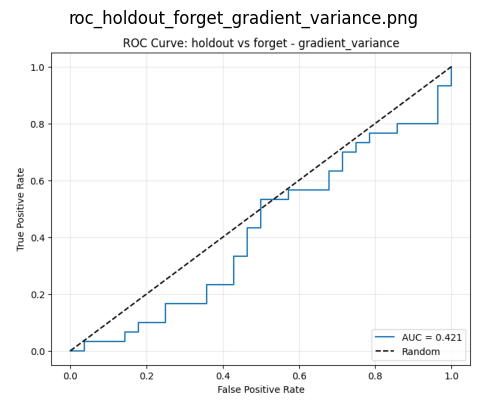

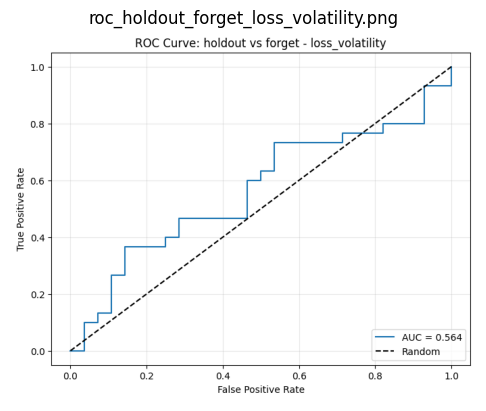

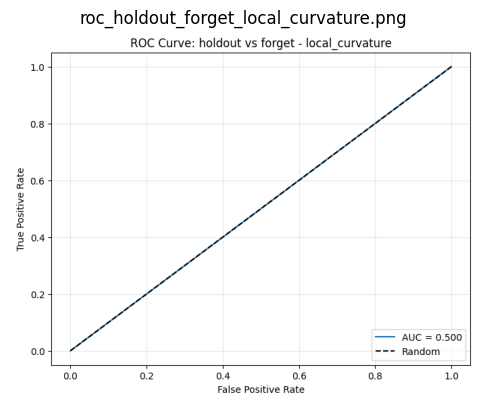

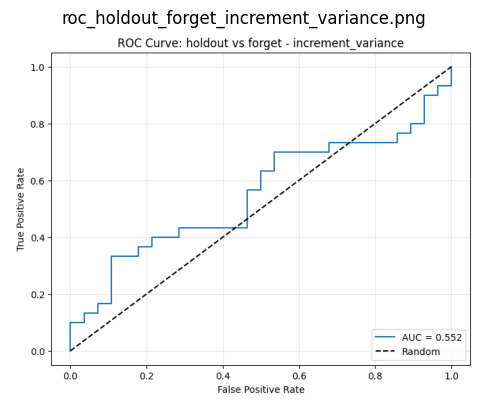

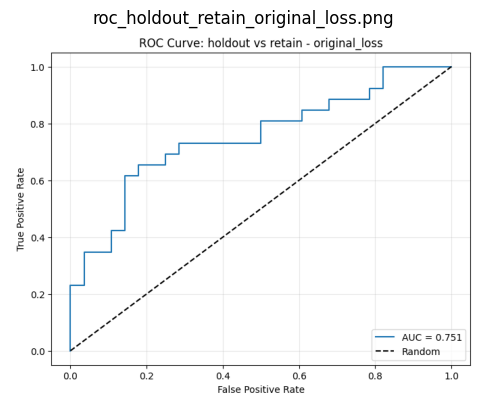

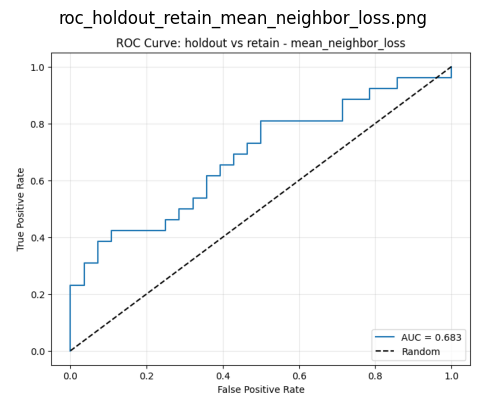

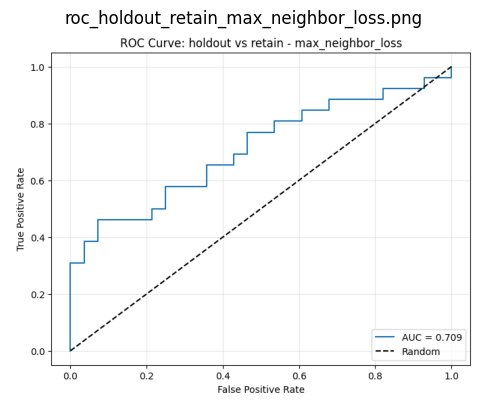

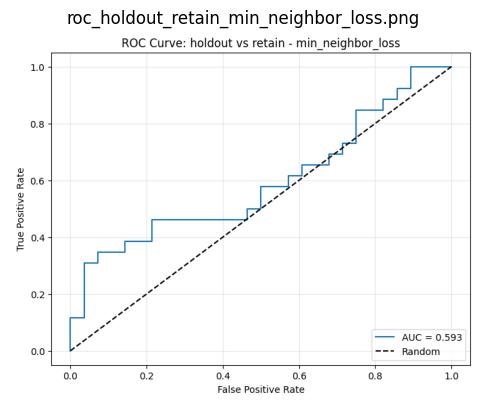

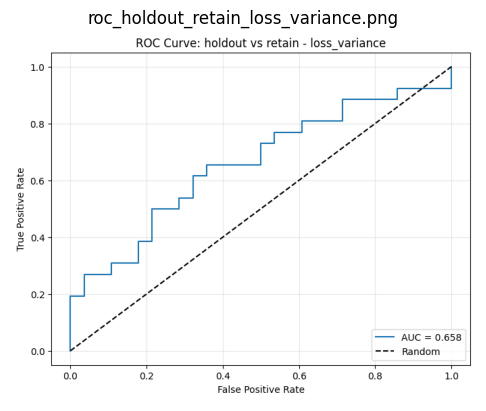

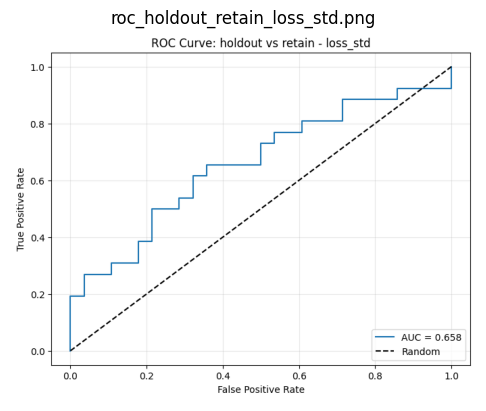

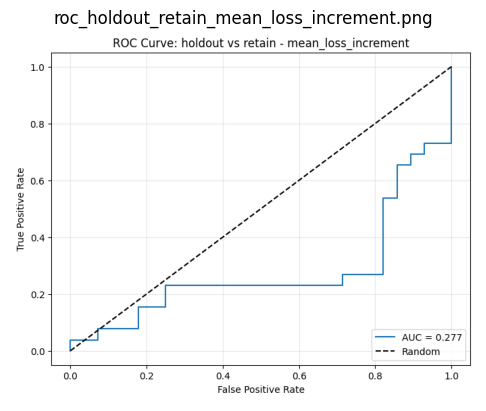

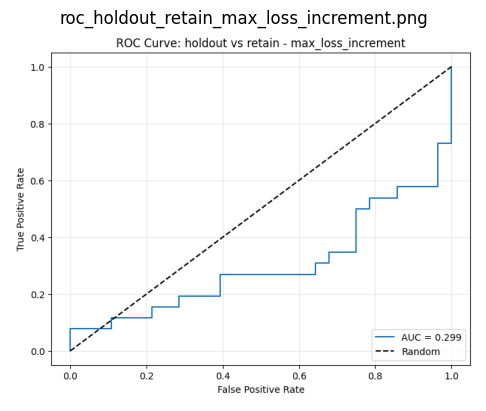

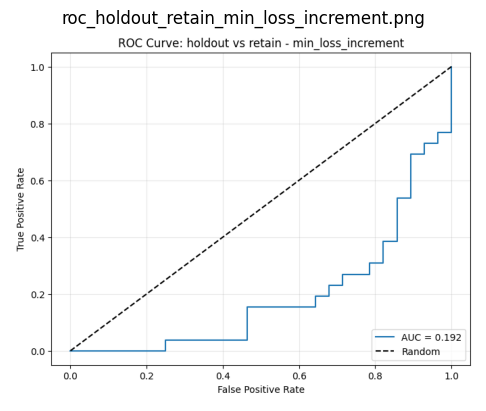

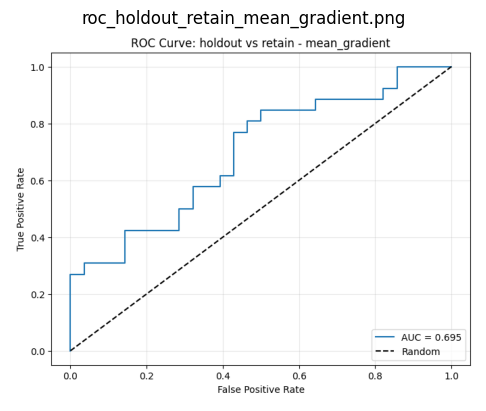

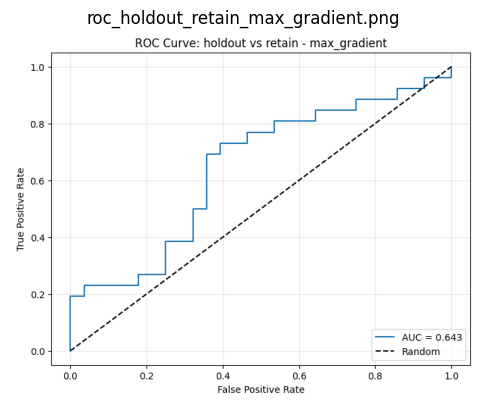

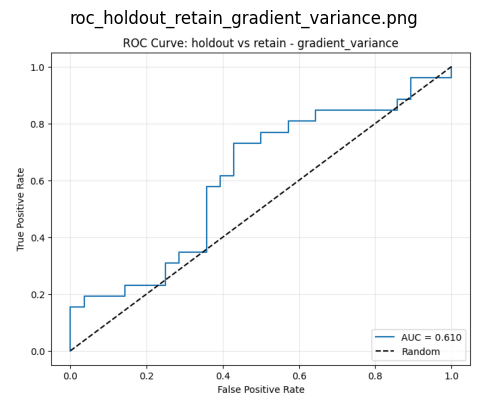

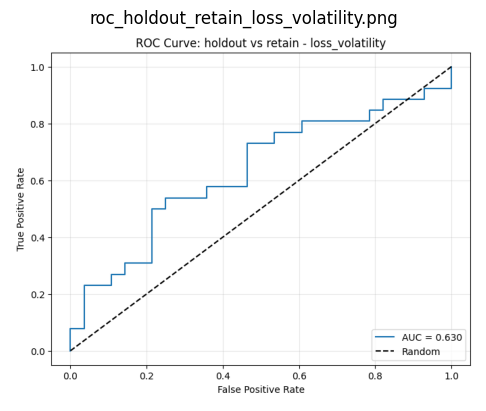

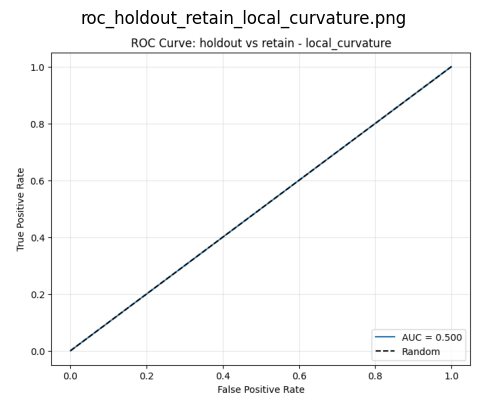

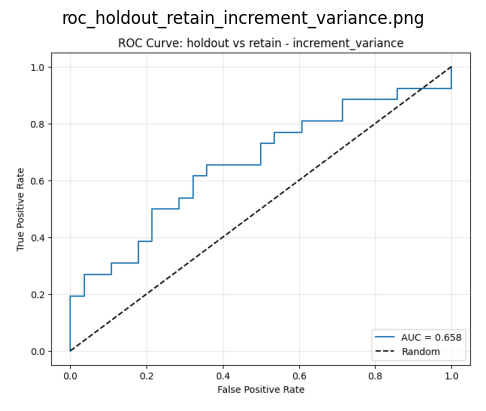

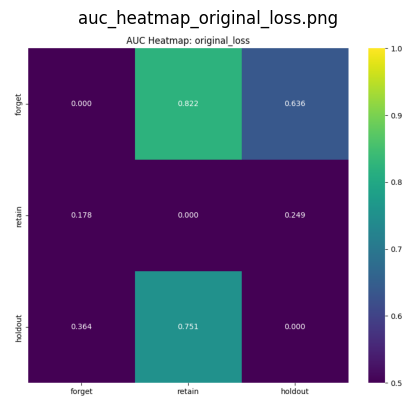

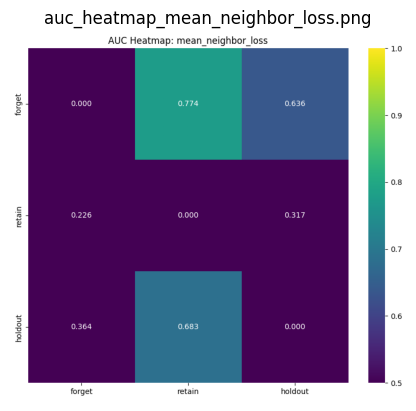

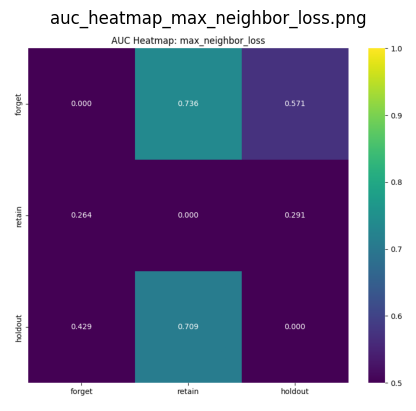

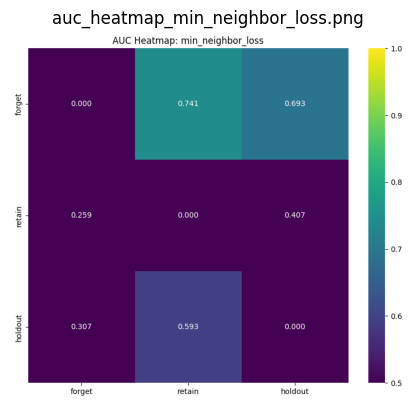

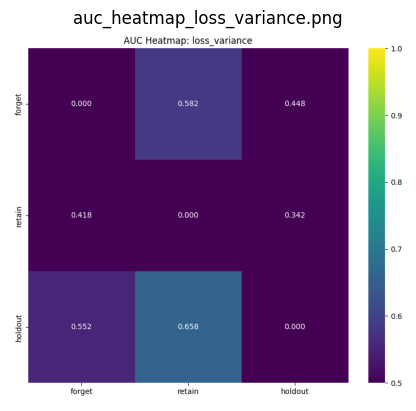

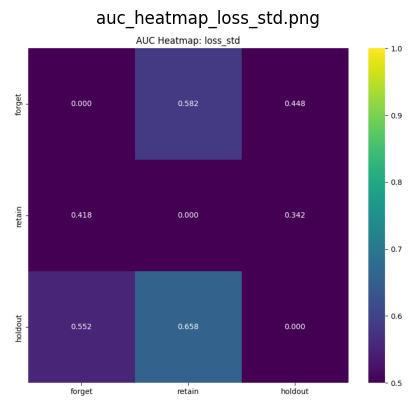

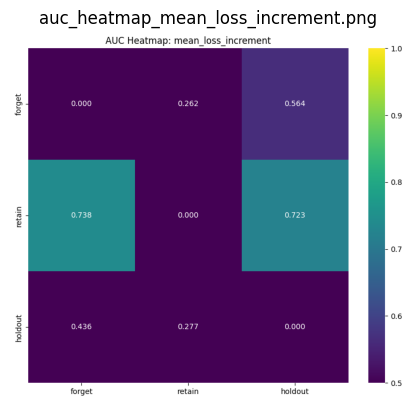

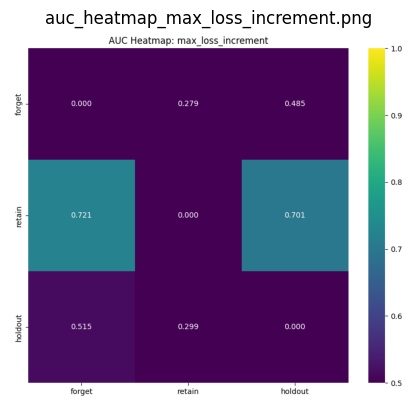

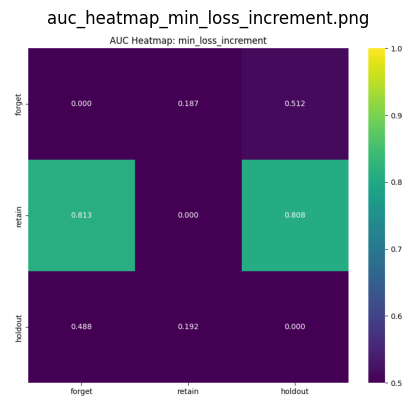

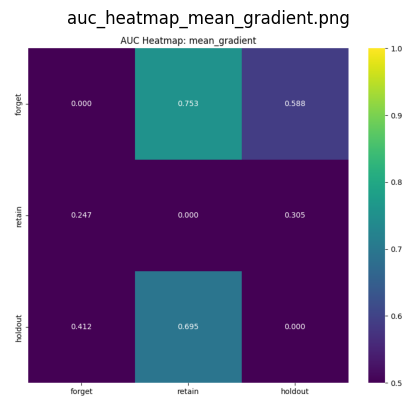

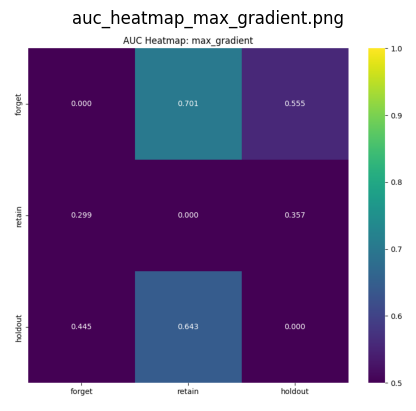

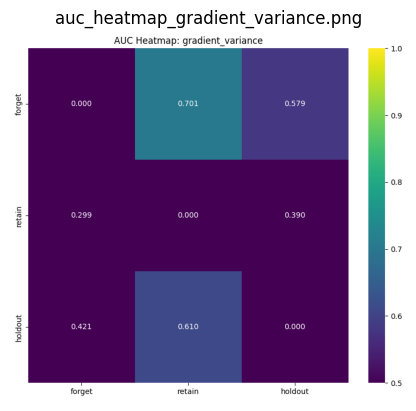

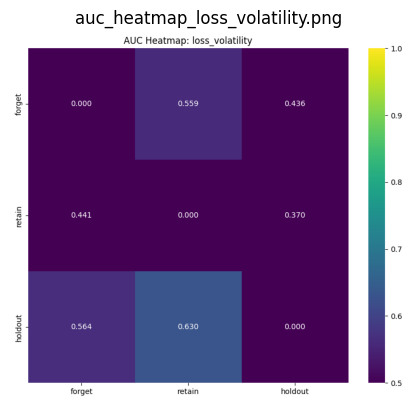

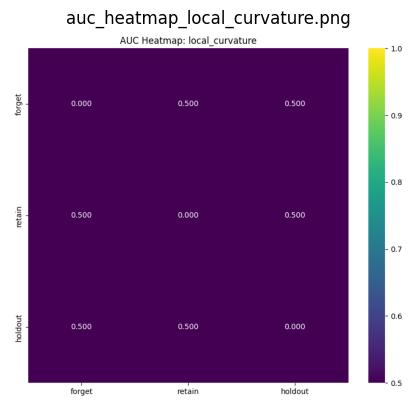

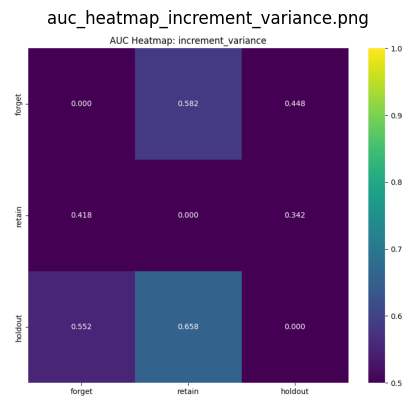

In [12]:
def show_plots(plots: dict):
    import matplotlib.pyplot as plt
    import matplotlib.image as mpimg
    if plots:
        for _, plt_obj in plots.items():
            if isinstance(plt_obj, dict):
                show_plots(plt_obj)
            elif isinstance(plt_obj, str) and os.path.isfile(plt_obj):
                img = mpimg.imread(plt_obj)
                plt.figure()
                plt.imshow(img)
                plt.axis('off')
                plt.title(os.path.basename(plt_obj))
                plt.show()

                
show_plots(plots)

In [13]:
forget_tensor = features_dict['forget']['unnormalized_features_tensor']
retain_tensor = features_dict['retain']['unnormalized_features_tensor']
holdout_tensor = features_dict['holdout']['unnormalized_features_tensor']

def normalize_features(t1, t2=None, t3=None):
    """
    Normalize one or multiple feature tensors using the overall mean and standard deviation
    across all tensors. Each feature is normalized to have zero mean and unit variance.

    Args:
        t1 (torch.Tensor): First input tensor of shape (num_samples, num_features).
        t2 (torch.Tensor, optional): Second input tensor of shape (num_samples, num_features).
        t3 (torch.Tensor, optional): Third input tensor of shape (num_samples, num_features).

    Returns:
        tuple: Normalized tensors in the same order as the inputs.
    """
    # Concatenate all tensors to compute the overall mean and std
    tensors = [t for t in [t1, t2, t3] if t is not None]
    combined = torch.cat(tensors, dim=0)
    
    # Compute overall mean and std
    mean = combined.mean(dim=0, keepdim=True)
    std = combined.std(dim=0, keepdim=True)
    # Avoid division by zero
    std[std == 0] = 1

    # Normalize each tensor using the overall mean and std
    def normalize(t):
        return (t - mean) / std

    normalized_t1 = normalize(t1)
    normalized_t2 = normalize(t2) if t2 is not None else None
    normalized_t3 = normalize(t3) if t3 is not None else None

    return normalized_t1, normalized_t2, normalized_t3

norm_forget_tensor, norm_retain_tensor, norm_holdout_tensor = normalize_features(forget_tensor, retain_tensor, holdout_tensor)

In [14]:
def train_predictors(retain_t, holdout_t, features_labels, forget_t=None):
    """
    Train membership inference classifiers for the provided tensors.

    Args:
        retain_t (torch.Tensor): Tensor for the retain set of shape (num_samples, num_features).
        holdout_t (torch.Tensor): Tensor for the holdout set of shape (num_samples, num_features).
        features_labels (list): List of feature names corresponding to the tensor columns.
        forget_t (torch.Tensor, optional): Tensor for the forget set of shape (num_samples, num_features).

    Returns:
        dict: Results, including trained classifiers, performance metrics, and feature importances.
    """
    results = {}
    feature_importance_results = {}

    # Prepare datasets
    datasets = {
        'retain': retain_t,
        'holdout': holdout_t
    }
    if forget_t is not None:
        datasets['forget'] = forget_t

    # Combine all datasets into a single tensor and create labels
    tensors = []
    labels = []
    for i, (split, tensor) in enumerate(datasets.items()):
        tensors.append(tensor)
        labels.append(torch.full((len(tensor),), i))  # Assign class index as label

    X = torch.cat(tensors, dim=0).numpy()
    y = torch.cat(labels, dim=0).numpy()

    # Split data
    print("Splitting data...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

    # Train classifiers
    print("\n--- Training Classifiers for Multi-Class Classification ---")
    results['multi_class'] = {}

    # Logistic Regression
    print("Training Logistic Regression...")
    clf_logistic = LogisticRegression(random_state=42, max_iter=300, multi_class='multinomial', solver='lbfgs')
    clf_logistic.fit(X_train, y_train)

    # Evaluate Logistic Regression
    y_pred_logistic = clf_logistic.predict(X_test)
    accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
    f1_logistic = f1_score(y_test, y_pred_logistic, average='weighted')
    roc_auc_logistic = roc_auc_score(y_test, clf_logistic.predict_proba(X_test), multi_class='ovr')

    print(f"Logistic Regression: Accuracy={accuracy_logistic:.3f}, F1={f1_logistic:.3f}, ROC AUC={roc_auc_logistic:.3f}")

    # Store Logistic Regression results
    results['multi_class']['logistic'] = {
        'accuracy': accuracy_logistic,
        'f1': f1_logistic,
        'roc_auc': roc_auc_logistic,
        'model': clf_logistic
    }

    # Feature Importance for Logistic Regression
    importance_logistic = abs(clf_logistic.coef_).mean(axis=0)
    importance_logistic = importance_logistic / np.sum(importance_logistic)

    logistic_feature_importance = pd.DataFrame({
        'feature': features_labels,
        'importance': importance_logistic
    }).sort_values('importance', ascending=False)

    feature_importance_results['multi_class_logistic'] = logistic_feature_importance

    # Random Forest
    print("Training Random Forest...")
    clf_rf = RandomForestClassifier(random_state=42, n_estimators=100)
    clf_rf.fit(X_train, y_train)

    # Evaluate Random Forest
    y_pred_rf = clf_rf.predict(X_test)
    accuracy_rf = accuracy_score(y_test, y_pred_rf)
    f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
    roc_auc_rf = roc_auc_score(y_test, clf_rf.predict_proba(X_test), multi_class='ovr')

    print(f"Random Forest: Accuracy={accuracy_rf:.3f}, F1={f1_rf:.3f}, ROC AUC={roc_auc_rf:.3f}")

    # Store Random Forest results
    results['multi_class']['random_forest'] = {
        'accuracy': accuracy_rf,
        'f1': f1_rf,
        'roc_auc': roc_auc_rf,
        'model': clf_rf
    }

    # Feature Importance for Random Forest
    importance_rf = clf_rf.feature_importances_
    importance_rf = importance_rf / np.sum(importance_rf)

    rf_feature_importance = pd.DataFrame({
        'feature': features_labels,
        'importance': importance_rf
    }).sort_values('importance', ascending=False)

    feature_importance_results['multi_class_rf'] = rf_feature_importance

    return results, feature_importance_results

In [15]:
# use the function
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd

# Get feature labels from the features dictionary
features_labels = features_dict['forget']['features_names']

# Train predictors using normalized tensors
results, feature_importance_results = train_predictors(
    retain_t=norm_retain_tensor,
    holdout_t=norm_holdout_tensor,
    features_labels=features_labels,
    forget_t=norm_forget_tensor
)

print("\n=== Classification Results ===")
for metric in ['accuracy', 'f1', 'roc_auc']:
    print(f"Logistic Regression {metric.upper()}: {results['multi_class']['logistic'][metric]:.3f}")
    print(f"Random Forest {metric.upper()}: {results['multi_class']['random_forest'][metric]:.3f}")
    print()

Splitting data...

--- Training Classifiers for Multi-Class Classification ---
Training Logistic Regression...
Logistic Regression: Accuracy=0.385, F1=0.325, ROC AUC=0.686
Training Random Forest...
Random Forest: Accuracy=0.462, F1=0.449, ROC AUC=0.687

=== Classification Results ===
Logistic Regression ACCURACY: 0.385
Random Forest ACCURACY: 0.462

Logistic Regression F1: 0.325
Random Forest F1: 0.449

Logistic Regression ROC_AUC: 0.686
Random Forest ROC_AUC: 0.687



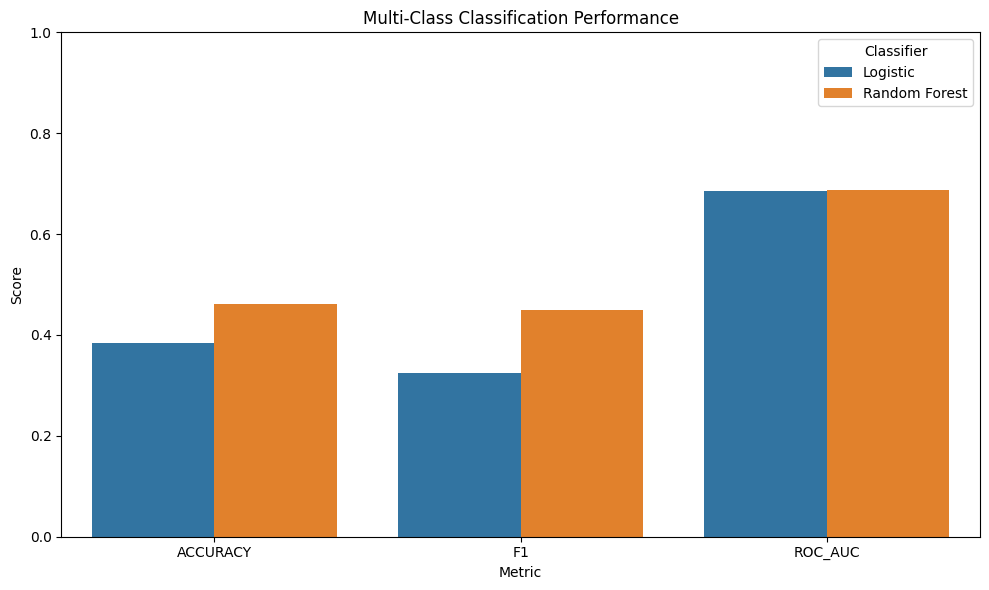

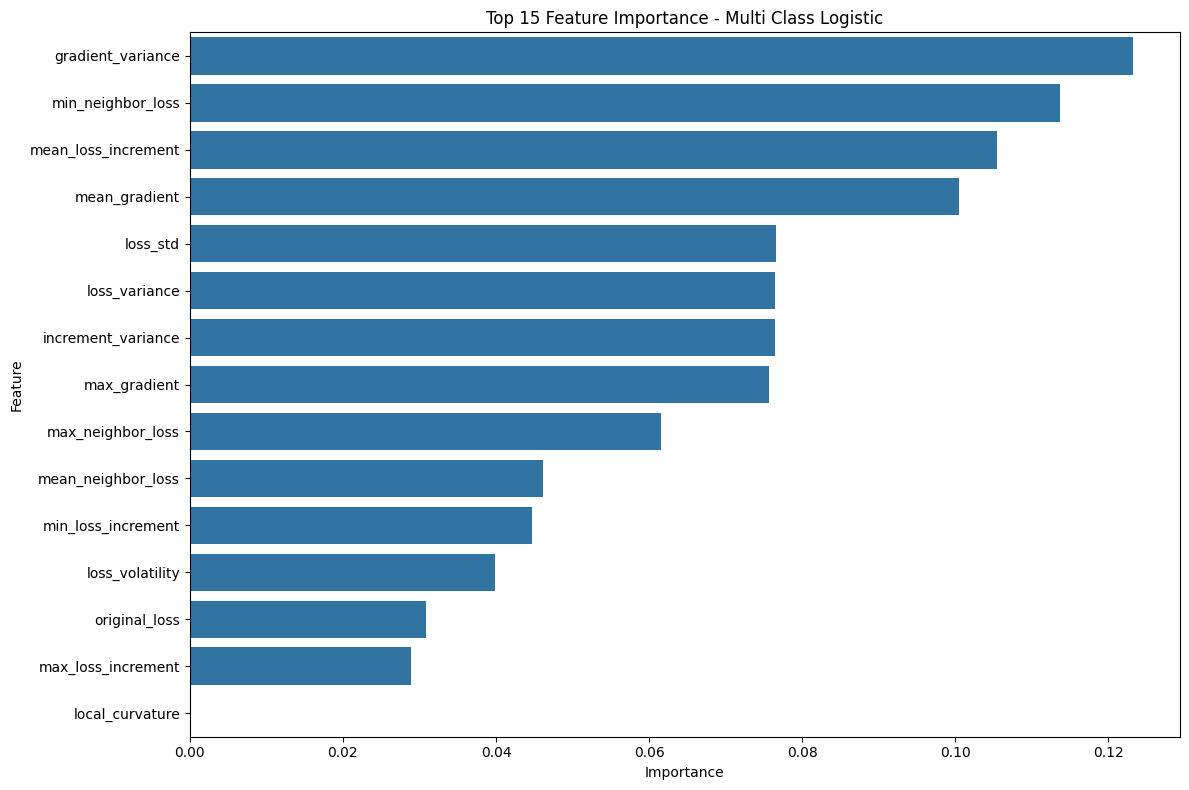

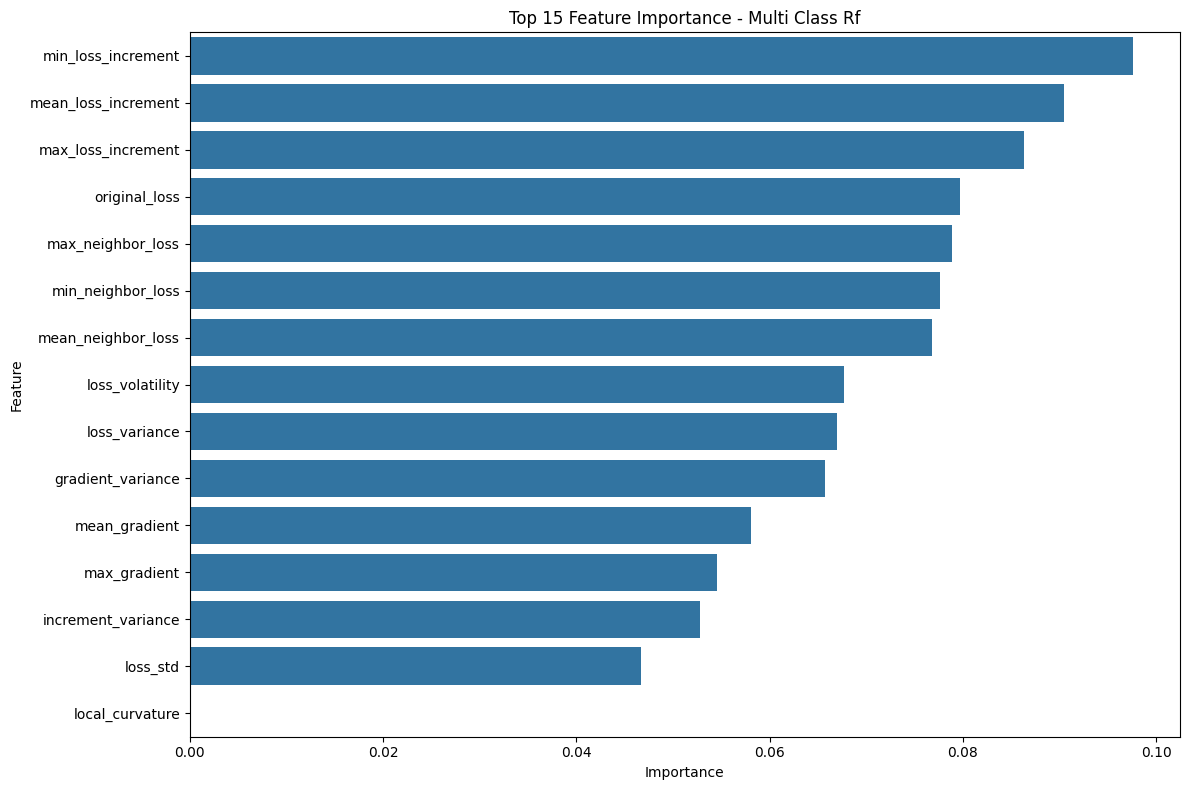


Top Features Analysis:
Common top-10 features across classifiers: 6
Total unique top-10 features: 14
Common features: ['loss_variance', 'max_neighbor_loss', 'gradient_variance', 'min_neighbor_loss', 'mean_loss_increment']...


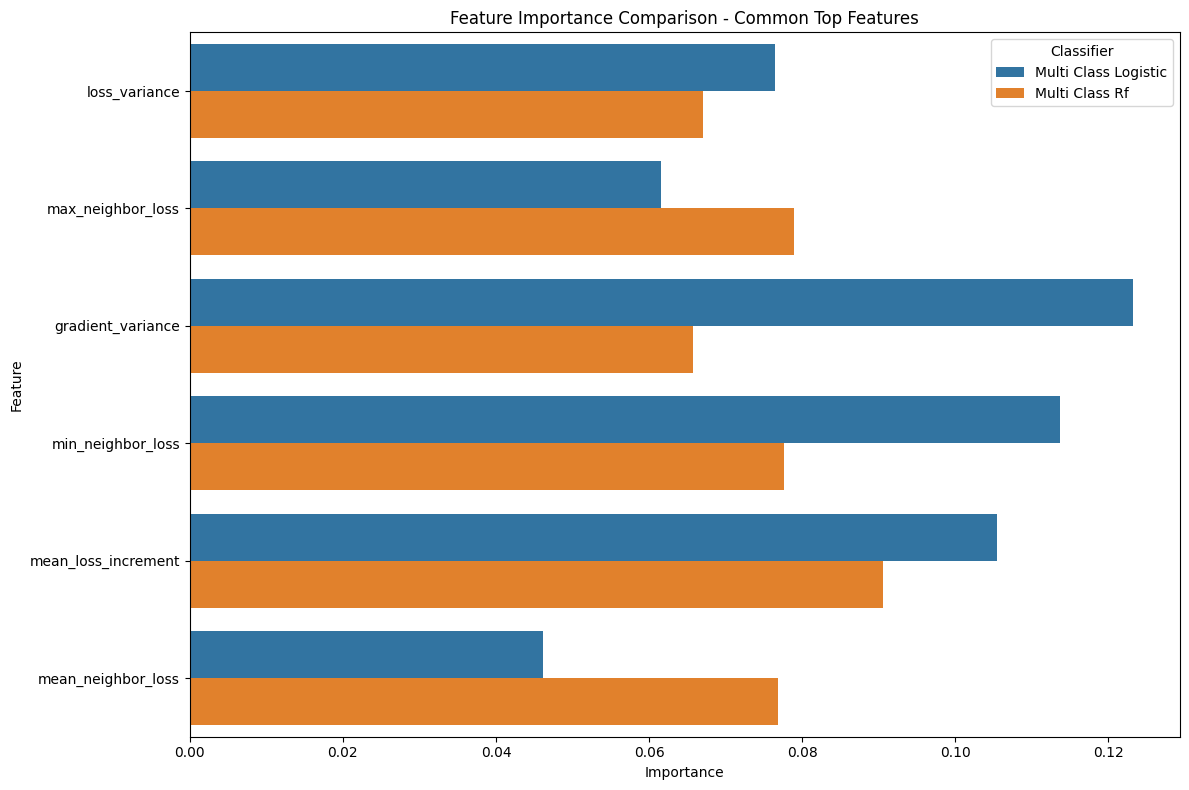

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_classification_results(results, feature_importance_results, save_dir="classification_plots"):
    """
    Plot classification results including performance metrics and feature importance.
    """
    os.makedirs(save_dir, exist_ok=True)
    plots = {}
    
    # 1. Performance Metrics Comparison
    metrics = ['accuracy', 'f1', 'roc_auc']
    classifiers = ['logistic', 'random_forest']
    
    # Extract performance data
    performance_data = []
    for clf in classifiers:
        for metric in metrics:
            performance_data.append({
                'Classifier': clf.replace('_', ' ').title(),
                'Metric': metric.upper(),
                'Score': results['multi_class'][clf][metric]
            })
    
    performance_df = pd.DataFrame(performance_data)
    
    # Plot performance comparison
    plt.figure(figsize=(10, 6))
    sns.barplot(data=performance_df, x='Metric', y='Score', hue='Classifier')
    plt.title('Multi-Class Classification Performance')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.legend(title='Classifier')
    plt.tight_layout()
    
    performance_path = os.path.join(save_dir, 'performance_comparison.png')
    plt.savefig(performance_path, bbox_inches='tight', dpi=150)
    plt.show()
    plots['performance_comparison'] = performance_path
    
    # 2. Feature Importance Plots
    for clf_key, importance_df in feature_importance_results.items():
        plt.figure(figsize=(12, 8))
        
        # Get top 15 features for better visualization
        top_features = importance_df.head(15)
        
        sns.barplot(data=top_features, x='importance', y='feature', orient='h')
        plt.title(f'Top 15 Feature Importance - {clf_key.replace("_", " ").title()}')
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.tight_layout()
        
        importance_path = os.path.join(save_dir, f'feature_importance_{clf_key}.png')
        plt.savefig(importance_path, bbox_inches='tight', dpi=150)
        plt.show()
        plots[f'feature_importance_{clf_key}'] = importance_path
    
    # 3. Feature Importance Comparison
    if len(feature_importance_results) >= 2:
        # Compare top 10 features between classifiers
        clf_keys = list(feature_importance_results.keys())
        
        # Get top 10 features from each classifier
        top_features_sets = []
        for clf_key in clf_keys:
            top_10 = set(feature_importance_results[clf_key].head(10)['feature'])
            top_features_sets.append(top_10)
        
        # Find common top features
        common_features = set.intersection(*top_features_sets)
        all_top_features = set.union(*top_features_sets)
        
        print(f"\nTop Features Analysis:")
        print(f"Common top-10 features across classifiers: {len(common_features)}")
        print(f"Total unique top-10 features: {len(all_top_features)}")
        
        if common_features:
            print(f"Common features: {list(common_features)[:5]}...")  # Show first 5
        
        # Create comparison plot for common features
        if len(common_features) >= 5:
            comparison_data = []
            for clf_key in clf_keys:
                df = feature_importance_results[clf_key]
                for feature in list(common_features)[:10]:  # Top 10 common features
                    importance = df[df['feature'] == feature]['importance'].iloc[0] if len(df[df['feature'] == feature]) > 0 else 0
                    comparison_data.append({
                        'Feature': feature,
                        'Classifier': clf_key.replace('_', ' ').title(),
                        'Importance': importance
                    })
            
            comparison_df = pd.DataFrame(comparison_data)
            
            plt.figure(figsize=(12, 8))
            sns.barplot(data=comparison_df, x='Importance', y='Feature', hue='Classifier', orient='h')
            plt.title('Feature Importance Comparison - Common Top Features')
            plt.xlabel('Importance')
            plt.ylabel('Feature')
            plt.legend(title='Classifier')
            plt.tight_layout()
            
            comparison_path = os.path.join(save_dir, 'feature_importance_comparison.png')
            plt.savefig(comparison_path, bbox_inches='tight', dpi=150)
            plt.show()
            plots['feature_importance_comparison'] = comparison_path
    
    return plots

# Create plots
classification_plots = plot_classification_results(results, feature_importance_results)

=== Detailed Feature Importance Results ===

Multi Class Logistic:
Top 10 most important features:
            feature  importance
  gradient_variance    0.123186
  min_neighbor_loss    0.113714
mean_loss_increment    0.105455
      mean_gradient    0.100461
           loss_std    0.076595
      loss_variance    0.076451
 increment_variance    0.076451
       max_gradient    0.075662
  max_neighbor_loss    0.061536
 mean_neighbor_loss    0.046117

Total features: 15
Top feature importance: 0.1232
Bottom feature importance: 0.0000

Multi Class Rf:
Top 10 most important features:
            feature  importance
 min_loss_increment    0.097598
mean_loss_increment    0.090514
 max_loss_increment    0.086289
      original_loss    0.079689
  max_neighbor_loss    0.078881
  min_neighbor_loss    0.077636
 mean_neighbor_loss    0.076829
    loss_volatility    0.067684
      loss_variance    0.067007
  gradient_variance    0.065707

Total features: 15
Top feature importance: 0.0976
Bottom featu

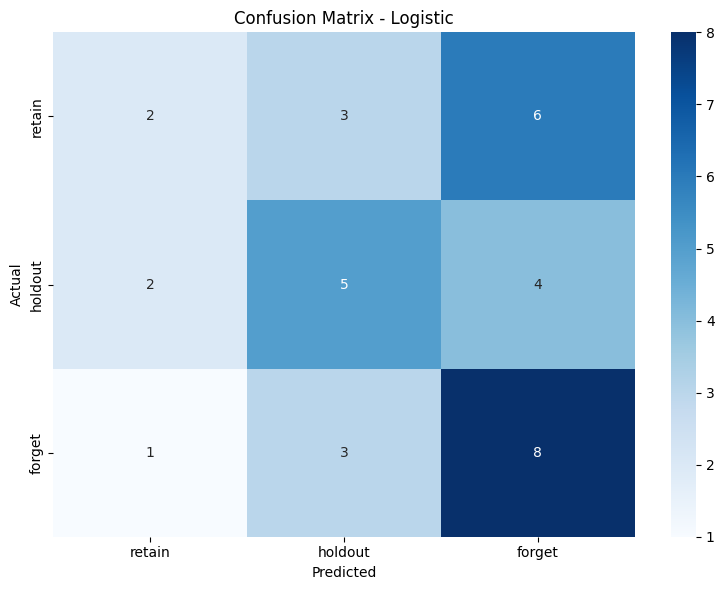


=== Classification Report - Logistic ===
              precision    recall  f1-score   support

      retain       0.40      0.18      0.25        11
     holdout       0.45      0.45      0.45        11
      forget       0.44      0.67      0.53        12

    accuracy                           0.44        34
   macro avg       0.43      0.43      0.41        34
weighted avg       0.43      0.44      0.42        34



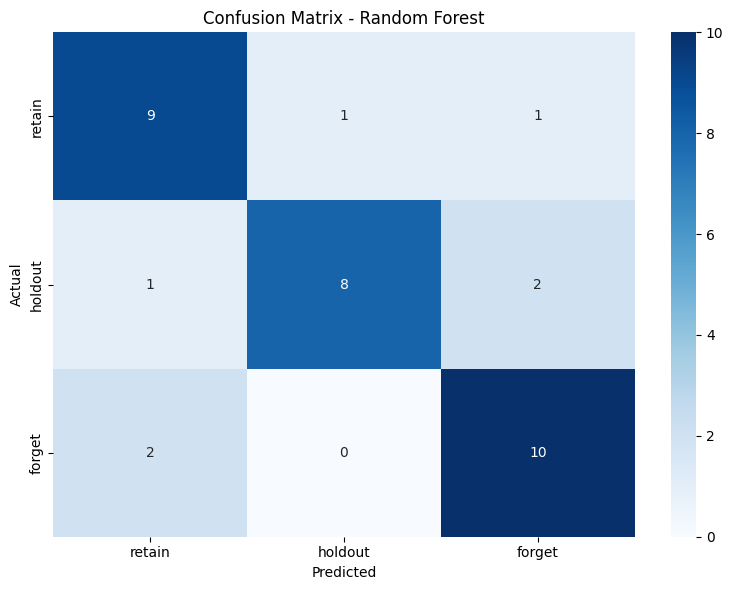


=== Classification Report - Random Forest ===
              precision    recall  f1-score   support

      retain       0.75      0.82      0.78        11
     holdout       0.89      0.73      0.80        11
      forget       0.77      0.83      0.80        12

    accuracy                           0.79        34
   macro avg       0.80      0.79      0.79        34
weighted avg       0.80      0.79      0.79        34



In [17]:
# Display detailed results
print("=== Detailed Feature Importance Results ===")
for clf_key, importance_df in feature_importance_results.items():
    print(f"\n{clf_key.replace('_', ' ').title()}:")
    print(f"Top 10 most important features:")
    print(importance_df.head(10).to_string(index=False))
    print(f"\nTotal features: {len(importance_df)}")
    print(f"Top feature importance: {importance_df.iloc[0]['importance']:.4f}")
    print(f"Bottom feature importance: {importance_df.iloc[-1]['importance']:.4f}")

# Create confusion matrix for better understanding
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def plot_confusion_matrices(results, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, save_dir="classification_plots"):
    """
    Plot confusion matrices for the trained classifiers.
    """
    # Prepare data
    datasets = {
        'retain': norm_retain_tensor,
        'holdout': norm_holdout_tensor,
        'forget': norm_forget_tensor
    }
    
    tensors = []
    labels = []
    class_names = []
    for i, (split, tensor) in enumerate(datasets.items()):
        tensors.append(tensor)
        labels.append(torch.full((len(tensor),), i))
        class_names.append(split)

    X = torch.cat(tensors, dim=0).numpy()
    y = torch.cat(labels, dim=0).numpy()
    
    # Split data (same as in train_predictors)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
    
    for clf_name in ['logistic', 'random_forest']:
        model = results['multi_class'][clf_name]['model']
        y_pred = model.predict(X_test)
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=class_names, yticklabels=class_names)
        plt.title(f'Confusion Matrix - {clf_name.replace("_", " ").title()}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        
        cm_path = os.path.join(save_dir, f'confusion_matrix_{clf_name}.png')
        plt.savefig(cm_path, bbox_inches='tight', dpi=150)
        plt.show()
        
        # Classification report
        print(f"\n=== Classification Report - {clf_name.replace('_', ' ').title()} ===")
        print(classification_report(y_test, y_pred, target_names=class_names))

# Plot confusion matrices
plot_confusion_matrices(results, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

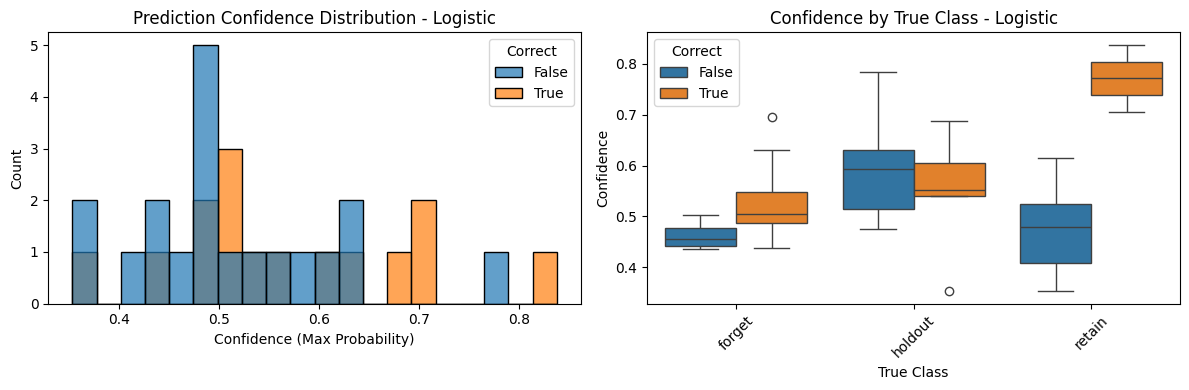


=== Confidence Analysis - Logistic ===
Average confidence for correct predictions: 0.570
Average confidence for incorrect predictions: 0.511
Low confidence predictions (< 0.5): 15


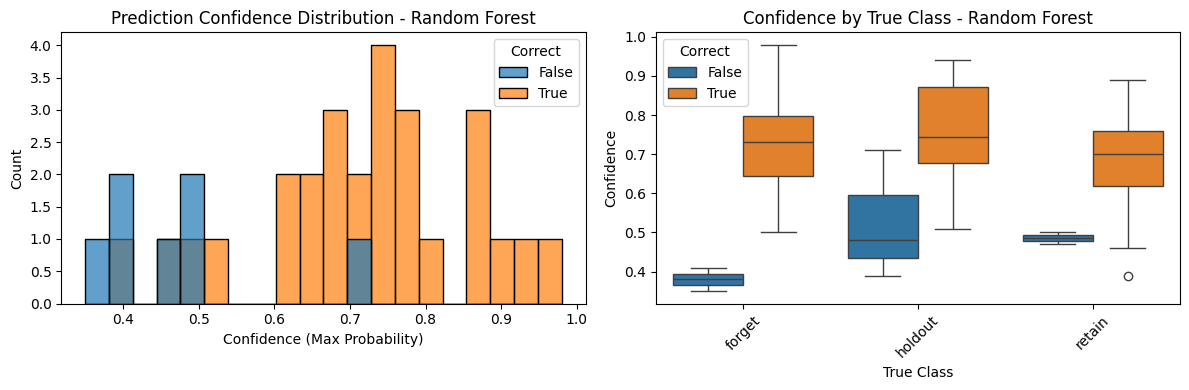


=== Confidence Analysis - Random Forest ===
Average confidence for correct predictions: 0.717
Average confidence for incorrect predictions: 0.473
Low confidence predictions (< 0.5): 7

=== Summary ===
All plots have been generated and saved to the 'classification_plots' directory.
The analysis includes:
- Performance comparison between classifiers
- Feature importance for each classifier
- Confusion matrices
- Prediction confidence analysis
- Feature importance comparison between classifiers


In [18]:
# Analyze prediction probabilities
def analyze_prediction_confidence(results, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, save_dir="classification_plots"):
    """
    Analyze and visualize prediction confidence for each class.
    """
    # Prepare data
    datasets = {
        'retain': norm_retain_tensor,
        'holdout': norm_holdout_tensor,
        'forget': norm_forget_tensor
    }
    
    tensors = []
    labels = []
    class_names = []
    for i, (split, tensor) in enumerate(datasets.items()):
        tensors.append(tensor)
        labels.append(torch.full((len(tensor),), i))
        class_names.append(split)

    X = torch.cat(tensors, dim=0).numpy()
    y = torch.cat(labels, dim=0).numpy()
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
    
    for clf_name in ['logistic', 'random_forest']:
        model = results['multi_class'][clf_name]['model']
        y_proba = model.predict_proba(X_test)
        y_pred = model.predict(X_test)
        
        # Create confidence analysis
        confidence_data = []
        for i, (true_label, pred_label, probas) in enumerate(zip(y_test, y_pred, y_proba)):
            max_proba = np.max(probas)
            correct = true_label == pred_label
            confidence_data.append({
                'Sample': i,
                'True_Class': class_names[true_label],
                'Predicted_Class': class_names[pred_label],
                'Confidence': max_proba,
                'Correct': correct
            })
        
        confidence_df = pd.DataFrame(confidence_data)
        
        # Plot confidence distribution
        plt.figure(figsize=(12, 4))
        
        plt.subplot(1, 2, 1)
        sns.histplot(data=confidence_df, x='Confidence', hue='Correct', bins=20, alpha=0.7)
        plt.title(f'Prediction Confidence Distribution - {clf_name.replace("_", " ").title()}')
        plt.xlabel('Confidence (Max Probability)')
        plt.ylabel('Count')
        
        plt.subplot(1, 2, 2)
        sns.boxplot(data=confidence_df, x='True_Class', y='Confidence', hue='Correct')
        plt.title(f'Confidence by True Class - {clf_name.replace("_", " ").title()}')
        plt.xlabel('True Class')
        plt.ylabel('Confidence')
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        
        confidence_path = os.path.join(save_dir, f'confidence_analysis_{clf_name}.png')
        plt.savefig(confidence_path, bbox_inches='tight', dpi=150)
        plt.show()
        
        # Print confidence statistics
        print(f"\n=== Confidence Analysis - {clf_name.replace('_', ' ').title()} ===")
        print(f"Average confidence for correct predictions: {confidence_df[confidence_df['Correct']]['Confidence'].mean():.3f}")
        print(f"Average confidence for incorrect predictions: {confidence_df[~confidence_df['Correct']]['Confidence'].mean():.3f}")
        print(f"Low confidence predictions (< 0.5): {len(confidence_df[confidence_df['Confidence'] < 0.5])}")

# Run confidence analysis
analyze_prediction_confidence(results, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

print("\n=== Summary ===")
print("All plots have been generated and saved to the 'classification_plots' directory.")
print("The analysis includes:")
print("- Performance comparison between classifiers")
print("- Feature importance for each classifier")
print("- Confusion matrices")
print("- Prediction confidence analysis")
print("- Feature importance comparison between classifiers")

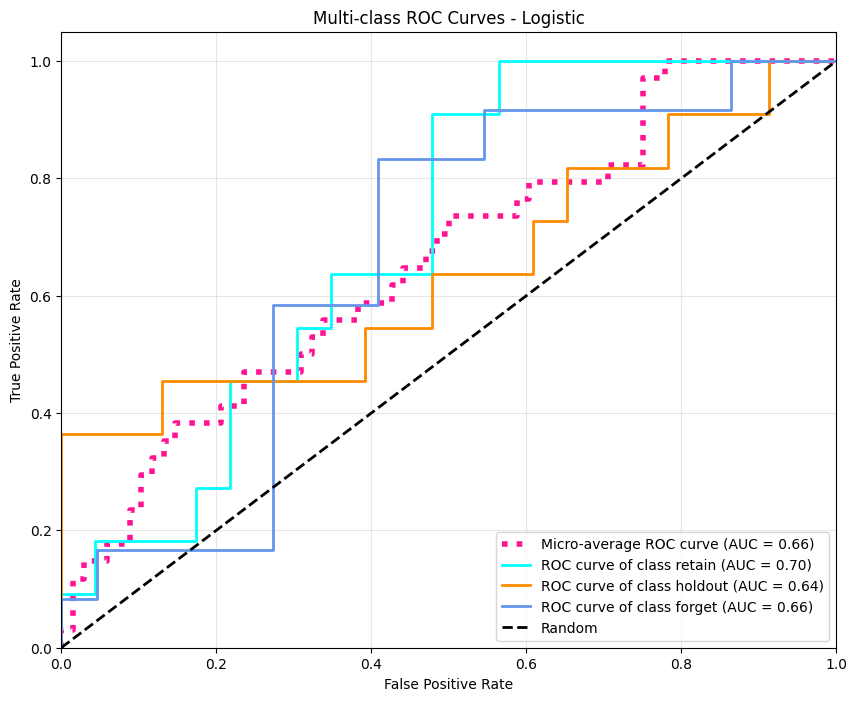


=== ROC AUC Scores - Logistic ===
retain: 0.700
holdout: 0.640
forget: 0.663
Micro-average: 0.656


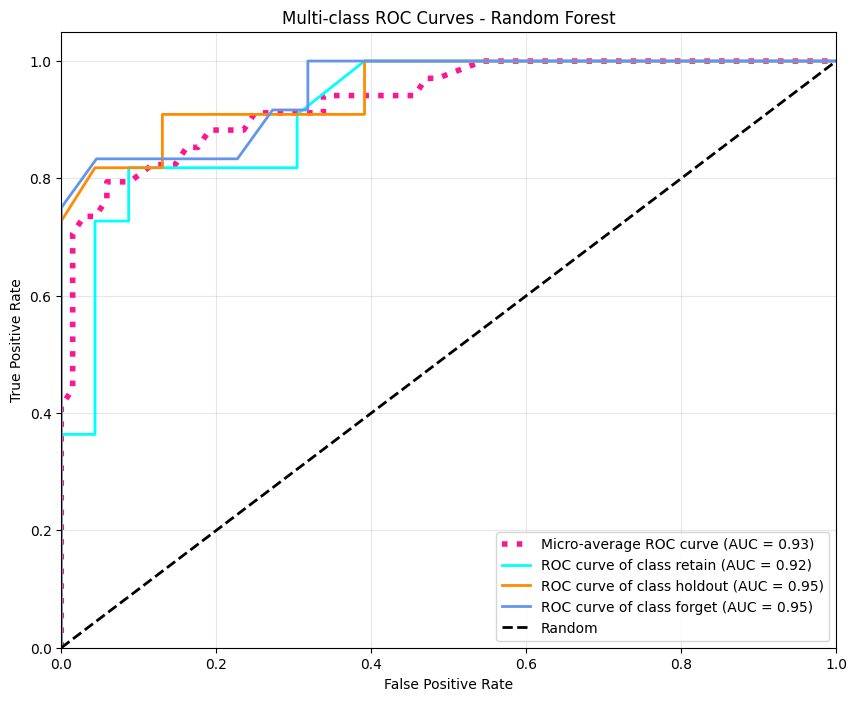


=== ROC AUC Scores - Random Forest ===
retain: 0.917
holdout: 0.951
forget: 0.951
Micro-average: 0.933


In [19]:
# ROC Curves for Multi-Class Classification
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

def plot_multiclass_roc_curves(results, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, save_dir="classification_plots"):
    """
    Plot ROC curves for multi-class classification using One-vs-Rest approach.
    """
    # Prepare data
    datasets = {
        'retain': norm_retain_tensor,
        'holdout': norm_holdout_tensor,
        'forget': norm_forget_tensor
    }
    
    tensors = []
    labels = []
    class_names = []
    for i, (split, tensor) in enumerate(datasets.items()):
        tensors.append(tensor)
        labels.append(torch.full((len(tensor),), i))
        class_names.append(split)

    X = torch.cat(tensors, dim=0).numpy()
    y = torch.cat(labels, dim=0).numpy()
    
    # Binarize the output
    y_bin = label_binarize(y, classes=[0, 1, 2])
    n_classes = y_bin.shape[1]
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
    
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
    
    for clf_name in ['logistic', 'random_forest']:
        model = results['multi_class'][clf_name]['model']
        y_score = model.predict_proba(X_test)
        
        # Compute ROC curve and ROC area for each class
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        
        # Compute micro-average ROC curve and ROC area
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
        
        # Plot ROC curves
        plt.figure(figsize=(10, 8))
        
        # Plot micro-average ROC curve
        plt.plot(fpr["micro"], tpr["micro"],
                 label=f'Micro-average ROC curve (AUC = {roc_auc["micro"]:.2f})',
                 color='deeppink', linestyle=':', linewidth=4)
        
        # Plot ROC curves for each class
        for i, color in zip(range(n_classes), colors):
            plt.plot(fpr[i], tpr[i], color=color, lw=2,
                     label=f'ROC curve of class {class_names[i]} (AUC = {roc_auc[i]:.2f})')
        
        plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Multi-class ROC Curves - {clf_name.replace("_", " ").title()}')
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        
        roc_path = os.path.join(save_dir, f'multiclass_roc_{clf_name}.png')
        plt.savefig(roc_path, bbox_inches='tight', dpi=150)
        plt.show()
        
        # Print AUC scores
        print(f"\n=== ROC AUC Scores - {clf_name.replace('_', ' ').title()} ===")
        for i, class_name in enumerate(class_names):
            print(f"{class_name}: {roc_auc[i]:.3f}")
        print(f"Micro-average: {roc_auc['micro']:.3f}")

# Generate ROC curves
plot_multiclass_roc_curves(results, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)


=== Holdout Vs All ===
Positive class (holdout): 28 samples
Negative class (retain_forget): 56 samples

Training Logistic...
Logistic: Accuracy=0.706, F1=0.167, ROC AUC=0.787


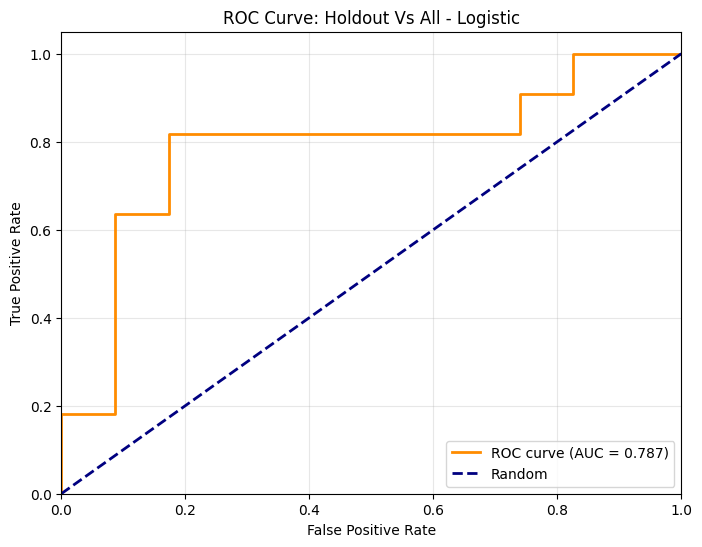

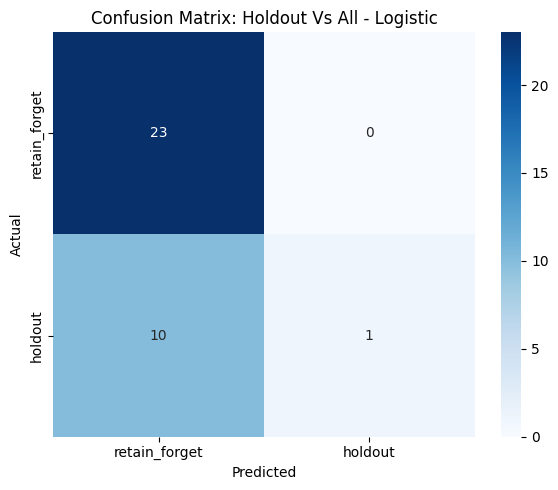


Training Random Forest...
Random_Forest: Accuracy=0.647, F1=0.250, ROC AUC=0.567


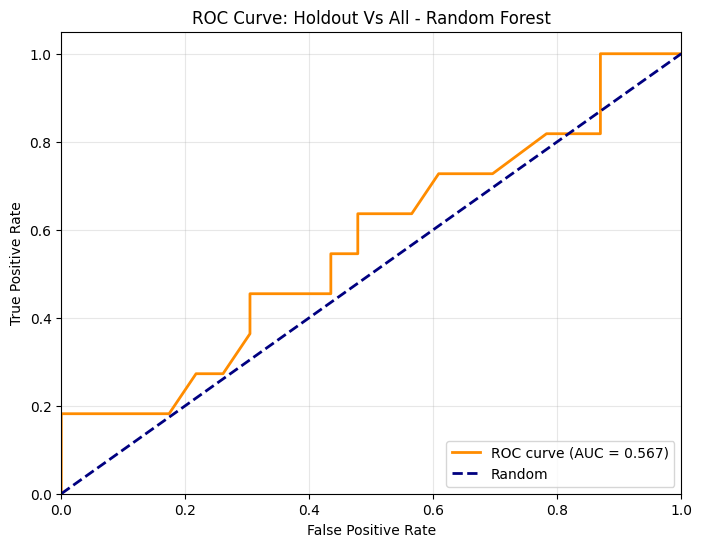

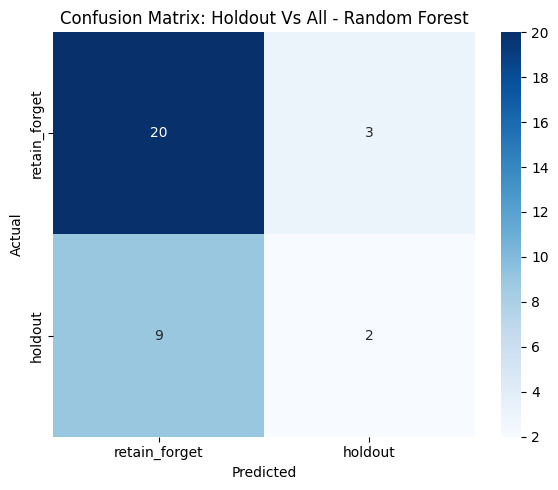


=== Forget Vs All ===
Positive class (forget): 30 samples
Negative class (retain_holdout): 54 samples

Training Logistic...
Logistic: Accuracy=0.618, F1=0.435, ROC AUC=0.720


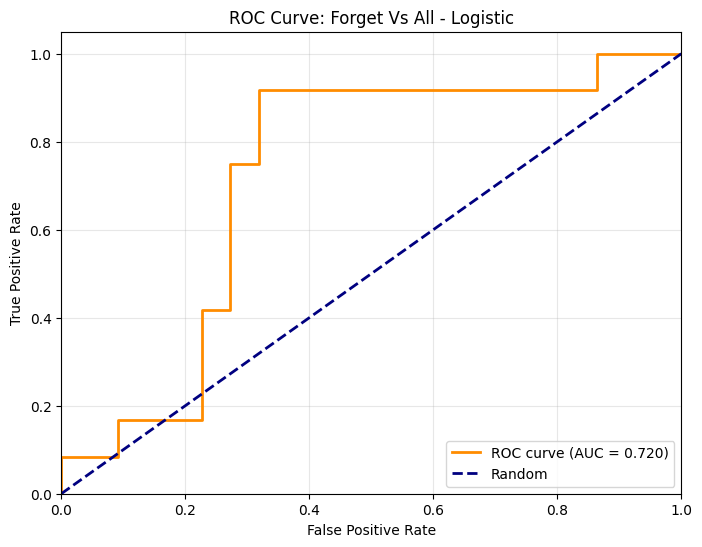

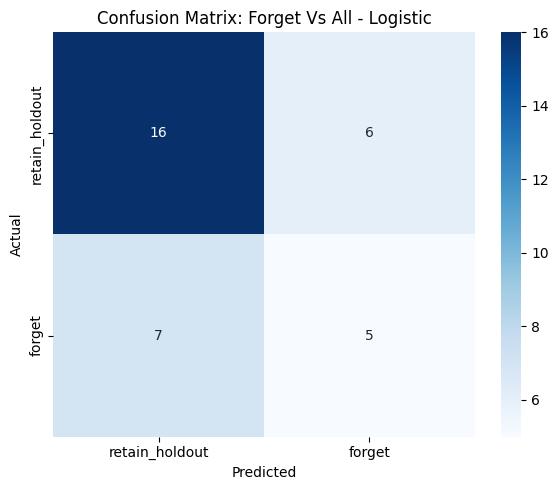


Training Random Forest...
Random_Forest: Accuracy=0.735, F1=0.526, ROC AUC=0.816


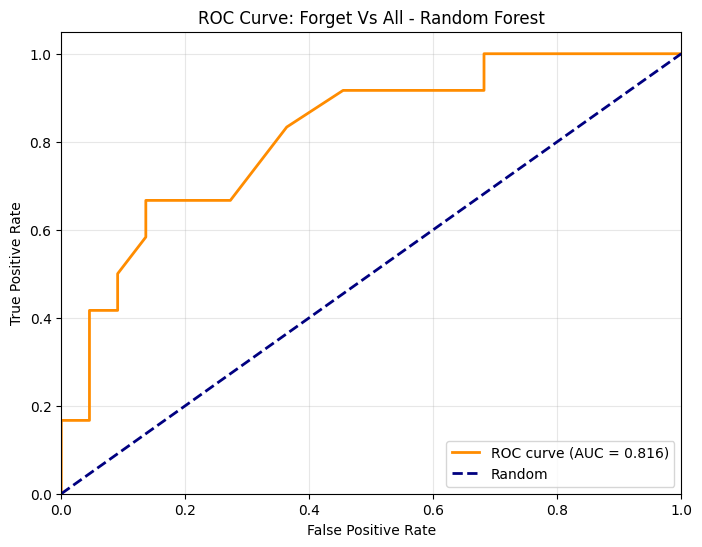

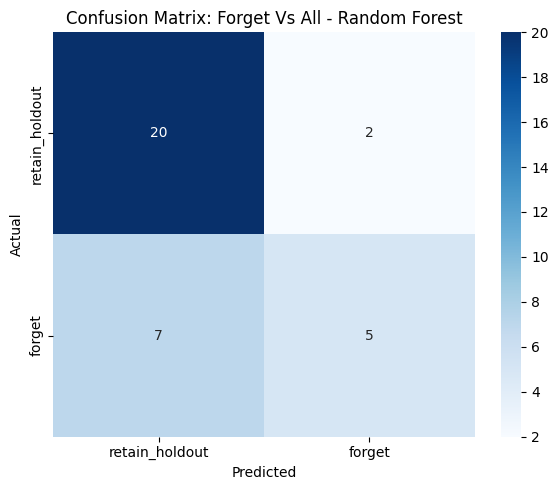

In [20]:
# Binary Comparisons: Holdout vs All, Forget vs All
def train_binary_comparisons(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels, save_dir="classification_plots"):
    """
    Train binary classifiers for:
    1. Holdout vs All (Retain + Forget)
    2. Forget vs All (Retain + Holdout)
    """
    binary_results = {}
    binary_feature_importance = {}
    
    # Define binary comparisons
    comparisons = {
        'holdout_vs_all': {
            'positive_class': norm_holdout_tensor,
            'positive_name': 'holdout',
            'negative_class': torch.cat([norm_retain_tensor, norm_forget_tensor], dim=0),
            'negative_name': 'retain_forget'
        },
        'forget_vs_all': {
            'positive_class': norm_forget_tensor,
            'positive_name': 'forget',
            'negative_class': torch.cat([norm_retain_tensor, norm_holdout_tensor], dim=0),
            'negative_name': 'retain_holdout'
        }
    }
    
    for comparison_name, comparison_data in comparisons.items():
        print(f"\n=== {comparison_name.replace('_', ' ').title()} ===")
        
        # Prepare data
        positive_tensor = comparison_data['positive_class']
        negative_tensor = comparison_data['negative_class']
        
        # Create labels (1 for positive class, 0 for negative class)
        positive_labels = torch.ones(len(positive_tensor))
        negative_labels = torch.zeros(len(negative_tensor))
        
        # Combine features and labels
        X = torch.cat([positive_tensor, negative_tensor], dim=0).numpy()
        y = torch.cat([positive_labels, negative_labels], dim=0).numpy()
        
        print(f"Positive class ({comparison_data['positive_name']}): {len(positive_tensor)} samples")
        print(f"Negative class ({comparison_data['negative_name']}): {len(negative_tensor)} samples")
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
        
        binary_results[comparison_name] = {}
        
        # Train classifiers
        for clf_type, (clf_class, clf_params) in [
            ('logistic', (LogisticRegression, {'random_state': 42, 'max_iter': 300})),
            ('random_forest', (RandomForestClassifier, {'random_state': 42, 'n_estimators': 100}))
        ]:
            print(f"\nTraining {clf_type.replace('_', ' ').title()}...")
            
            # Train classifier
            clf = clf_class(**clf_params)
            clf.fit(X_train, y_train)
            
            # Evaluate
            y_pred = clf.predict(X_test)
            y_proba = clf.predict_proba(X_test)[:, 1]
            
            accuracy = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            roc_auc = roc_auc_score(y_test, y_proba)
            
            print(f"{clf_type.title()}: Accuracy={accuracy:.3f}, F1={f1:.3f}, ROC AUC={roc_auc:.3f}")
            
            # Store results
            binary_results[comparison_name][clf_type] = {
                'accuracy': accuracy,
                'f1': f1,
                'roc_auc': roc_auc,
                'model': clf,
                'y_test': y_test,
                'y_pred': y_pred,
                'y_proba': y_proba
            }
            
            # Feature importance
            if clf_type == 'logistic':
                importance = abs(clf.coef_[0])
            else:  # random_forest
                importance = clf.feature_importances_
            
            importance = importance / np.sum(importance)
            
            importance_df = pd.DataFrame({
                'feature': features_labels,
                'importance': importance
            }).sort_values('importance', ascending=False)
            
            binary_feature_importance[f"{comparison_name}_{clf_type}"] = importance_df
            
            # Plot ROC curve
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            plt.figure(figsize=(8, 6))
            plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
            plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'ROC Curve: {comparison_name.replace("_", " ").title()} - {clf_type.replace("_", " ").title()}')
            plt.legend(loc="lower right")
            plt.grid(alpha=0.3)
            
            roc_path = os.path.join(save_dir, f'binary_roc_{comparison_name}_{clf_type}.png')
            plt.savefig(roc_path, bbox_inches='tight', dpi=150)
            plt.show()
            
            # Confusion matrix
            cm = confusion_matrix(y_test, y_pred)
            plt.figure(figsize=(6, 5))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                       xticklabels=[comparison_data['negative_name'], comparison_data['positive_name']], 
                       yticklabels=[comparison_data['negative_name'], comparison_data['positive_name']])
            plt.title(f'Confusion Matrix: {comparison_name.replace("_", " ").title()} - {clf_type.replace("_", " ").title()}')
            plt.xlabel('Predicted')
            plt.ylabel('Actual')
            plt.tight_layout()
            
            cm_path = os.path.join(save_dir, f'binary_cm_{comparison_name}_{clf_type}.png')
            plt.savefig(cm_path, bbox_inches='tight', dpi=150)
            plt.show()
    
    return binary_results, binary_feature_importance

# Run binary comparisons
binary_results, binary_feature_importance = train_binary_comparisons(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

=== COMPREHENSIVE PERFORMANCE SUMMARY ===

Multi-Class Classification (Retain vs Holdout vs Forget):
  Logistic: Accuracy=0.385, F1=0.325, ROC AUC=0.686
  Random Forest: Accuracy=0.462, F1=0.449, ROC AUC=0.687

Binary Classifications:

Holdout Vs All:
  Logistic: Accuracy=0.706, F1=0.167, ROC AUC=0.787
  Random Forest: Accuracy=0.647, F1=0.250, ROC AUC=0.567

Forget Vs All:
  Logistic: Accuracy=0.618, F1=0.435, ROC AUC=0.720
  Random Forest: Accuracy=0.735, F1=0.526, ROC AUC=0.816


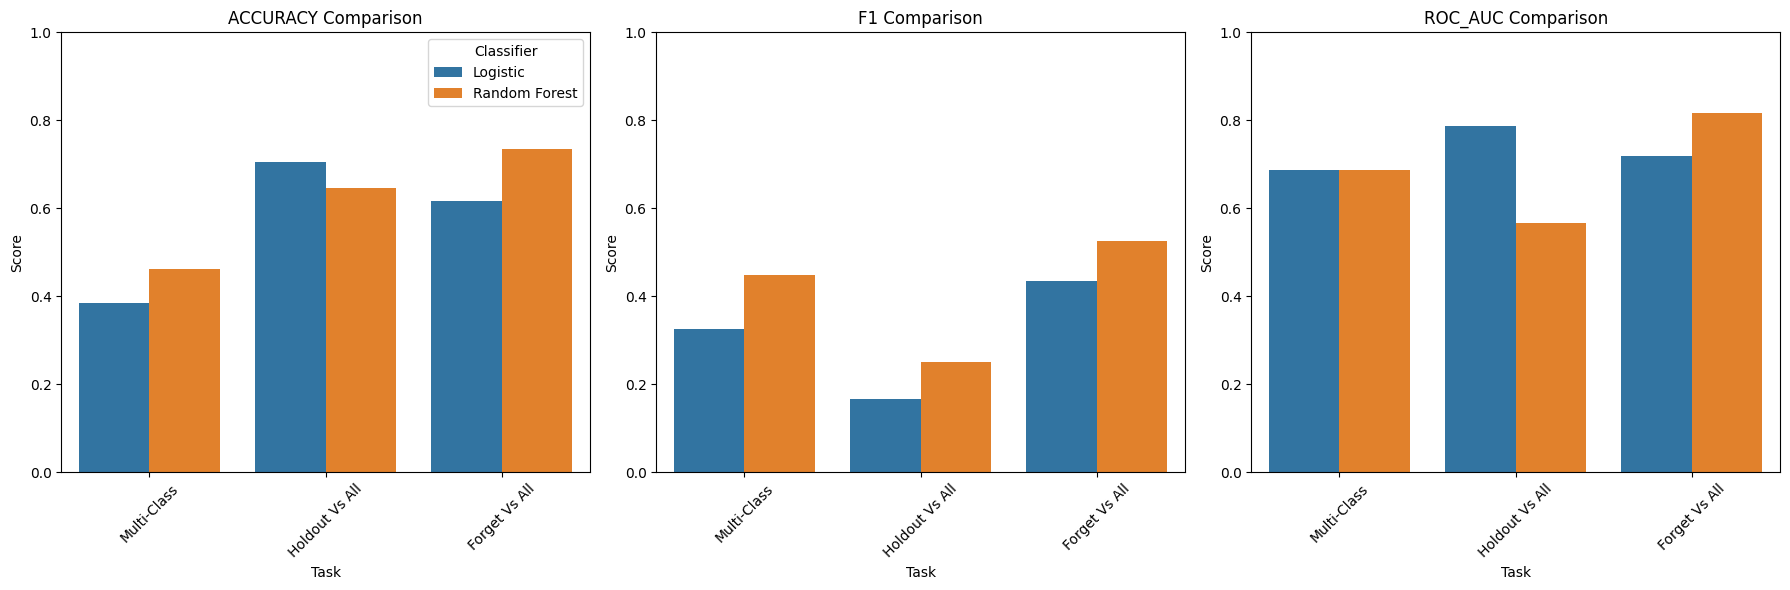


=== TOP FEATURE ANALYSIS ===
Top 15 Most Consistently Important Features (across all tasks):
 1. original_loss                            (Avg Rank: 1.0, Appears in 3 top-10 lists)
 2. mean_neighbor_loss                       (Avg Rank: 2.0, Appears in 5 top-10 lists)
 3. max_neighbor_loss                        (Avg Rank: 3.0, Appears in 5 top-10 lists)
 4. min_neighbor_loss                        (Avg Rank: 4.0, Appears in 6 top-10 lists)
 5. loss_variance                            (Avg Rank: 5.0, Appears in 4 top-10 lists)
 6. loss_std                                 (Avg Rank: 6.0, Appears in 3 top-10 lists)
 7. mean_loss_increment                      (Avg Rank: 7.0, Appears in 6 top-10 lists)
 8. max_loss_increment                       (Avg Rank: 8.0, Appears in 4 top-10 lists)
 9. min_loss_increment                       (Avg Rank: 9.0, Appears in 4 top-10 lists)
10. mean_gradient                            (Avg Rank: 10.0, Appears in 5 top-10 lists)
11. max_gradient         

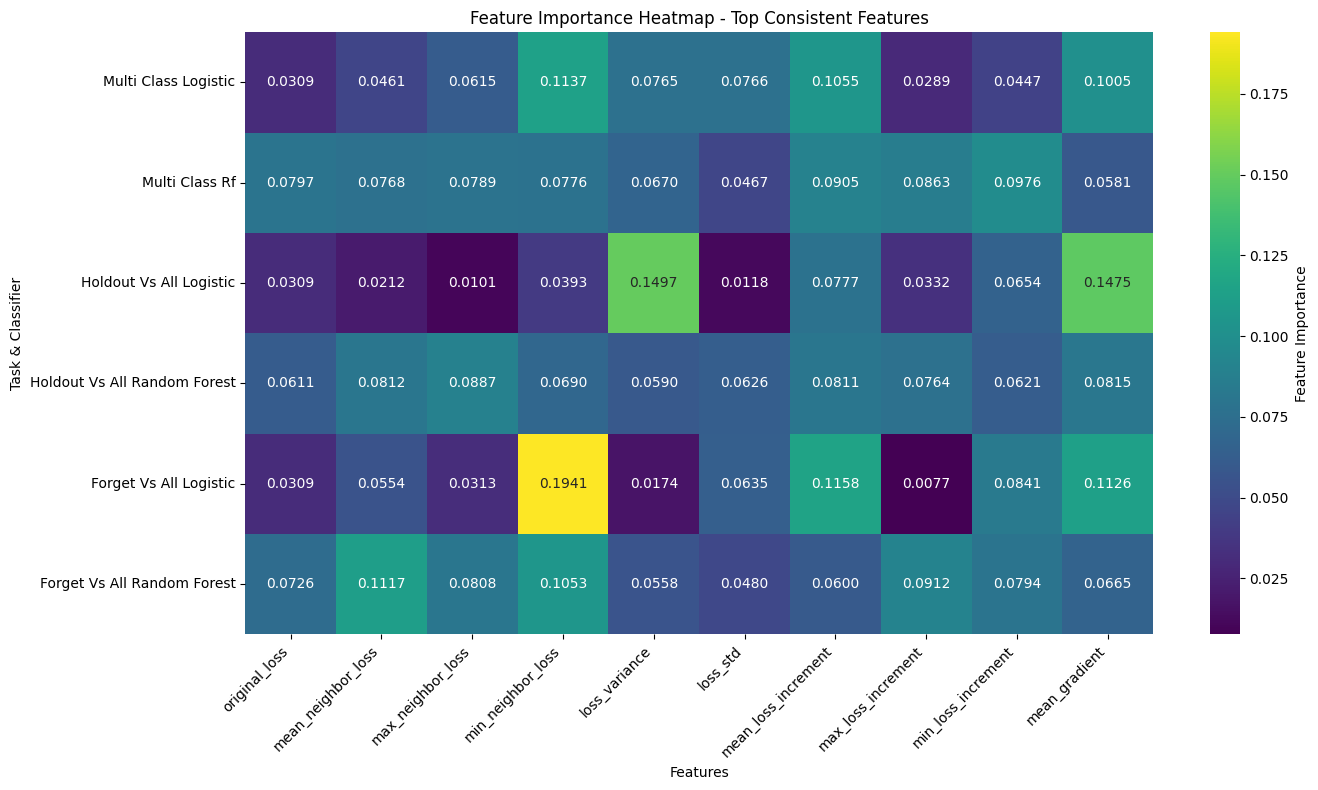


ANALYSIS COMPLETE
Generated plots and analysis:
1. Multi-class ROC curves
2. Binary classification ROC curves (holdout vs all, forget vs all)
3. Confusion matrices for all comparisons
4. Comprehensive performance comparison
5. Feature importance analysis across all tasks
6. Feature importance heatmap

All plots saved to: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/Unlearn-Simple/MUSE/notebooks/classification_plots


In [21]:
# Comprehensive Analysis and Summary
def create_comprehensive_summary(results, binary_results, feature_importance_results, binary_feature_importance, save_dir="classification_plots"):
    """
    Create comprehensive summary visualizations comparing all approaches.
    """
    
    # 1. Performance Summary Table
    print("=== COMPREHENSIVE PERFORMANCE SUMMARY ===\n")
    
    # Multi-class results
    print("Multi-Class Classification (Retain vs Holdout vs Forget):")
    for clf_type in ['logistic', 'random_forest']:
        metrics = results['multi_class'][clf_type]
        print(f"  {clf_type.replace('_', ' ').title()}: Accuracy={metrics['accuracy']:.3f}, F1={metrics['f1']:.3f}, ROC AUC={metrics['roc_auc']:.3f}")
    
    print("\nBinary Classifications:")
    for comparison in ['holdout_vs_all', 'forget_vs_all']:
        print(f"\n{comparison.replace('_', ' ').title()}:")
        for clf_type in ['logistic', 'random_forest']:
            metrics = binary_results[comparison][clf_type]
            print(f"  {clf_type.replace('_', ' ').title()}: Accuracy={metrics['accuracy']:.3f}, F1={metrics['f1']:.3f}, ROC AUC={metrics['roc_auc']:.3f}")
    
    # 2. Performance Comparison Plot
    performance_data = []
    
    # Multi-class data
    for clf_type in ['logistic', 'random_forest']:
        metrics = results['multi_class'][clf_type]
        for metric_name in ['accuracy', 'f1', 'roc_auc']:
            performance_data.append({
                'Classifier': clf_type.replace('_', ' ').title(),
                'Task': 'Multi-Class',
                'Metric': metric_name.upper(),
                'Score': metrics[metric_name]
            })
    
    # Binary data
    for comparison in ['holdout_vs_all', 'forget_vs_all']:
        for clf_type in ['logistic', 'random_forest']:
            metrics = binary_results[comparison][clf_type]
            for metric_name in ['accuracy', 'f1', 'roc_auc']:
                performance_data.append({
                    'Classifier': clf_type.replace('_', ' ').title(),
                    'Task': comparison.replace('_', ' ').title(),
                    'Metric': metric_name.upper(),
                    'Score': metrics[metric_name]
                })
    
    performance_df = pd.DataFrame(performance_data)
    
    # Create comparison plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i, metric in enumerate(['ACCURACY', 'F1', 'ROC_AUC']):
        metric_data = performance_df[performance_df['Metric'] == metric]
        sns.barplot(data=metric_data, x='Task', y='Score', hue='Classifier', ax=axes[i])
        axes[i].set_title(f'{metric} Comparison')
        axes[i].set_ylabel('Score')
        axes[i].set_ylim(0, 1)
        axes[i].tick_params(axis='x', rotation=45)
        if i == 0:
            axes[i].legend(title='Classifier')
        else:
            axes[i].get_legend().remove()
    
    plt.tight_layout()
    
    comparison_path = os.path.join(save_dir, 'comprehensive_performance_comparison.png')
    plt.savefig(comparison_path, bbox_inches='tight', dpi=150)
    plt.show()
    
    # 3. Feature Importance Comparison
    print("\n=== TOP FEATURE ANALYSIS ===")
    
    all_importance_dfs = {**feature_importance_results, **binary_feature_importance}
    
    # Find most consistently important features
    feature_rankings = {}
    for task_clf, importance_df in all_importance_dfs.items():
        for idx, row in importance_df.head(10).iterrows():
            feature = row['feature']
            if feature not in feature_rankings:
                feature_rankings[feature] = []
            feature_rankings[feature].append(idx + 1)  # Ranking (1-based)
    
    # Calculate average ranking for features that appear in multiple top-10 lists
    avg_rankings = {}
    for feature, rankings in feature_rankings.items():
        if len(rankings) >= 2:  # Feature appears in at least 2 top-10 lists
            avg_rankings[feature] = np.mean(rankings)
    
    # Sort by average ranking
    top_consistent_features = sorted(avg_rankings.items(), key=lambda x: x[1])[:15]
    
    print("Top 15 Most Consistently Important Features (across all tasks):")
    for i, (feature, avg_rank) in enumerate(top_consistent_features, 1):
        appearances = len(feature_rankings[feature])
        print(f"{i:2d}. {feature:<40} (Avg Rank: {avg_rank:.1f}, Appears in {appearances} top-10 lists)")
    
    # 4. Task-Specific Feature Importance Heatmap
    if top_consistent_features:
        # Create heatmap of importance scores for top consistent features
        heatmap_data = []
        top_features = [f[0] for f in top_consistent_features[:10]]  # Top 10 most consistent
        
        for task_clf, importance_df in all_importance_dfs.items():
            row_data = {'Task_Classifier': task_clf.replace('_', ' ').title()}
            for feature in top_features:
                # Find importance score for this feature
                feature_row = importance_df[importance_df['feature'] == feature]
                if len(feature_row) > 0:
                    row_data[feature] = feature_row.iloc[0]['importance']
                else:
                    row_data[feature] = 0
            heatmap_data.append(row_data)
        
        heatmap_df = pd.DataFrame(heatmap_data)
        heatmap_df = heatmap_df.set_index('Task_Classifier')
        
        plt.figure(figsize=(14, 8))
        sns.heatmap(heatmap_df, annot=True, fmt='.4f', cmap='viridis', cbar_kws={'label': 'Feature Importance'})
        plt.title('Feature Importance Heatmap - Top Consistent Features')
        plt.xlabel('Features')
        plt.ylabel('Task & Classifier')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        
        heatmap_path = os.path.join(save_dir, 'feature_importance_heatmap_comprehensive.png')
        plt.savefig(heatmap_path, bbox_inches='tight', dpi=150)
        plt.show()
    
    return performance_df, top_consistent_features

# Create comprehensive summary
performance_summary, top_features = create_comprehensive_summary(
    results, binary_results, feature_importance_results, binary_feature_importance
)

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print("Generated plots and analysis:")
print("1. Multi-class ROC curves")
print("2. Binary classification ROC curves (holdout vs all, forget vs all)")
print("3. Confusion matrices for all comparisons")
print("4. Comprehensive performance comparison")
print("5. Feature importance analysis across all tasks")
print("6. Feature importance heatmap")
print(f"\nAll plots saved to: {os.path.abspath('classification_plots')}")

# Input Loss Landscape (ILL) Discriminative Analysis

This section provides specialized methods to analyze and distinguish between **forget**, **retain**, and **holdout** datasets using Input Loss Landscape features. 

## ILL Features Used:
- **Loss-based**: `original_loss`, `mean_neighbor_loss`, `max_neighbor_loss`, `min_neighbor_loss`
- **Variance-based**: `loss_variance`, `loss_std`, `increment_variance`
- **Gradient-based**: `mean_gradient`, `max_gradient`, `gradient_variance`
- **Landscape properties**: `loss_volatility`, `local_curvature`
- **Increment-based**: `mean_loss_increment`, `max_loss_increment`, `min_loss_increment`
- **Embeddings**: Sentence embeddings for semantic analysis

The goal is to identify which ILL features are most discriminative for distinguishing between the three dataset types.

In [22]:
# Additional imports for comprehensive landscape analysis
from scipy.stats import wasserstein_distance, ks_2samp, entropy, skew, kurtosis
from scipy.spatial.distance import jensenshannon, pdist, squareform
from sklearn.manifold import TSNE, Isomap
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
import seaborn as sns

# Try to import UMAP, install if not available
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    print("UMAP not available. Install with: pip install umap-learn")
    UMAP_AVAILABLE = False

In [23]:
def compute_statistical_distances(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels):
    """
    Compute various statistical distance measures between feature distributions.
    """
    distances = {}
    
    datasets = {
        'retain': norm_retain_tensor,
        'holdout': norm_holdout_tensor, 
        'forget': norm_forget_tensor
    }
    
    for i, (name1, tensor1) in enumerate(datasets.items()):
        for j, (name2, tensor2) in enumerate(datasets.items()):
            if i >= j:
                continue
                
            pair_distances = {}
            
            for feat_idx, feat_name in enumerate(features_labels):
                vals1 = tensor1[:, feat_idx].numpy()
                vals2 = tensor2[:, feat_idx].numpy()
                
                # Wasserstein distance (Earth Mover's Distance)
                wasserstein_dist = wasserstein_distance(vals1, vals2)
                
                # Kolmogorov-Smirnov test
                ks_stat, ks_pvalue = ks_2samp(vals1, vals2)
                
                # Jensen-Shannon divergence (requires binning)
                hist1, bins = np.histogram(vals1, bins=20, density=True)
                hist2, _ = np.histogram(vals2, bins=bins, density=True)
                hist1 = hist1 + 1e-10  # Avoid zeros
                hist2 = hist2 + 1e-10
                js_div = jensenshannon(hist1, hist2)
                
                pair_distances[feat_name] = {
                    'wasserstein': wasserstein_dist,
                    'ks_statistic': ks_stat,
                    'ks_pvalue': ks_pvalue,
                    'jensen_shannon': js_div
                }
            
            distances[f"{name1}_vs_{name2}"] = pair_distances
    
    return distances

# Compute statistical distances
print("Computing statistical distances between datasets...")
stat_distances = compute_statistical_distances(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels)

Computing statistical distances between datasets...


# EXP: plot_statistical_distances
The plot_statistical_distances function generates heatmaps to visualize statistical distances—Wasserstein Distance, KS Statistic, and Jensen-Shannon Divergence—across features for dataset comparisons (retain, holdout, forget). Each heatmap shows how feature distributions differ between dataset pairs, with rows representing features and columns representing comparisons. Higher values indicate greater dissimilarity, helping identify features or dataset pairs with significant distributional differences. The heatmaps are annotated with precise values for clarity and saved as statistical_distances_heatmap.png.

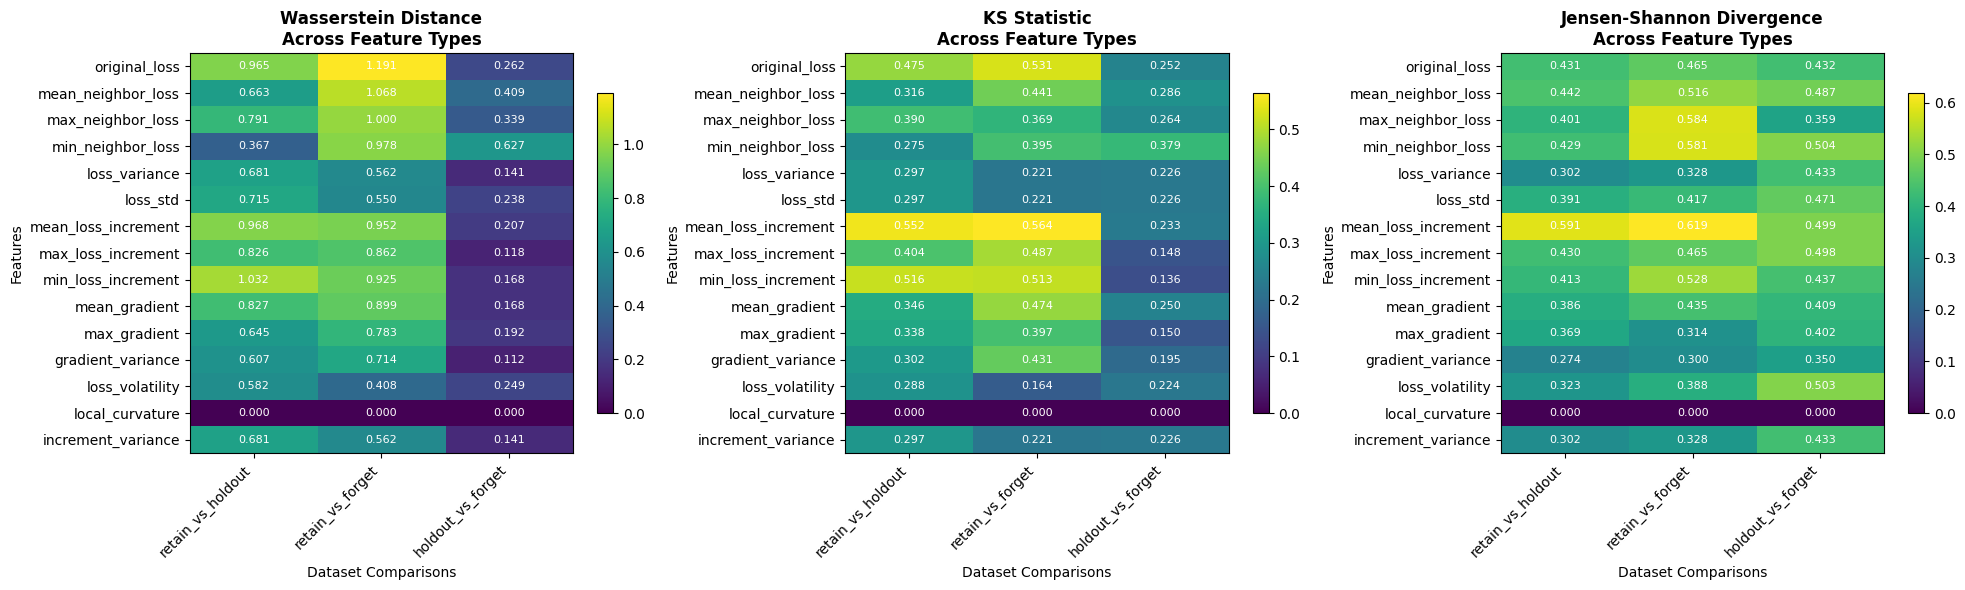

In [24]:
# Visualize statistical distances as heatmaps
def plot_statistical_distances(stat_distances, features_labels):
    """Create heatmaps for different statistical distance measures."""
    
    # Prepare data for each metric
    metrics = ['wasserstein', 'ks_statistic', 'jensen_shannon']
    metric_names = ['Wasserstein Distance', 'KS Statistic', 'Jensen-Shannon Divergence']
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for idx, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
        # Create matrix for this metric
        data_matrix = []
        
        for feat_name in features_labels:
            row = []
            for comparison in stat_distances.keys():
                row.append(stat_distances[comparison][feat_name][metric])
            data_matrix.append(row)
        
        data_matrix = np.array(data_matrix)
        
        # Create heatmap
        im = axes[idx].imshow(data_matrix, cmap='viridis', aspect='auto')
        axes[idx].set_title(f'{metric_name}\nAcross Feature Types', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Dataset Comparisons')
        axes[idx].set_ylabel('Features')
        
        # Set labels
        axes[idx].set_xticks(range(len(stat_distances.keys())))
        axes[idx].set_xticklabels(list(stat_distances.keys()), rotation=45, ha='right')
        axes[idx].set_yticks(range(len(features_labels)))
        axes[idx].set_yticklabels(features_labels)
        
        # Add colorbar
        plt.colorbar(im, ax=axes[idx], shrink=0.8)
        
        # Add text annotations
        for i in range(len(features_labels)):
            for j in range(len(stat_distances.keys())):
                text = axes[idx].text(j, i, f'{data_matrix[i, j]:.3f}',
                                     ha="center", va="center", color="white", fontsize=8)
    
    plt.tight_layout()
    plt.savefig(f'{plots_base_dir}/statistical_distances_heatmap.png', bbox_inches='tight', dpi=150)
    plt.show()

plot_statistical_distances(stat_distances, features_labels)

# EXP: compare_manifold_structures
The compare_manifold_structures function visualizes the separability of datasets (retain, holdout, forget) by projecting their high-dimensional features into a 2D space using dimensionality reduction techniques such as PCA, t-SNE, Isomap, and optionally UMAP. Each plot represents the datasets as clusters of points, with colors indicating the dataset type. Well-separated clusters suggest distinct dataset characteristics, while overlapping clusters indicate shared properties. These visualizations help assess the structural differences between datasets and evaluate their separability in the feature space. The plots are saved as manifold_comparisons.png.

Analyzing manifold structures...
Computing PCA embedding...
Computing TSNE embedding...
Computing Isomap embedding...
Computing UMAP embedding...


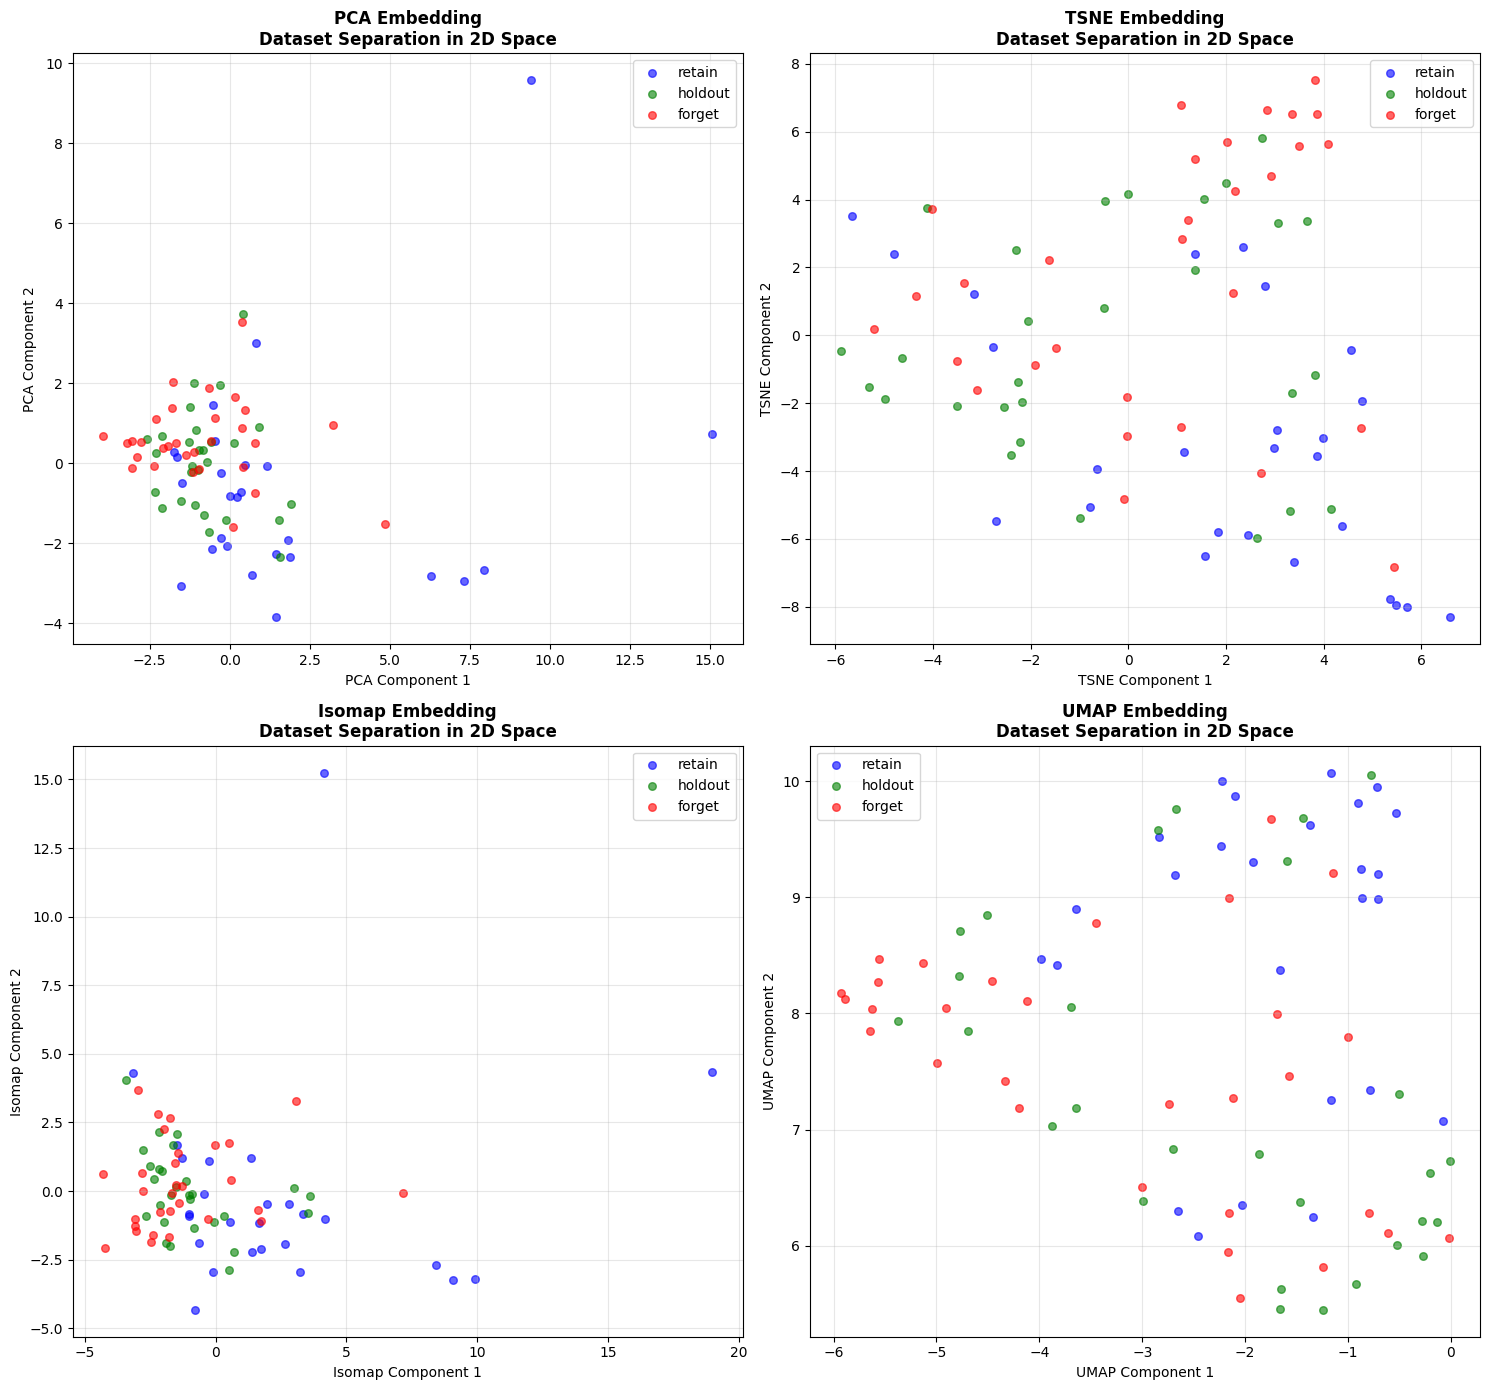

In [25]:
def compare_manifold_structures(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor):
    """
    Compare the manifold structure of different datasets using dimensionality reduction.
    """
    # Combine all data
    all_data = torch.cat([norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor], dim=0).numpy()
    labels = (['retain'] * len(norm_retain_tensor) + 
              ['holdout'] * len(norm_holdout_tensor) + 
              ['forget'] * len(norm_forget_tensor))
    
    manifold_results = {}
    
    # Different manifold learning techniques
    techniques = {
        'PCA': PCA(n_components=2),
        'TSNE': TSNE(n_components=2, random_state=42, perplexity=min(30, len(all_data)//4)),
        'Isomap': Isomap(n_components=2)
    }
    
    # Add UMAP if available
    if UMAP_AVAILABLE:
        techniques['UMAP'] = umap.UMAP(n_components=2, random_state=42)
    
    n_techniques = len(techniques)
    cols = 2
    rows = (n_techniques + 1) // 2
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 7*rows))
    if rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    colors = {'retain': 'blue', 'holdout': 'green', 'forget': 'red'}
    
    for idx, (name, technique) in enumerate(techniques.items()):
        print(f"Computing {name} embedding...")
        embedding = technique.fit_transform(all_data)
        
        # Plot
        ax = axes[idx]
        for label in ['retain', 'holdout', 'forget']:
            mask = np.array(labels) == label
            ax.scatter(embedding[mask, 0], embedding[mask, 1], 
                      label=label, alpha=0.6, s=30, c=colors[label])
        
        ax.set_title(f'{name} Embedding\nDataset Separation in 2D Space', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xlabel(f'{name} Component 1')
        ax.set_ylabel(f'{name} Component 2')
        
        manifold_results[name] = {
            'embedding': embedding,
            'labels': labels
        }
    
    # Hide unused subplots
    for idx in range(len(techniques), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'{plots_base_dir}/manifold_comparisons.png', bbox_inches='tight', dpi=150)
    plt.show()
    
    return manifold_results

# Run manifold analysis
print("Analyzing manifold structures...")
manifold_results = compare_manifold_structures(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

Analyzing clustering patterns...


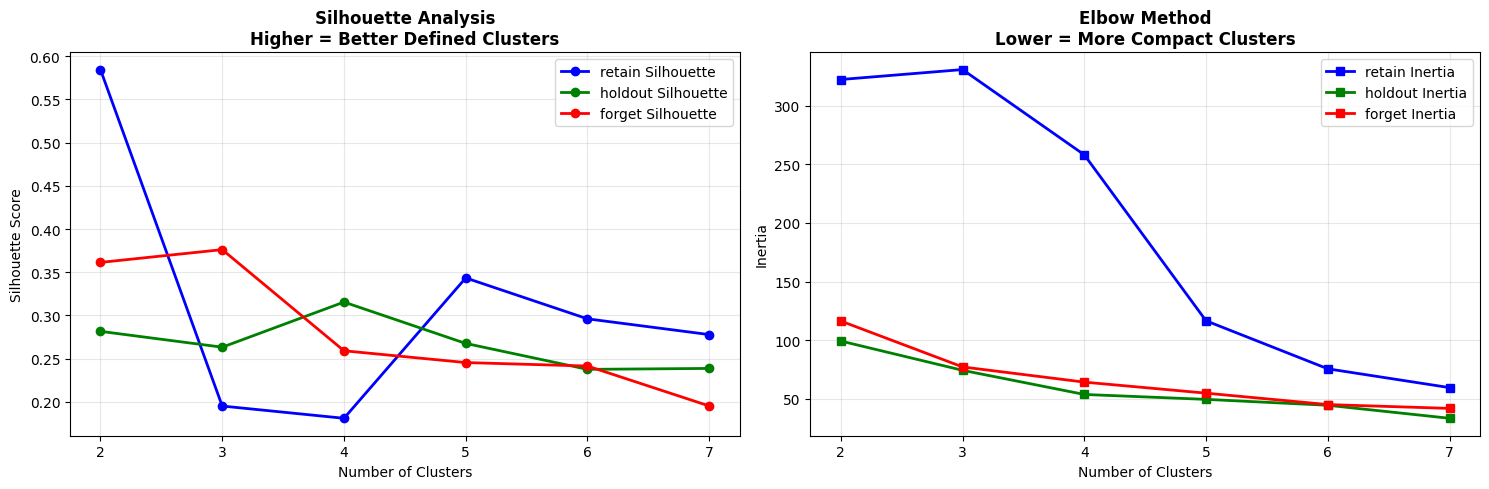

In [26]:
def analyze_clustering_patterns(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor):
    """
    Analyze clustering patterns and separability between datasets.
    """
    datasets = {
        'retain': norm_retain_tensor,
        'holdout': norm_holdout_tensor,
        'forget': norm_forget_tensor
    }
    
    clustering_results = {}
    
    # Test different numbers of clusters
    n_clusters_range = range(2, min(8, min(len(tensor) for tensor in datasets.values()) // 2))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    colors = {'retain': 'blue', 'holdout': 'green', 'forget': 'red'}
    
    for name, tensor in datasets.items():
        data = tensor.numpy()
        
        silhouette_scores = []
        inertias = []
        
        for n_clusters in n_clusters_range:
            kmeans = KMeans(n_clusters=n_clusters, random_state=42)
            cluster_labels = kmeans.fit_predict(data)
            
            silhouette_avg = silhouette_score(data, cluster_labels)
            silhouette_scores.append(silhouette_avg)
            inertias.append(kmeans.inertia_)
        
        clustering_results[name] = {
            'silhouette_scores': silhouette_scores,
            'inertias': inertias,
            'n_clusters_range': list(n_clusters_range)
        }
        
        # Plot results
        ax1.plot(n_clusters_range, silhouette_scores, 
                marker='o', label=f'{name} Silhouette', color=colors[name], linewidth=2)
        ax2.plot(n_clusters_range, inertias, 
                marker='s', label=f'{name} Inertia', color=colors[name], linewidth=2)
    
    ax1.set_xlabel('Number of Clusters')
    ax1.set_ylabel('Silhouette Score')
    ax1.set_title('Silhouette Analysis\nHigher = Better Defined Clusters', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.set_xlabel('Number of Clusters')
    ax2.set_ylabel('Inertia')
    ax2.set_title('Elbow Method\nLower = More Compact Clusters', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{plots_base_dir}/clustering_analysis.png', bbox_inches='tight', dpi=150)
    plt.show()
    
    return clustering_results

# Run clustering analysis
print("Analyzing clustering patterns...")
clustering_results = analyze_clustering_patterns(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

In [27]:
def analyze_landscape_topology(features_dict):
    """
    Analyze topological properties of the loss landscape.
    """
    topology_results = {}
    
    for split_name, split_data in features_dict.items():
        tensor = split_data['unnormalized_features_tensor']
        feature_names = split_data['features_names']
        
        split_topology = {}
        
        for feat_idx, feat_name in enumerate(feature_names):
            values = tensor[:, feat_idx].numpy()
            
            # Basic statistical moments
            split_topology[feat_name] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'skewness': skew(values),
                'kurtosis': kurtosis(values),
                'range': np.ptp(values),  # Peak-to-peak
                'iqr': np.percentile(values, 75) - np.percentile(values, 25),
                'cv': np.std(values) / np.mean(values) if np.mean(values) != 0 else 0
            }
        
        # Pairwise feature correlations
        correlation_matrix = np.corrcoef(tensor.numpy().T)
        split_topology['feature_correlations'] = correlation_matrix
        
        # Distance-based metrics
        distances = pdist(tensor.numpy())
        split_topology['distance_stats'] = {
            'mean_distance': np.mean(distances),
            'std_distance': np.std(distances),
            'max_distance': np.max(distances),
            'min_distance': np.min(distances)
        }
        
        topology_results[split_name] = split_topology
    
    return topology_results

# Compute topology analysis
print("Analyzing landscape topology...")
topology_results = analyze_landscape_topology(features_dict)

Analyzing landscape topology...


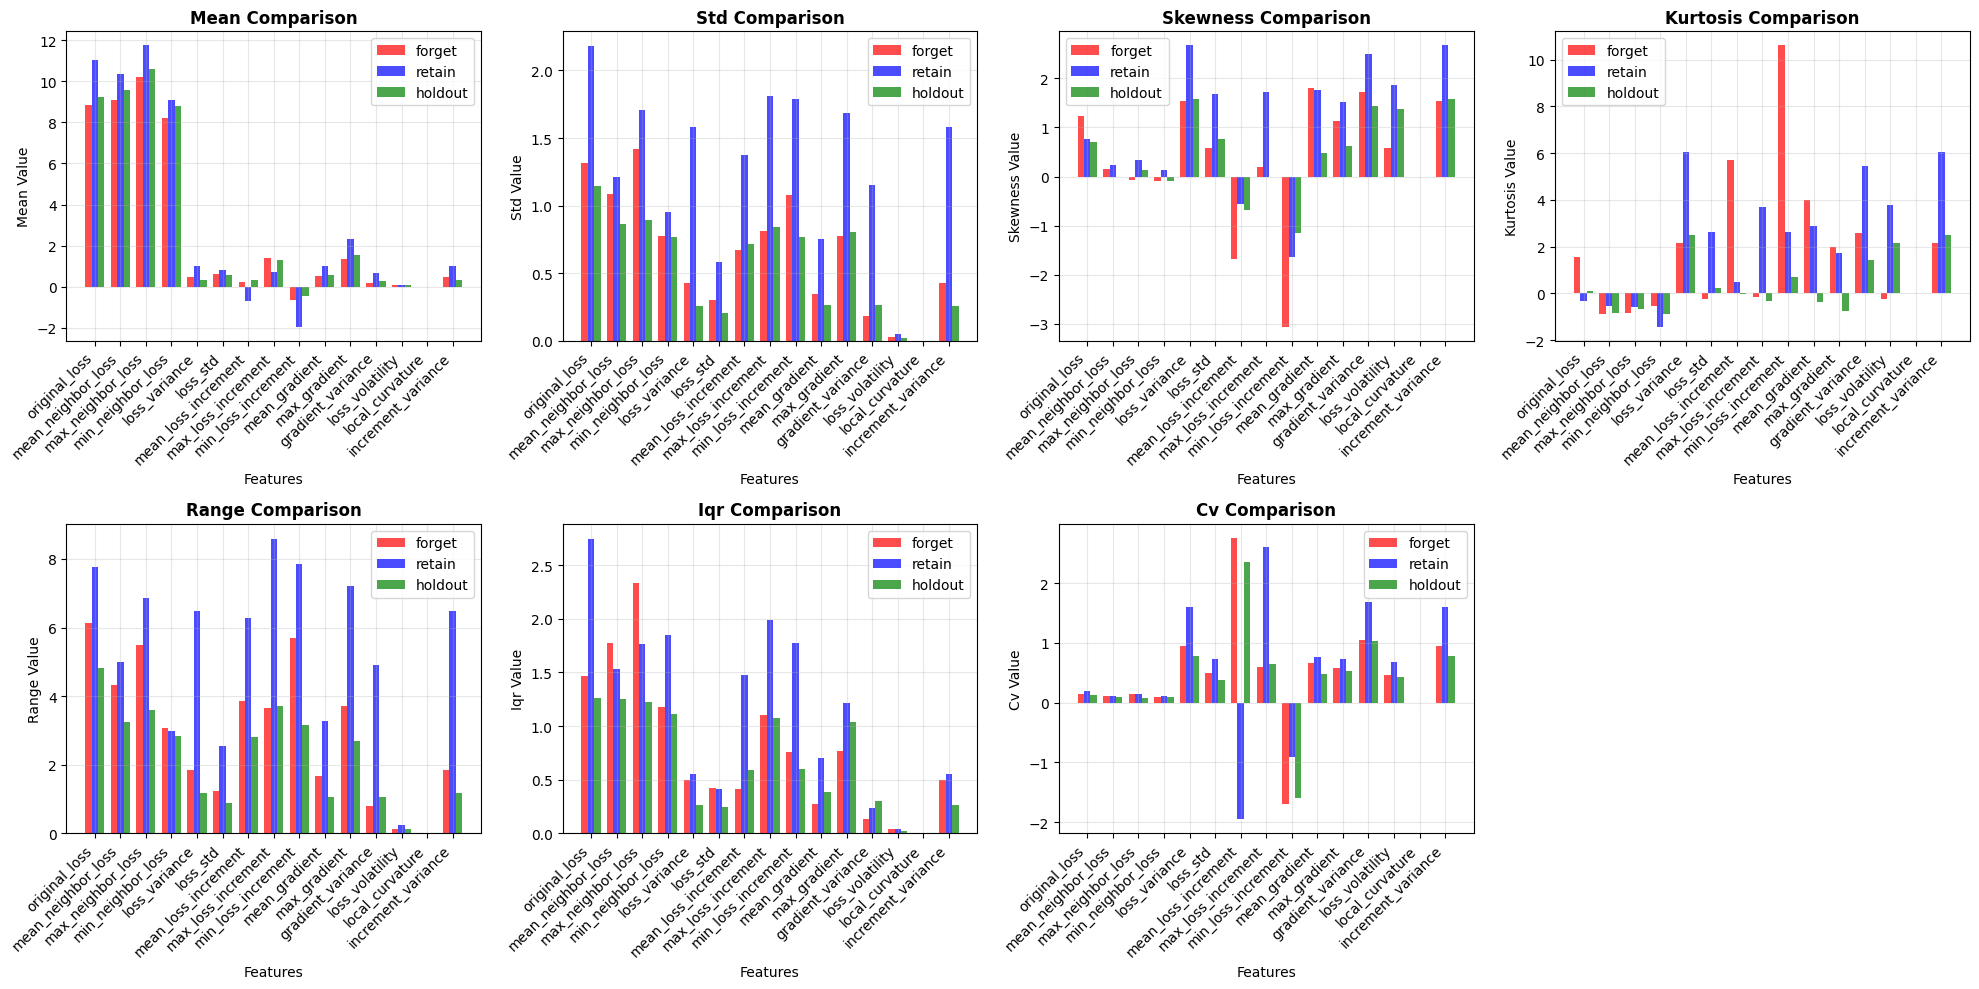

In [28]:
# Visualize topological properties
def plot_topology_comparison(topology_results, features_labels):
    """Plot comparison of topological properties across datasets."""
    
    # Extract statistical moments for comparison
    properties = ['mean', 'std', 'skewness', 'kurtosis', 'range', 'iqr', 'cv']
    datasets = list(topology_results.keys())
    
    # Create subplots for each property
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    colors = {'retain': 'blue', 'holdout': 'green', 'forget': 'red'}
    
    for prop_idx, prop in enumerate(properties):
        ax = axes[prop_idx]
        
        # Collect data for this property
        x_positions = np.arange(len(features_labels))
        width = 0.25
        
        for dataset_idx, dataset in enumerate(datasets):
            values = []
            for feat_name in features_labels:
                if feat_name in topology_results[dataset]:
                    values.append(topology_results[dataset][feat_name][prop])
                else:
                    values.append(0)
            
            offset = (dataset_idx - 1) * width
            bars = ax.bar(x_positions + offset, values, width, 
                         label=dataset, color=colors.get(dataset, 'gray'), alpha=0.7)
        
        ax.set_title(f'{prop.title()} Comparison', fontweight='bold')
        ax.set_xlabel('Features')
        ax.set_ylabel(f'{prop.title()} Value')
        ax.set_xticks(x_positions)
        ax.set_xticklabels(features_labels, rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Hide the last subplot if odd number of properties
    axes[-1].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'{plots_base_dir}/topology_comparison.png', bbox_inches='tight', dpi=150)
    plt.show()

# Plot topology comparison
plot_topology_comparison(topology_results, features_labels)

In [29]:
def analyze_landscape_smoothness(features_dict):
    """
    Analyze the smoothness/roughness of the loss landscape.
    """
    smoothness_results = {}
    
    for split_name, split_data in features_dict.items():
        tensor = split_data['unnormalized_features_tensor']
        feature_names = split_data['features_names']
        
        smoothness_metrics = {}
        
        for feat_idx, feat_name in enumerate(feature_names):
            values = tensor[:, feat_idx].numpy()
            
            # Sort values to analyze smoothness
            sorted_values = np.sort(values)
            
            # First and second differences
            first_diff = np.diff(sorted_values)
            second_diff = np.diff(first_diff) if len(first_diff) > 1 else np.array([0])
            
            # Smoothness metrics
            smoothness_metrics[feat_name] = {
                'first_diff_var': np.var(first_diff) if len(first_diff) > 0 else 0,
                'second_diff_var': np.var(second_diff) if len(second_diff) > 0 else 0,
                'gradient_magnitude': np.mean(np.abs(first_diff)) if len(first_diff) > 0 else 0,
                'curvature_estimate': np.mean(np.abs(second_diff)) if len(second_diff) > 0 else 0,
                'roughness_index': np.sum(np.abs(second_diff)) / len(second_diff) if len(second_diff) > 0 else 0
            }
        
        smoothness_results[split_name] = smoothness_metrics
    
    return smoothness_results

# Compute smoothness analysis
print("Analyzing landscape smoothness...")
smoothness_results = analyze_landscape_smoothness(features_dict)

Analyzing landscape smoothness...


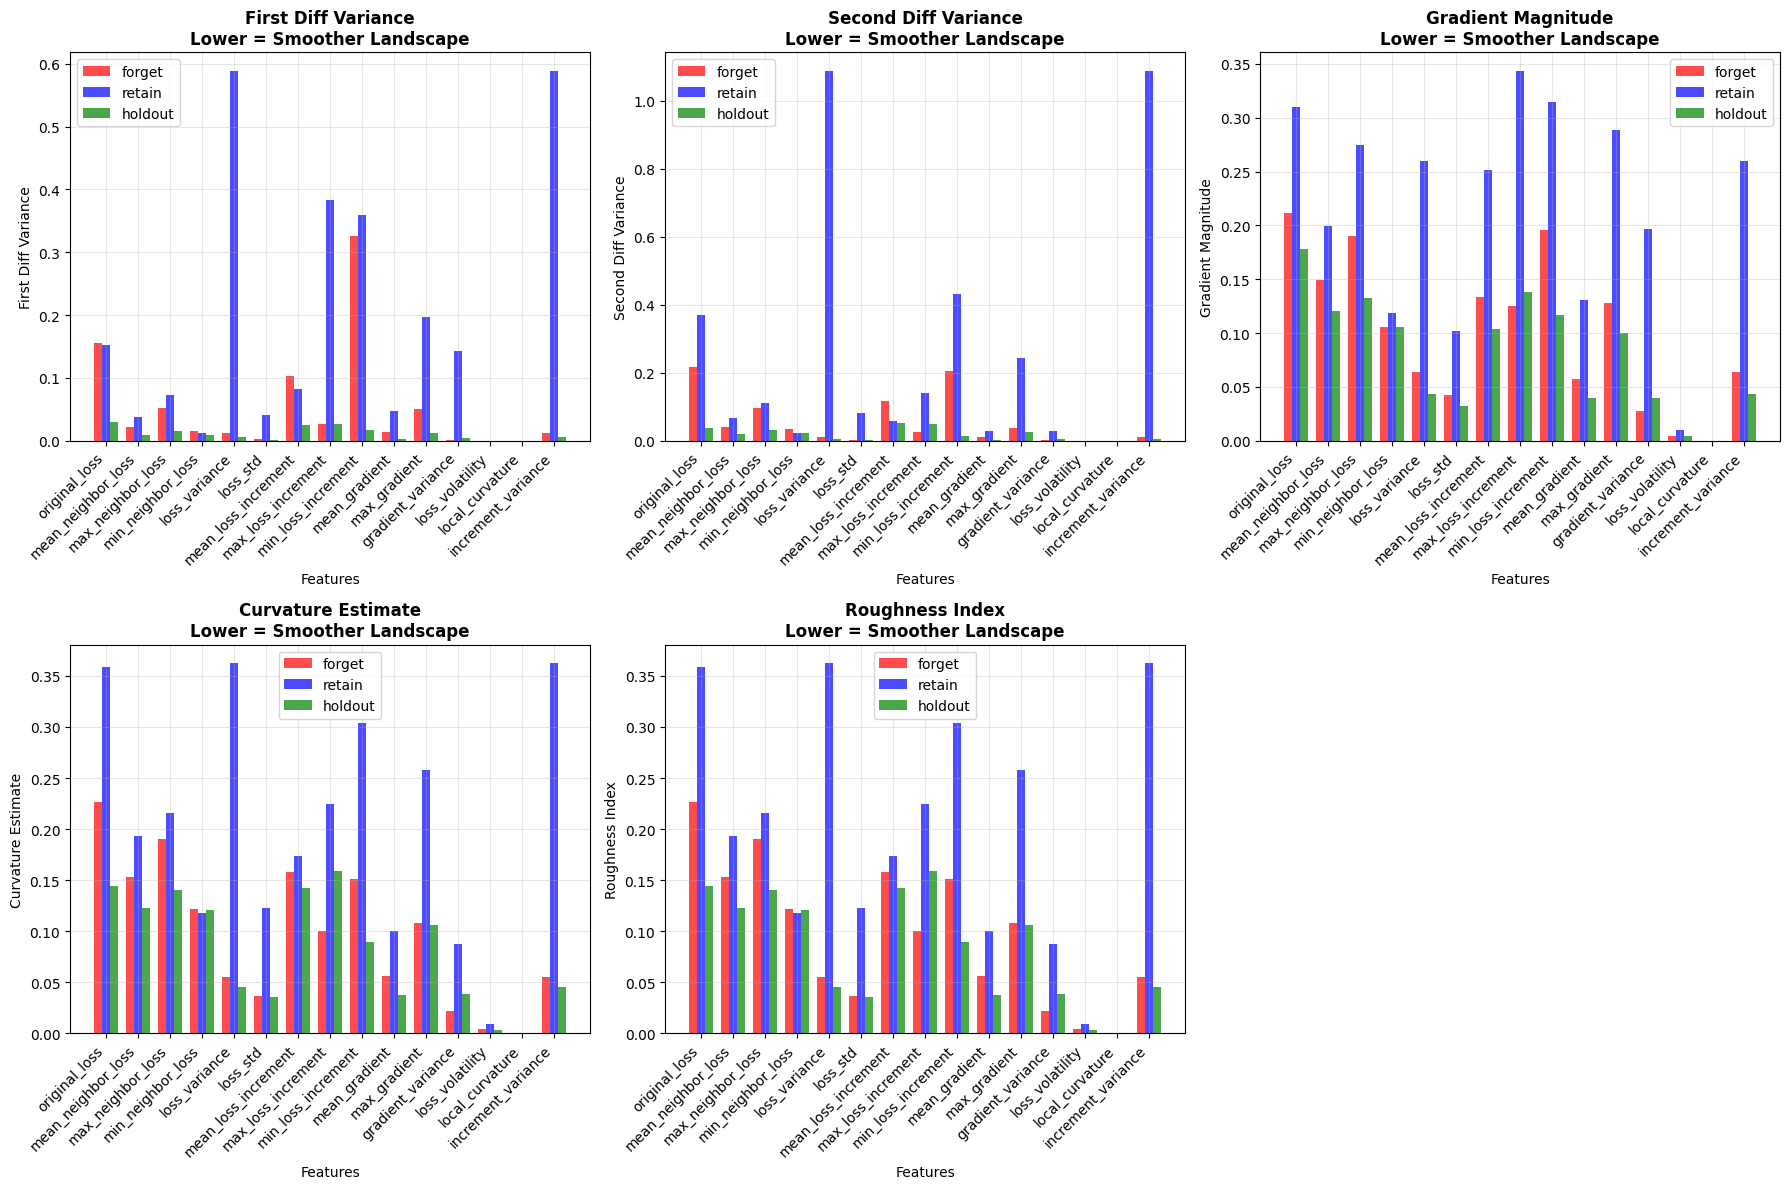

In [30]:
# Visualize smoothness properties
def plot_smoothness_comparison(smoothness_results, features_labels):
    """Plot comparison of smoothness properties across datasets."""
    
    smoothness_metrics = ['first_diff_var', 'second_diff_var', 'gradient_magnitude', 'curvature_estimate', 'roughness_index']
    metric_names = ['First Diff Variance', 'Second Diff Variance', 'Gradient Magnitude', 'Curvature Estimate', 'Roughness Index']
    datasets = list(smoothness_results.keys())
    
    # Create subplots for each smoothness metric
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    colors = {'retain': 'blue', 'holdout': 'green', 'forget': 'red'}
    
    for metric_idx, (metric, metric_name) in enumerate(zip(smoothness_metrics, metric_names)):
        ax = axes[metric_idx]
        
        # Collect data for this metric
        x_positions = np.arange(len(features_labels))
        width = 0.25
        
        for dataset_idx, dataset in enumerate(datasets):
            values = []
            for feat_name in features_labels:
                if feat_name in smoothness_results[dataset]:
                    values.append(smoothness_results[dataset][feat_name][metric])
                else:
                    values.append(0)
            
            offset = (dataset_idx - 1) * width
            bars = ax.bar(x_positions + offset, values, width, 
                         label=dataset, color=colors.get(dataset, 'gray'), alpha=0.7)
        
        ax.set_title(f'{metric_name}\nLower = Smoother Landscape', fontweight='bold')
        ax.set_xlabel('Features')
        ax.set_ylabel(f'{metric_name}')
        ax.set_xticks(x_positions)
        ax.set_xticklabels(features_labels, rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Hide the last subplot
    axes[-1].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'{plots_base_dir}/smoothness_comparison.png', bbox_inches='tight', dpi=150)
    plt.show()

# Plot smoothness comparison
plot_smoothness_comparison(smoothness_results, features_labels)

In [31]:
def analyze_prediction_transfer(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor):
    """
    Analyze how well models trained on one dataset generalize to others.
    """
    datasets = {
        'retain': norm_retain_tensor,
        'holdout': norm_holdout_tensor,
        'forget': norm_forget_tensor
    }
    
    transfer_results = {}
    
    # For each pair of datasets
    for train_name, train_tensor in datasets.items():
        for test_name, test_tensor in datasets.items():
            if train_name == test_name:
                continue
            
            # Create binary classification problem (train_set vs others)
            other_datasets = [v for k, v in datasets.items() if k != train_name]
            negative_data = torch.cat(other_datasets, dim=0)
            
            # Train data
            X_train = torch.cat([train_tensor, negative_data], dim=0).numpy()
            y_train = np.concatenate([np.ones(len(train_tensor)), np.zeros(len(negative_data))])
            
            # Test data (binary: test_set vs others)
            other_test = [v for k, v in datasets.items() if k != test_name]
            negative_test = torch.cat(other_test, dim=0)
            
            X_test = torch.cat([test_tensor, negative_test], dim=0).numpy()
            y_test = np.concatenate([np.ones(len(test_tensor)), np.zeros(len(negative_test))])
            
            # Train model
            clf = LogisticRegression(random_state=42, max_iter=300)
            clf.fit(X_train, y_train)
            
            # Evaluate
            y_pred = clf.predict(X_test)
            y_proba = clf.predict_proba(X_test)[:, 1]
            
            accuracy = accuracy_score(y_test, y_pred)
            auc_score = roc_auc_score(y_test, y_proba)
            
            transfer_results[f"train_{train_name}_test_{test_name}"] = {
                'accuracy': accuracy,
                'auc': auc_score,
                'model': clf
            }
    
    return transfer_results

# Run transfer analysis
print("Analyzing prediction transfer...")
transfer_results = analyze_prediction_transfer(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

Analyzing prediction transfer...


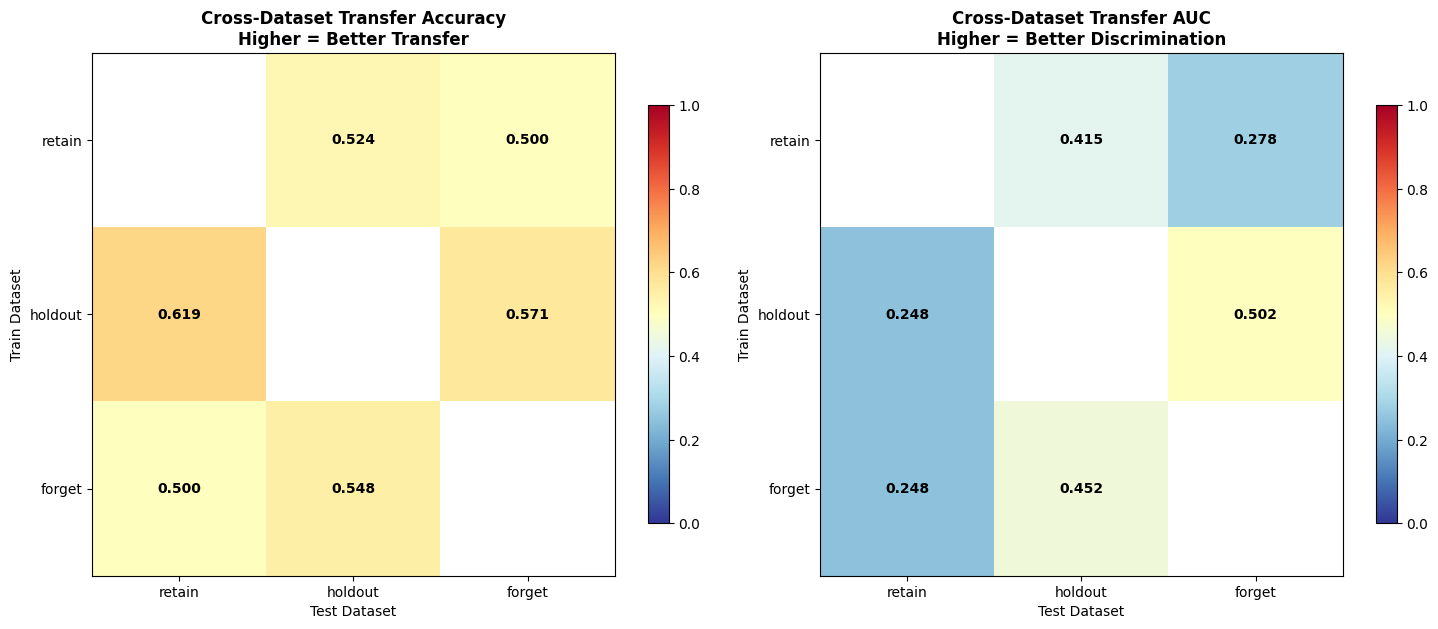

In [32]:
# Visualize transfer learning results
def plot_transfer_results(transfer_results):
    """Plot transfer learning results as heatmaps."""
    
    datasets = ['retain', 'holdout', 'forget']
    
    # Create matrices for accuracy and AUC
    accuracy_matrix = np.zeros((3, 3))
    auc_matrix = np.zeros((3, 3))
    
    for i, train_dataset in enumerate(datasets):
        for j, test_dataset in enumerate(datasets):
            if train_dataset == test_dataset:
                accuracy_matrix[i, j] = np.nan  # Same dataset
                auc_matrix[i, j] = np.nan
            else:
                key = f"train_{train_dataset}_test_{test_dataset}"
                if key in transfer_results:
                    accuracy_matrix[i, j] = transfer_results[key]['accuracy']
                    auc_matrix[i, j] = transfer_results[key]['auc']
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Accuracy heatmap
    im1 = ax1.imshow(accuracy_matrix, cmap='RdYlBu_r', vmin=0, vmax=1)
    ax1.set_title('Cross-Dataset Transfer Accuracy\nHigher = Better Transfer', fontweight='bold')
    ax1.set_xlabel('Test Dataset')
    ax1.set_ylabel('Train Dataset')
    ax1.set_xticks(range(3))
    ax1.set_yticks(range(3))
    ax1.set_xticklabels(datasets)
    ax1.set_yticklabels(datasets)
    
    # Add text annotations for accuracy
    for i in range(3):
        for j in range(3):
            if not np.isnan(accuracy_matrix[i, j]):
                text = ax1.text(j, i, f'{accuracy_matrix[i, j]:.3f}',
                               ha="center", va="center", color="black", fontweight='bold')
    
    plt.colorbar(im1, ax=ax1, shrink=0.8)
    
    # AUC heatmap
    im2 = ax2.imshow(auc_matrix, cmap='RdYlBu_r', vmin=0, vmax=1)
    ax2.set_title('Cross-Dataset Transfer AUC\nHigher = Better Discrimination', fontweight='bold')
    ax2.set_xlabel('Test Dataset')
    ax2.set_ylabel('Train Dataset')
    ax2.set_xticks(range(3))
    ax2.set_yticks(range(3))
    ax2.set_xticklabels(datasets)
    ax2.set_yticklabels(datasets)
    
    # Add text annotations for AUC
    for i in range(3):
        for j in range(3):
            if not np.isnan(auc_matrix[i, j]):
                text = ax2.text(j, i, f'{auc_matrix[i, j]:.3f}',
                               ha="center", va="center", color="black", fontweight='bold')
    
    plt.colorbar(im2, ax=ax2, shrink=0.8)
    
    plt.tight_layout()
    plt.savefig(f'{plots_base_dir}/transfer_learning_results.png', bbox_inches='tight', dpi=150)
    plt.show()

# Plot transfer results
plot_transfer_results(transfer_results)

In [33]:
def create_landscape_summary_report(stat_distances, topology_results, smoothness_results, transfer_results):
    """Create a comprehensive summary report of all landscape comparisons."""
    
    print("="*80)
    print("COMPREHENSIVE LANDSCAPE COMPARISON SUMMARY")
    print("="*80)
    
    # Statistical Distances Summary
    print("\n1. STATISTICAL DISTANCES SUMMARY:")
    print("-" * 40)
    for comparison, distances in stat_distances.items():
        print(f"\n{comparison.upper()}:")
        
        # Average across all features for each metric
        wasserstein_avg = np.mean([d['wasserstein'] for d in distances.values()])
        ks_avg = np.mean([d['ks_statistic'] for d in distances.values()])
        js_avg = np.mean([d['jensen_shannon'] for d in distances.values()])
        
        print(f"  Average Wasserstein Distance: {wasserstein_avg:.4f}")
        print(f"  Average KS Statistic: {ks_avg:.4f}")
        print(f"  Average Jensen-Shannon Divergence: {js_avg:.4f}")
    
    # Topology Summary
    print("\n2. TOPOLOGICAL PROPERTIES SUMMARY:")
    print("-" * 40)
    for dataset, topology in topology_results.items():
        print(f"\n{dataset.upper()}:")
        
        # Average distance statistics
        dist_stats = topology['distance_stats']
        print(f"  Mean pairwise distance: {dist_stats['mean_distance']:.4f}")
        print(f"  Distance std deviation: {dist_stats['std_distance']:.4f}")
        print(f"  Distance range: {dist_stats['max_distance'] - dist_stats['min_distance']:.4f}")
    
    # Transfer Learning Summary
    print("\n3. TRANSFER LEARNING SUMMARY:")
    print("-" * 40)
    for transfer_pair, results in transfer_results.items():
        print(f"{transfer_pair}: Accuracy={results['accuracy']:.3f}, AUC={results['auc']:.3f}")
    
    # Key Insights
    print("\n4. KEY INSIGHTS:")
    print("-" * 40)
    
    # Find most similar and dissimilar pairs
    avg_distances = {}
    for comparison, distances in stat_distances.items():
        avg_distances[comparison] = np.mean([d['wasserstein'] for d in distances.values()])
    
    most_similar = min(avg_distances, key=avg_distances.get)
    most_dissimilar = max(avg_distances, key=avg_distances.get)
    
    print(f"• Most similar datasets: {most_similar} (Wasserstein: {avg_distances[most_similar]:.4f})")
    print(f"• Most dissimilar datasets: {most_dissimilar} (Wasserstein: {avg_distances[most_dissimilar]:.4f})")
    
    # Best transfer performance
    best_transfer = max(transfer_results, key=lambda x: transfer_results[x]['auc'])
    worst_transfer = min(transfer_results, key=lambda x: transfer_results[x]['auc'])
    
    print(f"• Best transfer performance: {best_transfer} (AUC: {transfer_results[best_transfer]['auc']:.3f})")
    print(f"• Worst transfer performance: {worst_transfer} (AUC: {transfer_results[worst_transfer]['auc']:.3f})")
    
    print("\n" + "="*80)

# Generate comprehensive summary
create_landscape_summary_report(stat_distances, topology_results, smoothness_results, transfer_results)

COMPREHENSIVE LANDSCAPE COMPARISON SUMMARY

1. STATISTICAL DISTANCES SUMMARY:
----------------------------------------

RETAIN_VS_HOLDOUT:
  Average Wasserstein Distance: 0.6899
  Average KS Statistic: 0.3396
  Average Jensen-Shannon Divergence: 0.3656

RETAIN_VS_FORGET:
  Average Wasserstein Distance: 0.7634
  Average KS Statistic: 0.3619
  Average Jensen-Shannon Divergence: 0.4177

HOLDOUT_VS_FORGET:
  Average Wasserstein Distance: 0.2246
  Average KS Statistic: 0.2130
  Average Jensen-Shannon Divergence: 0.4144

2. TOPOLOGICAL PROPERTIES SUMMARY:
----------------------------------------

FORGET:
  Mean pairwise distance: 3.7476
  Distance std deviation: 2.1473
  Distance range: 11.4870

RETAIN:
  Mean pairwise distance: 6.4506
  Distance std deviation: 4.1987
  Distance range: 17.0543

HOLDOUT:
  Mean pairwise distance: 3.2917
  Distance std deviation: 1.4427
  Distance range: 7.4850

3. TRANSFER LEARNING SUMMARY:
----------------------------------------
train_retain_test_holdout: A

In [34]:
# Final comprehensive comparison - Run all methods together
print("Running comprehensive landscape analysis...")
print("This will generate multiple comparison plots and a summary report.")

# Create a summary of all results
comprehensive_results = {
    'statistical_distances': stat_distances,
    'manifold_results': manifold_results,
    'clustering_results': clustering_results,
    'topology_results': topology_results,
    'smoothness_results': smoothness_results,
    'transfer_results': transfer_results
}

# Save results for future reference
import pickle
results_file = f'{plots_base_dir}/comprehensive_landscape_results.pkl'
with open(results_file, 'wb') as f:
    pickle.dump(comprehensive_results, f)

print(f"\nAll results saved to: {results_file}")
print(f"All plots saved to: {plots_base_dir}/")

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)
print("Generated plots:")
print("1. Statistical distances heatmap")
print("2. Manifold embeddings (PCA, t-SNE, UMAP, Isomap)")
print("3. Clustering analysis (Silhouette & Elbow)")
print("4. Topological properties comparison")
print("5. Landscape smoothness comparison")
print("6. Transfer learning performance")
print("="*60)

Running comprehensive landscape analysis...
This will generate multiple comparison plots and a summary report.

All results saved to: loss_landscape_plots/comprehensive_landscape_results.pkl
All plots saved to: loss_landscape_plots/

ANALYSIS COMPLETE!
Generated plots:
1. Statistical distances heatmap
2. Manifold embeddings (PCA, t-SNE, UMAP, Isomap)
3. Clustering analysis (Silhouette & Elbow)
4. Topological properties comparison
5. Landscape smoothness comparison
6. Transfer learning performance


In [35]:
# ============================================================================
# SPECIALIZED ILL DISCRIMINATIVE ANALYSIS
# ============================================================================

def analyze_ill_feature_discrimination(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels):
    """
    Analyze which ILL features are most discriminative between forget/retain/holdout.
    """
    from sklearn.metrics import classification_report
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_score
    from sklearn.preprocessing import LabelEncoder
    
    # Combine all data
    X = torch.cat([norm_forget_tensor, norm_retain_tensor, norm_holdout_tensor], dim=0).numpy()
    y = (['forget'] * len(norm_forget_tensor) + 
         ['retain'] * len(norm_retain_tensor) + 
         ['holdout'] * len(norm_holdout_tensor))
    
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    # Feature importance analysis
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y_encoded)
    
    # Cross-validation scores
    cv_scores = cross_val_score(rf, X, y_encoded, cv=5, scoring='accuracy')
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': features_labels,
        'importance': rf.feature_importances_,
        'rank': range(1, len(features_labels) + 1)
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    feature_importance['rank'] = range(1, len(feature_importance) + 1)
    
    # Predictions for confusion matrix
    y_pred = rf.predict(X)
    
    print("ILL FEATURE DISCRIMINATION ANALYSIS")
    print("="*50)
    print(f"Cross-validation accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")
    print(f"Overall classification accuracy: {rf.score(X, y_encoded):.3f}")
    print("\nTop 5 Most Discriminative ILL Features:")
    for i, row in feature_importance.head().iterrows():
        print(f"{row['rank']}. {row['feature']}: {row['importance']:.4f}")
    
    return {
        'feature_importance': feature_importance,
        'cv_scores': cv_scores,
        'model': rf,
        'predictions': y_pred,
        'true_labels': y_encoded,
        'label_encoder': le
    }

# Run ILL discrimination analysis
print("Analyzing ILL feature discrimination...")
ill_discrimination = analyze_ill_feature_discrimination(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

Analyzing ILL feature discrimination...
ILL FEATURE DISCRIMINATION ANALYSIS
Cross-validation accuracy: 0.500 (+/- 0.190)
Overall classification accuracy: 1.000

Top 5 Most Discriminative ILL Features:
1. min_loss_increment: 0.0924
2. mean_loss_increment: 0.0868
3. original_loss: 0.0849
4. mean_gradient: 0.0848
5. min_neighbor_loss: 0.0807


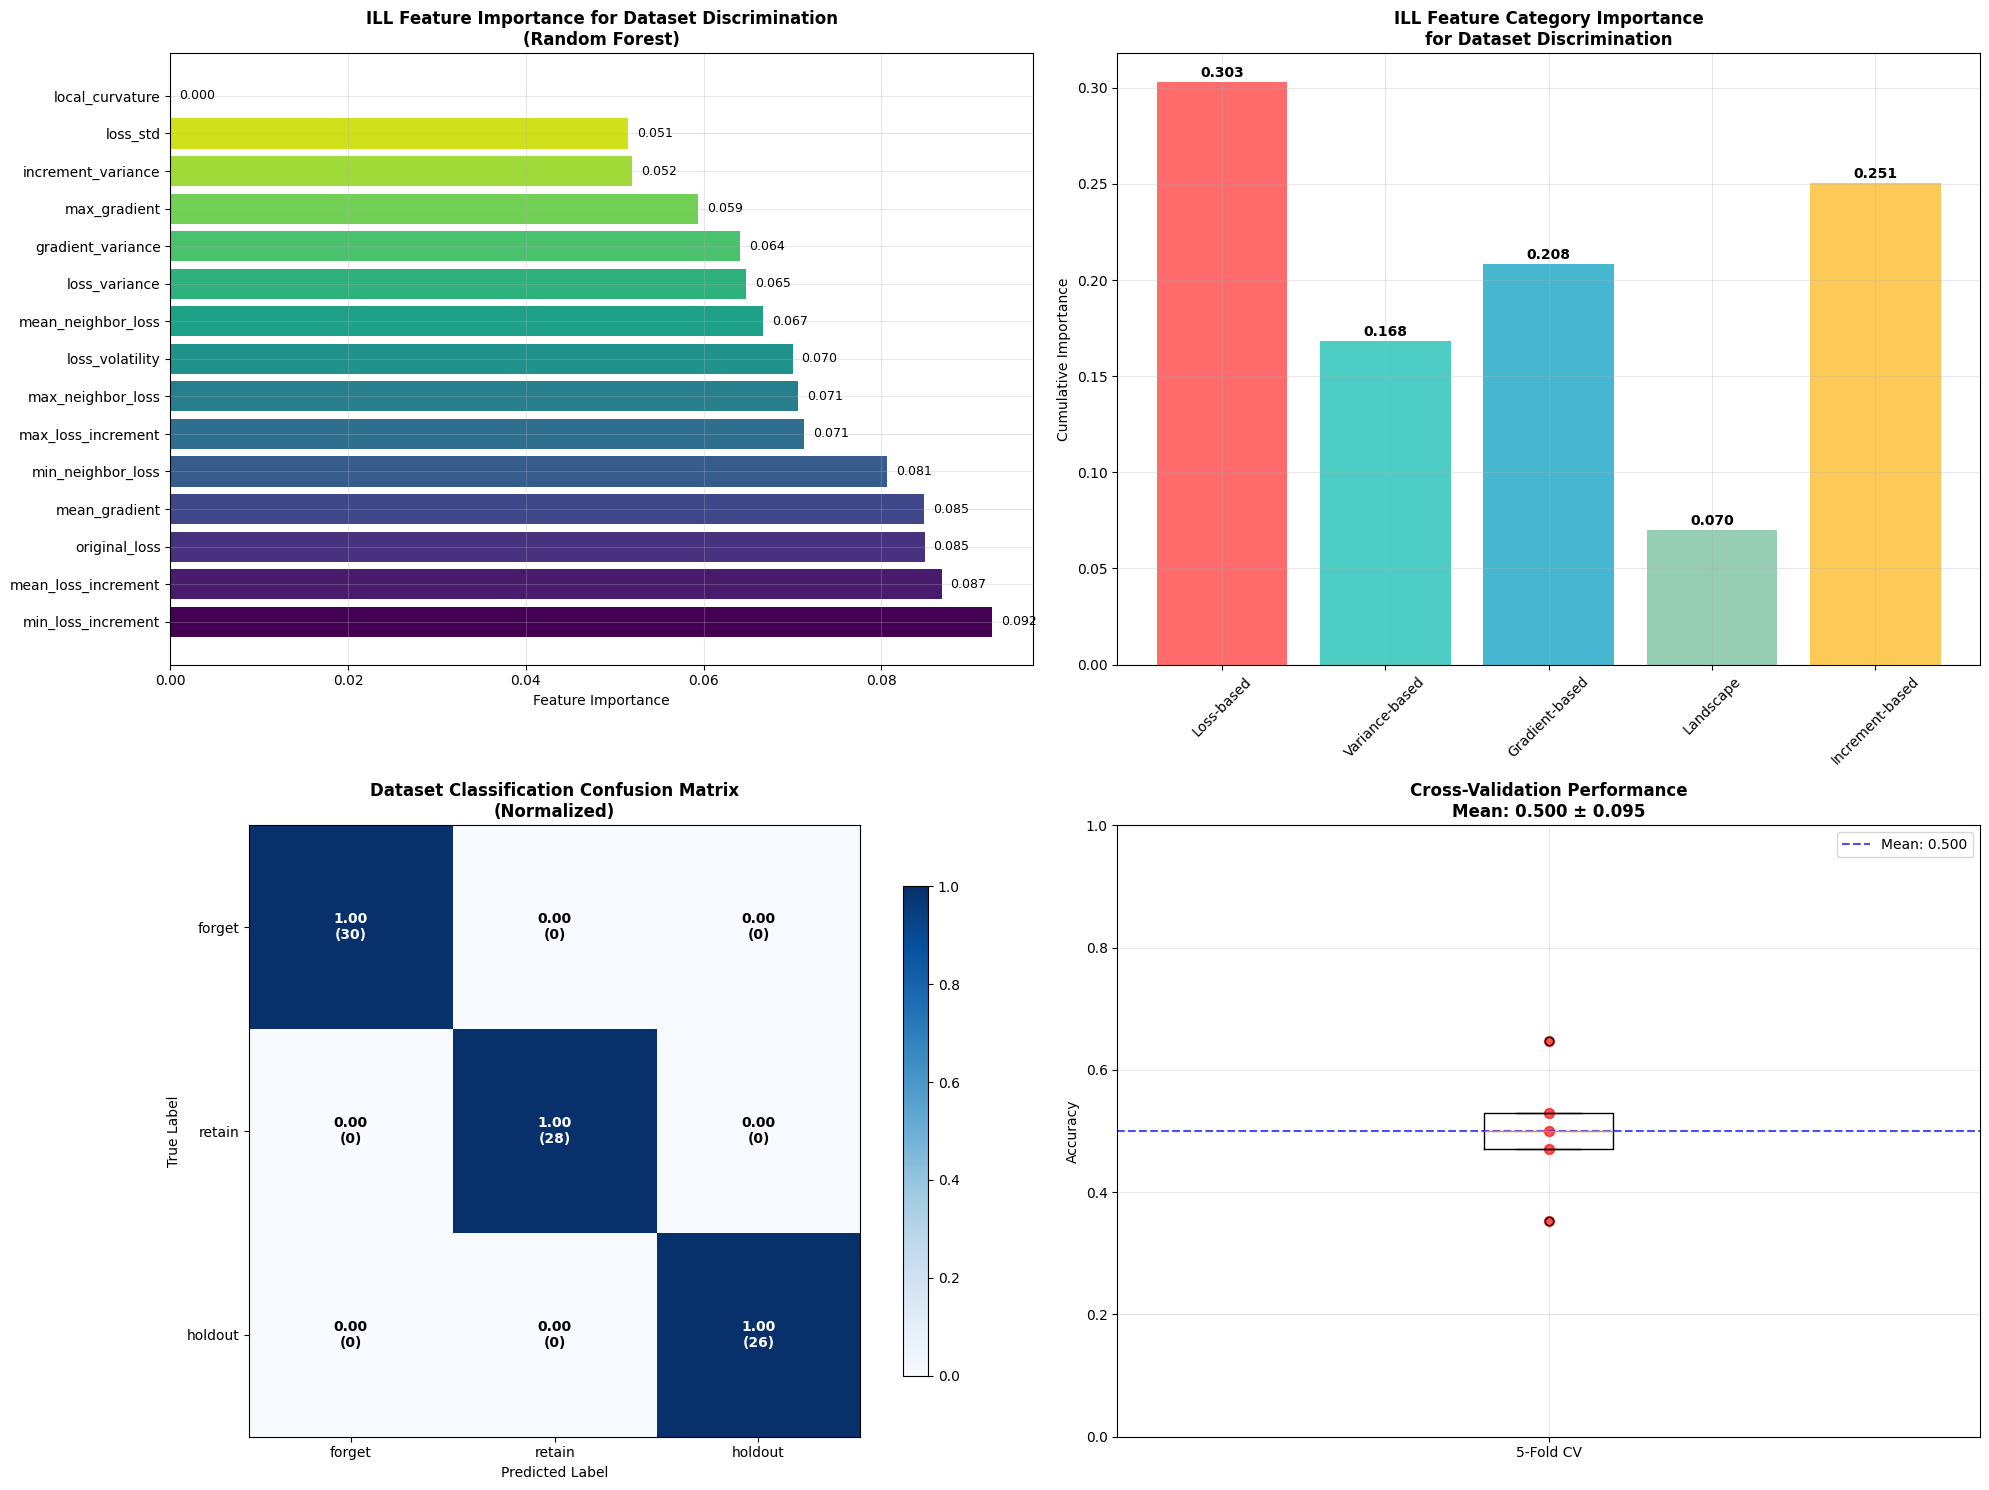

In [36]:
def plot_ill_discrimination_analysis(ill_discrimination, features_labels):
    """
    Visualize ILL feature discrimination results.
    """
    feature_importance = ill_discrimination['feature_importance']
    
    # Create comprehensive discrimination plot
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 15))
    
    # 1. Feature Importance Bar Plot
    colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance)))
    bars = ax1.barh(range(len(feature_importance)), feature_importance['importance'], color=colors)
    ax1.set_yticks(range(len(feature_importance)))
    ax1.set_yticklabels(feature_importance['feature'])
    ax1.set_xlabel('Feature Importance')
    ax1.set_title('ILL Feature Importance for Dataset Discrimination\n(Random Forest)', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax1.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', ha='left', va='center', fontsize=9)
    
    # 2. Feature Importance by Category
    feature_categories = {
        'Loss-based': ['original_loss', 'mean_neighbor_loss', 'max_neighbor_loss', 'min_neighbor_loss'],
        'Variance-based': ['loss_variance', 'loss_std', 'increment_variance'],
        'Gradient-based': ['mean_gradient', 'max_gradient', 'gradient_variance'],
        'Landscape': ['loss_volatility', 'local_curvature'],
        'Increment-based': ['mean_loss_increment', 'max_loss_increment', 'min_loss_increment']
    }
    
    category_importance = {}
    for category, features in feature_categories.items():
        category_features = feature_importance[feature_importance['feature'].isin(features)]
        category_importance[category] = category_features['importance'].sum()
    
    categories = list(category_importance.keys())
    importances = list(category_importance.values())
    
    bars2 = ax2.bar(categories, importances, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57'])
    ax2.set_title('ILL Feature Category Importance\nfor Dataset Discrimination', fontweight='bold')
    ax2.set_ylabel('Cumulative Importance')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 3. Confusion Matrix
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(ill_discrimination['true_labels'], ill_discrimination['predictions'])
    
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    im = ax3.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
    ax3.set_title('Dataset Classification Confusion Matrix\n(Normalized)', fontweight='bold')
    
    class_names = ['forget', 'retain', 'holdout']
    tick_marks = np.arange(len(class_names))
    ax3.set_xticks(tick_marks)
    ax3.set_yticks(tick_marks)
    ax3.set_xticklabels(class_names)
    ax3.set_yticklabels(class_names)
    ax3.set_ylabel('True Label')
    ax3.set_xlabel('Predicted Label')
    
    # Add text annotations
    thresh = cm_normalized.max() / 2.
    for i, j in np.ndindex(cm_normalized.shape):
        ax3.text(j, i, f'{cm_normalized[i, j]:.2f}\n({cm[i, j]})',
                ha="center", va="center",
                color="white" if cm_normalized[i, j] > thresh else "black",
                fontweight='bold')
    
    plt.colorbar(im, ax=ax3, shrink=0.8)
    
    # 4. Cross-validation scores
    cv_scores = ill_discrimination['cv_scores']
    ax4.boxplot([cv_scores], labels=['5-Fold CV'])
    ax4.scatter([1] * len(cv_scores), cv_scores, color='red', alpha=0.7, s=50)
    ax4.set_ylabel('Accuracy')
    ax4.set_title(f'Cross-Validation Performance\nMean: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}', 
                 fontweight='bold')
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim([0, 1])
    
    # Add mean line
    ax4.axhline(y=cv_scores.mean(), color='blue', linestyle='--', alpha=0.7, 
               label=f'Mean: {cv_scores.mean():.3f}')
    ax4.legend()
    
    plt.tight_layout()
    plt.savefig(f'{plots_base_dir}/ill_discrimination_analysis.png', bbox_inches='tight', dpi=150)
    plt.show()

# Plot ILL discrimination analysis
plot_ill_discrimination_analysis(ill_discrimination, features_labels)

In [37]:
def analyze_loss_landscape_topology_discrimination(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels):
    """
    Specialized analysis of loss landscape topology for discrimination.
    """
    datasets = {
        'forget': norm_forget_tensor,
        'retain': norm_retain_tensor,
        'holdout': norm_holdout_tensor
    }
    
    # Define feature groups for targeted analysis
    feature_groups = {
        'Loss Features': ['original_loss', 'mean_neighbor_loss', 'max_neighbor_loss', 'min_neighbor_loss'],
        'Variance Features': ['loss_variance', 'loss_std', 'increment_variance'],
        'Gradient Features': ['mean_gradient', 'max_gradient', 'gradient_variance'],
        'Landscape Features': ['loss_volatility', 'local_curvature'],
        'Increment Features': ['mean_loss_increment', 'max_loss_increment', 'min_loss_increment']
    }
    
    discrimination_results = {}
    
    print("LOSS LANDSCAPE TOPOLOGY DISCRIMINATION ANALYSIS")
    print("="*55)
    
    for group_name, group_features in feature_groups.items():
        print(f"\n{group_name.upper()}:")
        print("-" * 30)
        
        group_results = {}
        
        # Get indices for this feature group
        feature_indices = [i for i, feat in enumerate(features_labels) if feat in group_features]
        
        if not feature_indices:
            continue
            
        for dataset_name, tensor in datasets.items():
            group_data = tensor[:, feature_indices].numpy()
            
            # Compute discrimination metrics for this group
            group_results[dataset_name] = {
                'mean_values': np.mean(group_data, axis=0),
                'std_values': np.std(group_data, axis=0),
                'median_values': np.median(group_data, axis=0),
                'q75_values': np.percentile(group_data, 75, axis=0),
                'q25_values': np.percentile(group_data, 25, axis=0),
                'range_values': np.ptp(group_data, axis=0),
                'feature_names': [features_labels[i] for i in feature_indices]
            }
        
        # Calculate pairwise discrimination potential
        pairs = [('forget', 'retain'), ('forget', 'holdout'), ('retain', 'holdout')]
        
        for pair in pairs:
            data1 = datasets[pair[0]][:, feature_indices].numpy()
            data2 = datasets[pair[1]][:, feature_indices].numpy()
            
            # Effect size (Cohen's d) for each feature in the group
            effect_sizes = []
            for i in range(len(feature_indices)):
                pooled_std = np.sqrt((np.var(data1[:, i]) + np.var(data2[:, i])) / 2)
                if pooled_std > 0:
                    cohens_d = (np.mean(data1[:, i]) - np.mean(data2[:, i])) / pooled_std
                    effect_sizes.append(abs(cohens_d))
                else:
                    effect_sizes.append(0)
            
            avg_effect_size = np.mean(effect_sizes)
            max_effect_size = np.max(effect_sizes)
            
            print(f"  {pair[0]} vs {pair[1]}:")
            print(f"    Average effect size: {avg_effect_size:.3f}")
            print(f"    Max effect size: {max_effect_size:.3f}")
            
            # Store for later use
            group_results[f"{pair[0]}_vs_{pair[1]}_effect_sizes"] = effect_sizes
            group_results[f"{pair[0]}_vs_{pair[1]}_avg_effect"] = avg_effect_size
        
        discrimination_results[group_name] = group_results
    
    return discrimination_results

# Run loss landscape topology discrimination analysis
print("Analyzing loss landscape topology for discrimination...")
topology_discrimination = analyze_loss_landscape_topology_discrimination(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

Analyzing loss landscape topology for discrimination...
LOSS LANDSCAPE TOPOLOGY DISCRIMINATION ANALYSIS

LOSS FEATURES:
------------------------------
  forget vs retain:
    Average effect size: 1.085
    Max effect size: 1.231
  forget vs holdout:
    Average effect size: 0.468
    Max effect size: 0.745
  retain vs holdout:
    Average effect size: 0.753
    Max effect size: 1.031

VARIANCE FEATURES:
------------------------------
  forget vs retain:
    Average effect size: 0.460
    Max effect size: 0.467
  forget vs holdout:
    Average effect size: 0.294
    Max effect size: 0.326
  retain vs holdout:
    Average effect size: 0.589
    Max effect size: 0.609

GRADIENT FEATURES:
------------------------------
  forget vs retain:
    Average effect size: 0.723
    Max effect size: 0.828
  forget vs holdout:
    Average effect size: 0.234
    Max effect size: 0.346
  retain vs holdout:
    Average effect size: 0.630
    Max effect size: 0.790

LANDSCAPE FEATURES:
------------------

In [38]:
def analyze_loss_landscape_boundaries(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels):
    """
    Analyze decision boundaries in the loss landscape for dataset discrimination.
    """
    from sklearn.svm import SVC
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.naive_bayes import GaussianNB
    from sklearn.model_selection import cross_val_score
    from sklearn.metrics import accuracy_score
    
    # Combine data
    X = torch.cat([norm_forget_tensor, norm_retain_tensor, norm_holdout_tensor], dim=0).numpy()
    y = np.array(['forget'] * len(norm_forget_tensor) + 
                 ['retain'] * len(norm_retain_tensor) + 
                 ['holdout'] * len(norm_holdout_tensor))
    
    # Different classifiers to understand boundary complexity
    classifiers = {
        'Linear SVM': SVC(kernel='linear', random_state=42),
        'RBF SVM': SVC(kernel='rbf', random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
        'Naive Bayes': GaussianNB(),
        'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42)
    }
    
    boundary_results = {}
    
    print("LOSS LANDSCAPE BOUNDARY ANALYSIS")
    print("="*40)
    print("Testing different classifiers to understand decision boundary complexity...")
    
    for clf_name, clf in classifiers.items():
        # Cross-validation
        cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
        
        # Fit and predict
        clf.fit(X, y)
        y_pred = clf.predict(X)
        train_accuracy = accuracy_score(y, y_pred)
        
        boundary_results[clf_name] = {
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'train_accuracy': train_accuracy,
            'model': clf
        }
        
        print(f"{clf_name:15}: CV={cv_scores.mean():.3f}±{cv_scores.std():.3f}, Train={train_accuracy:.3f}")
    
    return boundary_results

# Run boundary analysis
print("Analyzing loss landscape boundaries...")
boundary_results = analyze_loss_landscape_boundaries(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

Analyzing loss landscape boundaries...
LOSS LANDSCAPE BOUNDARY ANALYSIS
Testing different classifiers to understand decision boundary complexity...
Linear SVM     : CV=0.535±0.029, Train=0.619
RBF SVM        : CV=0.549±0.075, Train=0.655
Decision Tree  : CV=0.465±0.047, Train=0.976
Naive Bayes    : CV=0.560±0.145, Train=0.524
Random Forest  : CV=0.500±0.046, Train=1.000


In [39]:
def analyze_pairwise_discrimination(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels):
    """
    Detailed pairwise analysis between forget/retain/holdout datasets.
    """
    from scipy.stats import ttest_ind, mannwhitneyu
    from sklearn.model_selection import cross_val_score
    
    datasets = {
        'forget': norm_forget_tensor,
        'retain': norm_retain_tensor,
        'holdout': norm_holdout_tensor
    }
    
    pairs = [('forget', 'retain'), ('forget', 'holdout'), ('retain', 'holdout')]
    pairwise_results = {}
    
    print("PAIRWISE DISCRIMINATION ANALYSIS")
    print("="*40)
    
    for pair in pairs:
        print(f"\n{pair[0].upper()} vs {pair[1].upper()}:")
        print("-" * 25)
        
        data1 = datasets[pair[0]].numpy()
        data2 = datasets[pair[1]].numpy()
        
        pair_results = {}
        
        # Combine for binary classification
        X_pair = np.vstack([data1, data2])
        y_pair = np.array([0] * len(data1) + [1] * len(data2))
        
        # Binary classifier for this pair
        clf = RandomForestClassifier(n_estimators=100, random_state=42)
        clf.fit(X_pair, y_pair)
        
        # Feature importance for this specific pair
        feature_importance_pair = pd.DataFrame({
            'feature': features_labels,
            'importance': clf.feature_importances_
        }).sort_values('importance', ascending=False)
        
        # Statistical tests for each feature
        statistical_results = []
        for i, feature in enumerate(features_labels):
            vals1 = data1[:, i]
            vals2 = data2[:, i]
            
            # T-test
            t_stat, t_pvalue = ttest_ind(vals1, vals2)
            
            # Mann-Whitney U test
            u_stat, u_pvalue = mannwhitneyu(vals1, vals2, alternative='two-sided')
            
            # Effect size (Cohen's d)
            pooled_std = np.sqrt((np.var(vals1) + np.var(vals2)) / 2)
            cohens_d = (np.mean(vals1) - np.mean(vals2)) / pooled_std if pooled_std > 0 else 0
            
            statistical_results.append({
                'feature': feature,
                'mean_diff': np.mean(vals1) - np.mean(vals2),
                'cohens_d': cohens_d,
                't_pvalue': t_pvalue,
                'u_pvalue': u_pvalue,
                'significant': t_pvalue < 0.05
            })
        
        stat_df = pd.DataFrame(statistical_results)
        stat_df = stat_df.sort_values('cohens_d', key=abs, ascending=False)
        
        # Cross-validation for this pair
        cv_scores = cross_val_score(clf, X_pair, y_pair, cv=5, scoring='accuracy')
        
        pair_results = {
            'classification_accuracy': cv_scores.mean(),
            'classification_std': cv_scores.std(),
            'feature_importance': feature_importance_pair,
            'statistical_tests': stat_df,
            'significant_features': stat_df[stat_df['significant']],
            'top_discriminative': stat_df.head(3)
        }
        
        pairwise_results[f"{pair[0]}_vs_{pair[1]}"] = pair_results
        
        print(f"Binary classification accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
        print(f"Significant features: {len(stat_df[stat_df['significant']])}/{len(features_labels)}")
        print("Top 3 discriminative features:")
        for idx, row in stat_df.head(3).iterrows():
            print(f"  {row['feature']}: Cohen's d = {row['cohens_d']:.3f}, p = {row['t_pvalue']:.4f}")
    
    return pairwise_results

# Run pairwise discrimination analysis
print("Analyzing pairwise discrimination...")
pairwise_results = analyze_pairwise_discrimination(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

Analyzing pairwise discrimination...
PAIRWISE DISCRIMINATION ANALYSIS

FORGET vs RETAIN:
-------------------------
Binary classification accuracy: 0.677 ± 0.051
Significant features: 9/15
Top 3 discriminative features:
  original_loss: Cohen's d = -1.231, p = 0.0000
  mean_neighbor_loss: Cohen's d = -1.102, p = 0.0002
  min_neighbor_loss: Cohen's d = -1.032, p = 0.0004

FORGET vs HOLDOUT:
-------------------------
Binary classification accuracy: 0.536 ± 0.075
Significant features: 1/15
Top 3 discriminative features:
  min_neighbor_loss: Cohen's d = -0.745, p = 0.0072
  mean_neighbor_loss: Cohen's d = -0.489, p = 0.0738
  gradient_variance: Cohen's d = -0.346, p = 0.1989

RETAIN vs HOLDOUT:
-------------------------
Binary classification accuracy: 0.615 ± 0.128
Significant features: 10/15
Top 3 discriminative features:
  min_loss_increment: Cohen's d = -1.073, p = 0.0003
  original_loss: Cohen's d = 1.031, p = 0.0004
  mean_loss_increment: Cohen's d = -0.921, p = 0.0015


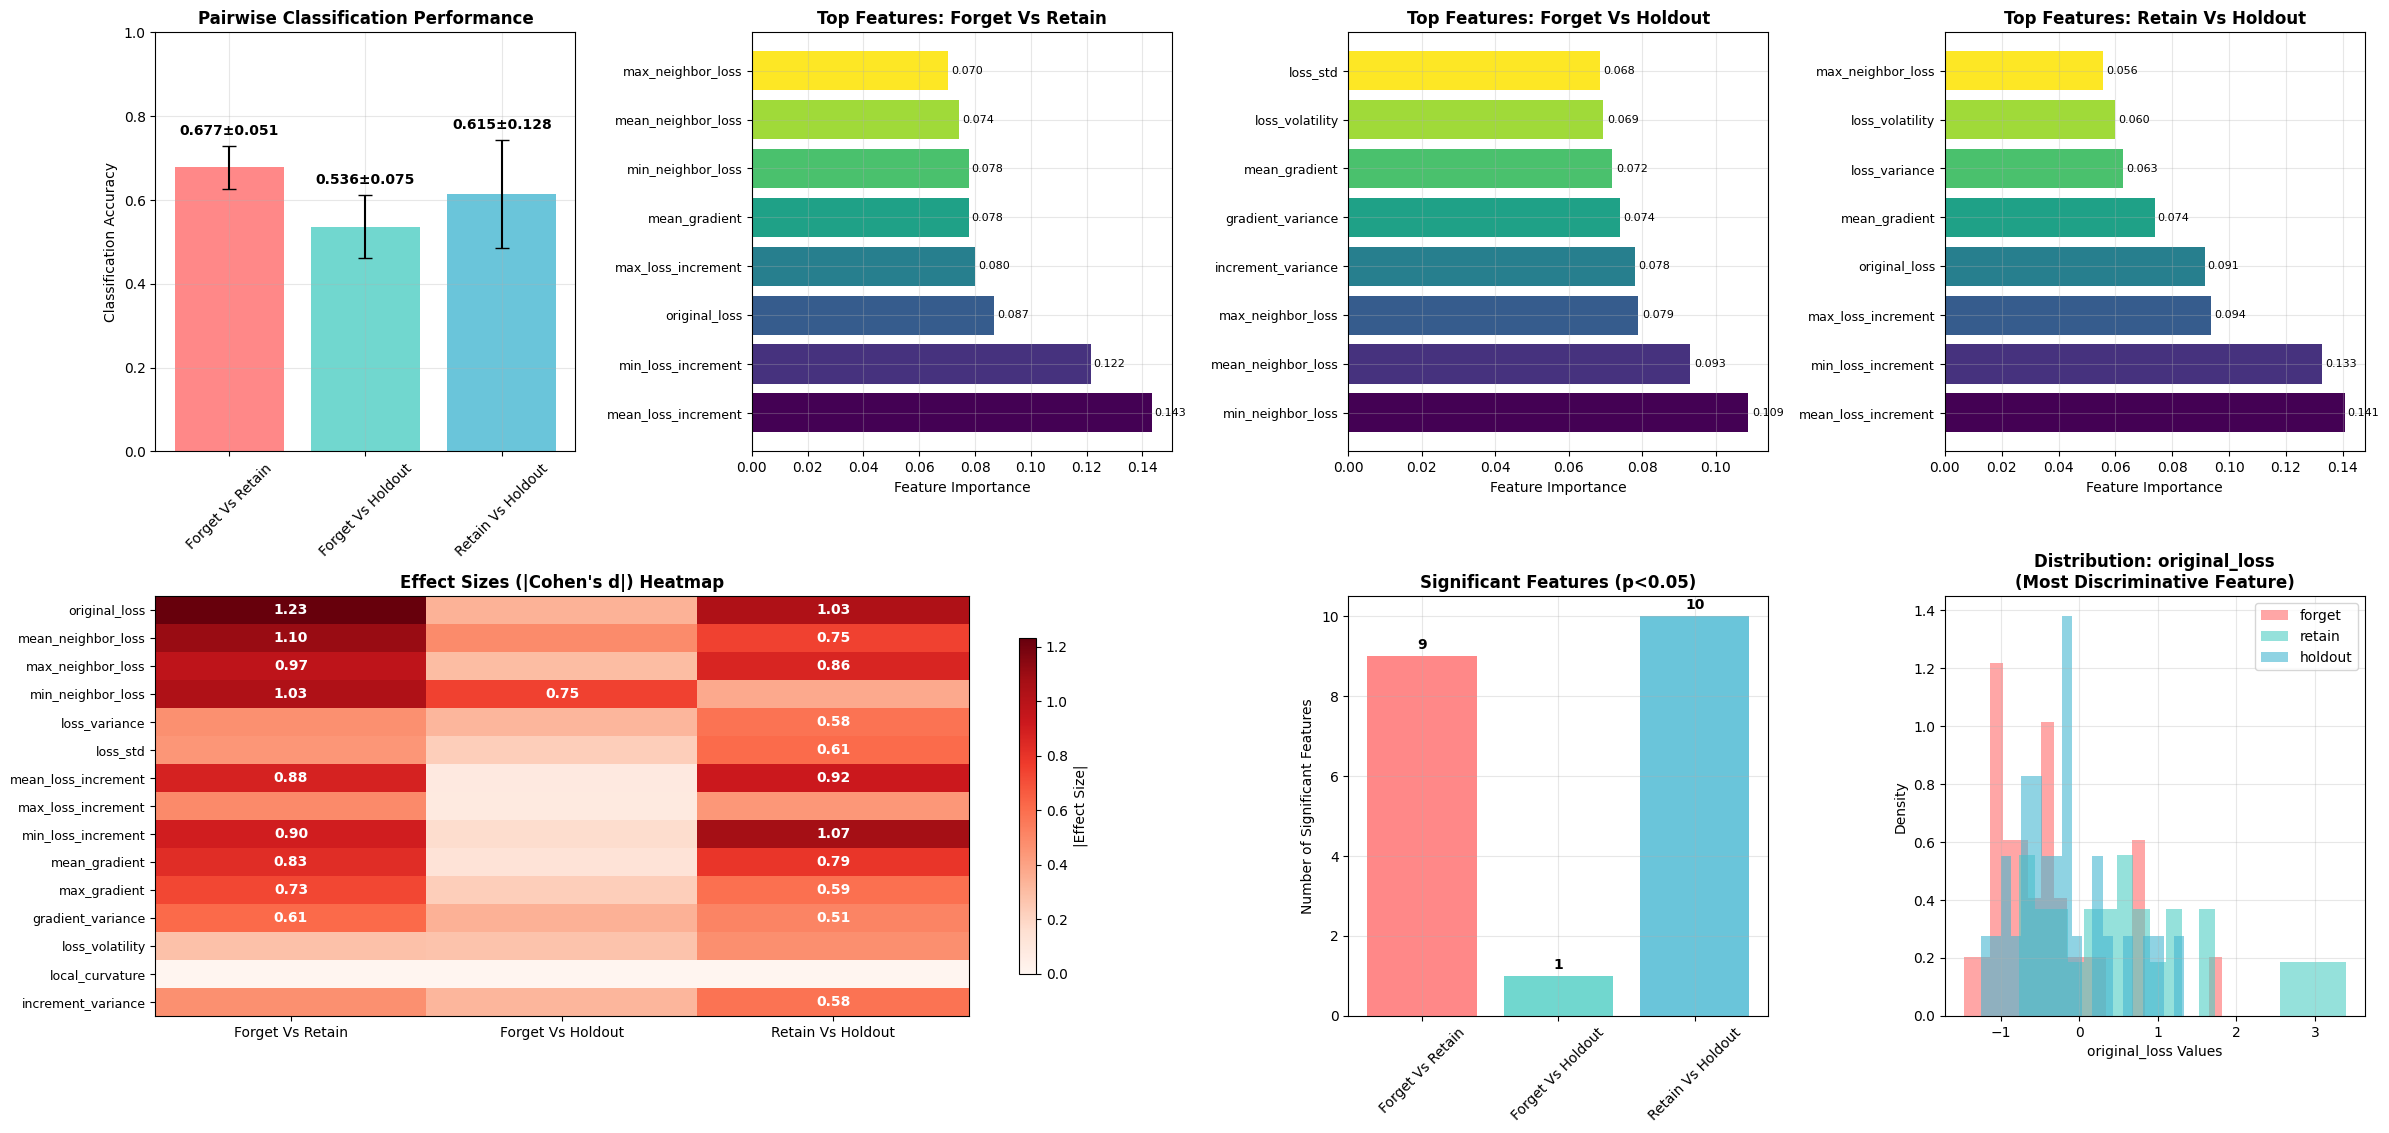


MOST DISCRIMINATIVE FEATURE ACROSS ALL PAIRS: original_loss
Average effect size: 0.868


In [40]:
def plot_pairwise_discrimination_results(pairwise_results, features_labels):
    """
    Comprehensive visualization of pairwise discrimination results.
    """
    pairs = list(pairwise_results.keys())
    n_pairs = len(pairs)
    
    # Create a large figure with multiple subplots
    fig = plt.figure(figsize=(24, 16))
    
    # 1. Classification accuracy comparison
    ax1 = plt.subplot(3, 4, 1)
    accuracies = [pairwise_results[pair]['classification_accuracy'] for pair in pairs]
    stds = [pairwise_results[pair]['classification_std'] for pair in pairs]
    
    bars = ax1.bar(range(n_pairs), accuracies, yerr=stds, capsize=5, 
                   color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
    ax1.set_xticks(range(n_pairs))
    ax1.set_xticklabels([pair.replace('_', ' ').title() for pair in pairs], rotation=45)
    ax1.set_ylabel('Classification Accuracy')
    ax1.set_title('Pairwise Classification Performance', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1])
    
    # Add value labels on bars
    for i, (bar, acc, std) in enumerate(zip(bars, accuracies, stds)):
        ax1.text(bar.get_x() + bar.get_width()/2., acc + std + 0.02,
                f'{acc:.3f}±{std:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 2-4. Feature importance for each pair
    for i, pair in enumerate(pairs):
        ax = plt.subplot(3, 4, i + 2)
        
        feat_imp = pairwise_results[pair]['feature_importance'].head(8)  # Top 8 features
        
        bars = ax.barh(range(len(feat_imp)), feat_imp['importance'], 
                      color=plt.cm.viridis(np.linspace(0, 1, len(feat_imp))))
        ax.set_yticks(range(len(feat_imp)))
        ax.set_yticklabels(feat_imp['feature'], fontsize=9)
        ax.set_xlabel('Feature Importance')
        ax.set_title(f'Top Features: {pair.replace("_", " ").title()}', fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add value labels
        for j, bar in enumerate(bars):
            width = bar.get_width()
            ax.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                   f'{width:.3f}', ha='left', va='center', fontsize=8)
    
    # 5. Effect sizes heatmap
    ax5 = plt.subplot(3, 4, (5, 6))
    
    # Create effect size matrix
    effect_matrix = np.zeros((len(features_labels), len(pairs)))
    for i, pair in enumerate(pairs):
        stat_tests = pairwise_results[pair]['statistical_tests']
        for j, feature in enumerate(features_labels):
            effect_size = stat_tests[stat_tests['feature'] == feature]['cohens_d'].iloc[0]
            effect_matrix[j, i] = abs(effect_size)
    
    im = ax5.imshow(effect_matrix, cmap='Reds', aspect='auto')
    ax5.set_xticks(range(len(pairs)))
    ax5.set_xticklabels([pair.replace('_', ' ').title() for pair in pairs])
    ax5.set_yticks(range(len(features_labels)))
    ax5.set_yticklabels(features_labels, fontsize=9)
    ax5.set_title('Effect Sizes (|Cohen\'s d|) Heatmap', fontweight='bold')
    
    # Add text annotations for high effect sizes
    for i in range(len(features_labels)):
        for j in range(len(pairs)):
            if effect_matrix[i, j] > 0.5:  # Only show large effects
                ax5.text(j, i, f'{effect_matrix[i, j]:.2f}',
                        ha="center", va="center", color="white", fontweight='bold')
    
    plt.colorbar(im, ax=ax5, shrink=0.8, label='|Effect Size|')
    
    # 6. Significant features count
    ax6 = plt.subplot(3, 4, 7)
    
    sig_counts = [len(pairwise_results[pair]['significant_features']) for pair in pairs]
    bars = ax6.bar(range(n_pairs), sig_counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
    ax6.set_xticks(range(n_pairs))
    ax6.set_xticklabels([pair.replace('_', ' ').title() for pair in pairs], rotation=45)
    ax6.set_ylabel('Number of Significant Features')
    ax6.set_title('Significant Features (p<0.05)', fontweight='bold')
    ax6.grid(True, alpha=0.3)
    
    # Add value labels
    for bar, count in zip(bars, sig_counts):
        ax6.text(bar.get_x() + bar.get_width()/2., count + 0.1,
                f'{count}', ha='center', va='bottom', fontweight='bold')
    
    # 7. Distribution comparison for most discriminative feature
    ax7 = plt.subplot(3, 4, 8)
    
    # Find the feature with highest average effect size across all pairs
    avg_effects = {}
    for feature in features_labels:
        effects = []
        for pair in pairs:
            stat_tests = pairwise_results[pair]['statistical_tests']
            effect = abs(stat_tests[stat_tests['feature'] == feature]['cohens_d'].iloc[0])
            effects.append(effect)
        avg_effects[feature] = np.mean(effects)
    
    best_feature = max(avg_effects, key=avg_effects.get)
    best_feature_idx = features_labels.index(best_feature)
    
    # Plot distributions for the best discriminative feature
    datasets = {'forget': norm_forget_tensor, 'retain': norm_retain_tensor, 'holdout': norm_holdout_tensor}
    colors = {'forget': '#FF6B6B', 'retain': '#4ECDC4', 'holdout': '#45B7D1'}
    
    for dataset_name, tensor in datasets.items():
        values = tensor[:, best_feature_idx].numpy()
        ax7.hist(values, bins=20, alpha=0.6, label=dataset_name, color=colors[dataset_name], density=True)
    
    ax7.set_xlabel(f'{best_feature} Values')
    ax7.set_ylabel('Density')
    ax7.set_title(f'Distribution: {best_feature}\n(Most Discriminative Feature)', fontweight='bold')
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{plots_base_dir}/pairwise_discrimination_comprehensive.png', bbox_inches='tight', dpi=150)
    plt.show()
    
    return best_feature, avg_effects

# Plot comprehensive pairwise discrimination results
best_discriminative_feature, feature_discrimination_scores = plot_pairwise_discrimination_results(pairwise_results, features_labels)

print(f"\nMOST DISCRIMINATIVE FEATURE ACROSS ALL PAIRS: {best_discriminative_feature}")
print(f"Average effect size: {feature_discrimination_scores[best_discriminative_feature]:.3f}")

In [41]:
# ============================================================================
# COMPREHENSIVE ILL DISCRIMINATION SUMMARY
# ============================================================================

def create_ill_discrimination_summary_report(ill_discrimination, boundary_results, pairwise_results, 
                                            best_discriminative_feature, feature_discrimination_scores):
    """
    Generate a comprehensive summary report for ILL-based dataset discrimination.
    """
    print("="*80)
    print("COMPREHENSIVE INPUT LOSS LANDSCAPE (ILL) DISCRIMINATION REPORT")
    print("="*80)
    
    # Overall discrimination performance
    print("\n1. OVERALL DISCRIMINATION PERFORMANCE:")
    print("-" * 50)
    overall_cv = ill_discrimination['cv_scores'].mean()
    overall_std = ill_discrimination['cv_scores'].std()
    print(f"3-way classification (Forget/Retain/Holdout): {overall_cv:.3f} ± {overall_std:.3f}")
    
    print("\nClassifier comparison:")
    for clf_name, results in boundary_results.items():
        print(f"  {clf_name:15}: {results['cv_mean']:.3f} ± {results['cv_std']:.3f}")
    
    # Feature importance summary
    print("\n2. MOST DISCRIMINATIVE ILL FEATURES:")
    print("-" * 50)
    top_features = ill_discrimination['feature_importance'].head(5)
    for idx, row in top_features.iterrows():
        print(f"{row['rank']}. {row['feature']:20}: {row['importance']:.4f}")
    
    # Feature category analysis
    print("\n3. FEATURE CATEGORY DISCRIMINATION POWER:")
    print("-" * 50)
    feature_categories = {
        'Loss-based': ['original_loss', 'mean_neighbor_loss', 'max_neighbor_loss', 'min_neighbor_loss'],
        'Variance-based': ['loss_variance', 'loss_std', 'increment_variance'],
        'Gradient-based': ['mean_gradient', 'max_gradient', 'gradient_variance'],
        'Landscape': ['loss_volatility', 'local_curvature'],
        'Increment-based': ['mean_loss_increment', 'max_loss_increment', 'min_loss_increment']
    }
    
    category_importance = {}
    for category, features in feature_categories.items():
        category_features = ill_discrimination['feature_importance'][
            ill_discrimination['feature_importance']['feature'].isin(features)
        ]
        category_importance[category] = category_features['importance'].sum()
    
    sorted_categories = sorted(category_importance.items(), key=lambda x: x[1], reverse=True)
    for category, importance in sorted_categories:
        print(f"  {category:15}: {importance:.4f}")
    
    # Pairwise discrimination
    print("\n4. PAIRWISE DISCRIMINATION RESULTS:")
    print("-" * 50)
    for pair_name, results in pairwise_results.items():
        acc = results['classification_accuracy']
        std = results['classification_std']
        n_sig = len(results['significant_features'])
        print(f"{pair_name.replace('_', ' ').title():20}: {acc:.3f}±{std:.3f} ({n_sig} significant features)")
    
    # Best discriminative features
    print(f"\n5. MOST DISCRIMINATIVE FEATURE OVERALL:")
    print("-" * 50)
    print(f"Feature: {best_discriminative_feature}")
    print(f"Average effect size across all pairs: {feature_discrimination_scores[best_discriminative_feature]:.3f}")
    
    # Recommendations
    print("\n6. RECOMMENDATIONS FOR ILL-BASED DISCRIMINATION:")
    print("-" * 50)
    
    best_pair = max(pairwise_results.items(), key=lambda x: x[1]['classification_accuracy'])
    worst_pair = min(pairwise_results.items(), key=lambda x: x[1]['classification_accuracy'])
    
    print(f"• Easiest to distinguish: {best_pair[0].replace('_', ' ')} ({best_pair[1]['classification_accuracy']:.3f})")
    print(f"• Hardest to distinguish: {worst_pair[0].replace('_', ' ')} ({worst_pair[1]['classification_accuracy']:.3f})")
    
    print(f"• Focus on top 3 features: {', '.join(top_features.head(3)['feature'].tolist())}")
    
    most_important_category = sorted_categories[0][0]
    print(f"• Most important feature category: {most_important_category}")
    
    # Best classifier
    best_classifier = max(boundary_results.items(), key=lambda x: x[1]['cv_mean'])
    print(f"• Best performing classifier: {best_classifier[0]} ({best_classifier[1]['cv_mean']:.3f})")
    
    print("\n" + "="*80)
    
    # Save comprehensive results
    comprehensive_ill_results = {
        'discrimination_analysis': ill_discrimination,
        'boundary_analysis': boundary_results,
        'pairwise_analysis': pairwise_results,
        'best_discriminative_feature': best_discriminative_feature,
        'feature_discrimination_scores': feature_discrimination_scores,
        'feature_categories': feature_categories,
        'category_importance': category_importance
    }
    
    results_file = f'{plots_base_dir}/comprehensive_ill_discrimination_results.pkl'
    with open(results_file, 'wb') as f:
        pickle.dump(comprehensive_ill_results, f)
    
    print(f"Complete ILL discrimination results saved to: {results_file}")
    
    return comprehensive_ill_results

# Generate comprehensive ILL discrimination summary
comprehensive_ill_results = create_ill_discrimination_summary_report(
    ill_discrimination, boundary_results, pairwise_results, 
    best_discriminative_feature, feature_discrimination_scores
)

print("\n" + "="*60)
print("ILL DISCRIMINATION ANALYSIS COMPLETE!")
print("="*60)
print("Generated specialized plots:")
print("1. ILL feature importance and discrimination analysis")
print("2. Pairwise discrimination comprehensive analysis")
print("3. Confusion matrices and cross-validation results")
print("4. Feature category importance analysis")
print("5. Decision boundary complexity analysis")
print("="*60)

COMPREHENSIVE INPUT LOSS LANDSCAPE (ILL) DISCRIMINATION REPORT

1. OVERALL DISCRIMINATION PERFORMANCE:
--------------------------------------------------
3-way classification (Forget/Retain/Holdout): 0.500 ± 0.095

Classifier comparison:
  Linear SVM     : 0.535 ± 0.029
  RBF SVM        : 0.549 ± 0.075
  Decision Tree  : 0.465 ± 0.047
  Naive Bayes    : 0.560 ± 0.145
  Random Forest  : 0.500 ± 0.046

2. MOST DISCRIMINATIVE ILL FEATURES:
--------------------------------------------------
1. min_loss_increment  : 0.0924
2. mean_loss_increment : 0.0868
3. original_loss       : 0.0849
4. mean_gradient       : 0.0848
5. min_neighbor_loss   : 0.0807

3. FEATURE CATEGORY DISCRIMINATION POWER:
--------------------------------------------------
  Loss-based     : 0.3029
  Increment-based: 0.2506
  Gradient-based : 0.2083
  Variance-based : 0.1682
  Landscape      : 0.0700

4. PAIRWISE DISCRIMINATION RESULTS:
--------------------------------------------------
Forget Vs Retain    : 0.677±0.051 (9

In [42]:
# Specialized Input Loss Landscape (ILL) Analysis Functions

def analyze_loss_landscape_categories(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels):
    """
    Analyze loss landscape features by semantic categories relevant to ILL.
    """
    # Define feature categories for ILL analysis
    feature_categories = {
        'Base Loss': ['original_loss', 'mean_neighbor_loss', 'max_neighbor_loss', 'min_neighbor_loss'],
        'Variability': ['loss_variance', 'loss_std', 'increment_variance'],
        'Gradient': ['mean_gradient', 'max_gradient', 'gradient_variance'],
        'Landscape': ['loss_volatility', 'local_curvature'],
        'Increment': ['mean_loss_increment', 'max_loss_increment', 'min_loss_increment']
    }
    
    datasets = {
        'retain': norm_retain_tensor,
        'holdout': norm_holdout_tensor,
        'forget': norm_forget_tensor
    }
    
    category_analysis = {}
    
    # Analyze each category
    for category, features in feature_categories.items():
        category_data = {}
        
        for dataset_name, tensor in datasets.items():
            category_features = []
            for feature in features:
                if feature in features_labels:
                    feat_idx = features_labels.index(feature)
                    category_features.append(tensor[:, feat_idx].numpy())
            
            if category_features:
                category_tensor = np.column_stack(category_features)
                
                # Compute category-level statistics
                category_data[dataset_name] = {
                    'mean_values': np.mean(category_tensor, axis=0),
                    'std_values': np.std(category_tensor, axis=0),
                    'category_mean': np.mean(category_tensor),
                    'category_std': np.std(category_tensor),
                    'feature_correlations': np.corrcoef(category_tensor.T),
                    'feature_names': [f for f in features if f in features_labels]
                }
        
        category_analysis[category] = category_data
    
    return category_analysis

# Run category analysis
print("Analyzing ILL features by semantic categories...")
category_analysis = analyze_loss_landscape_categories(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels)

Analyzing ILL features by semantic categories...


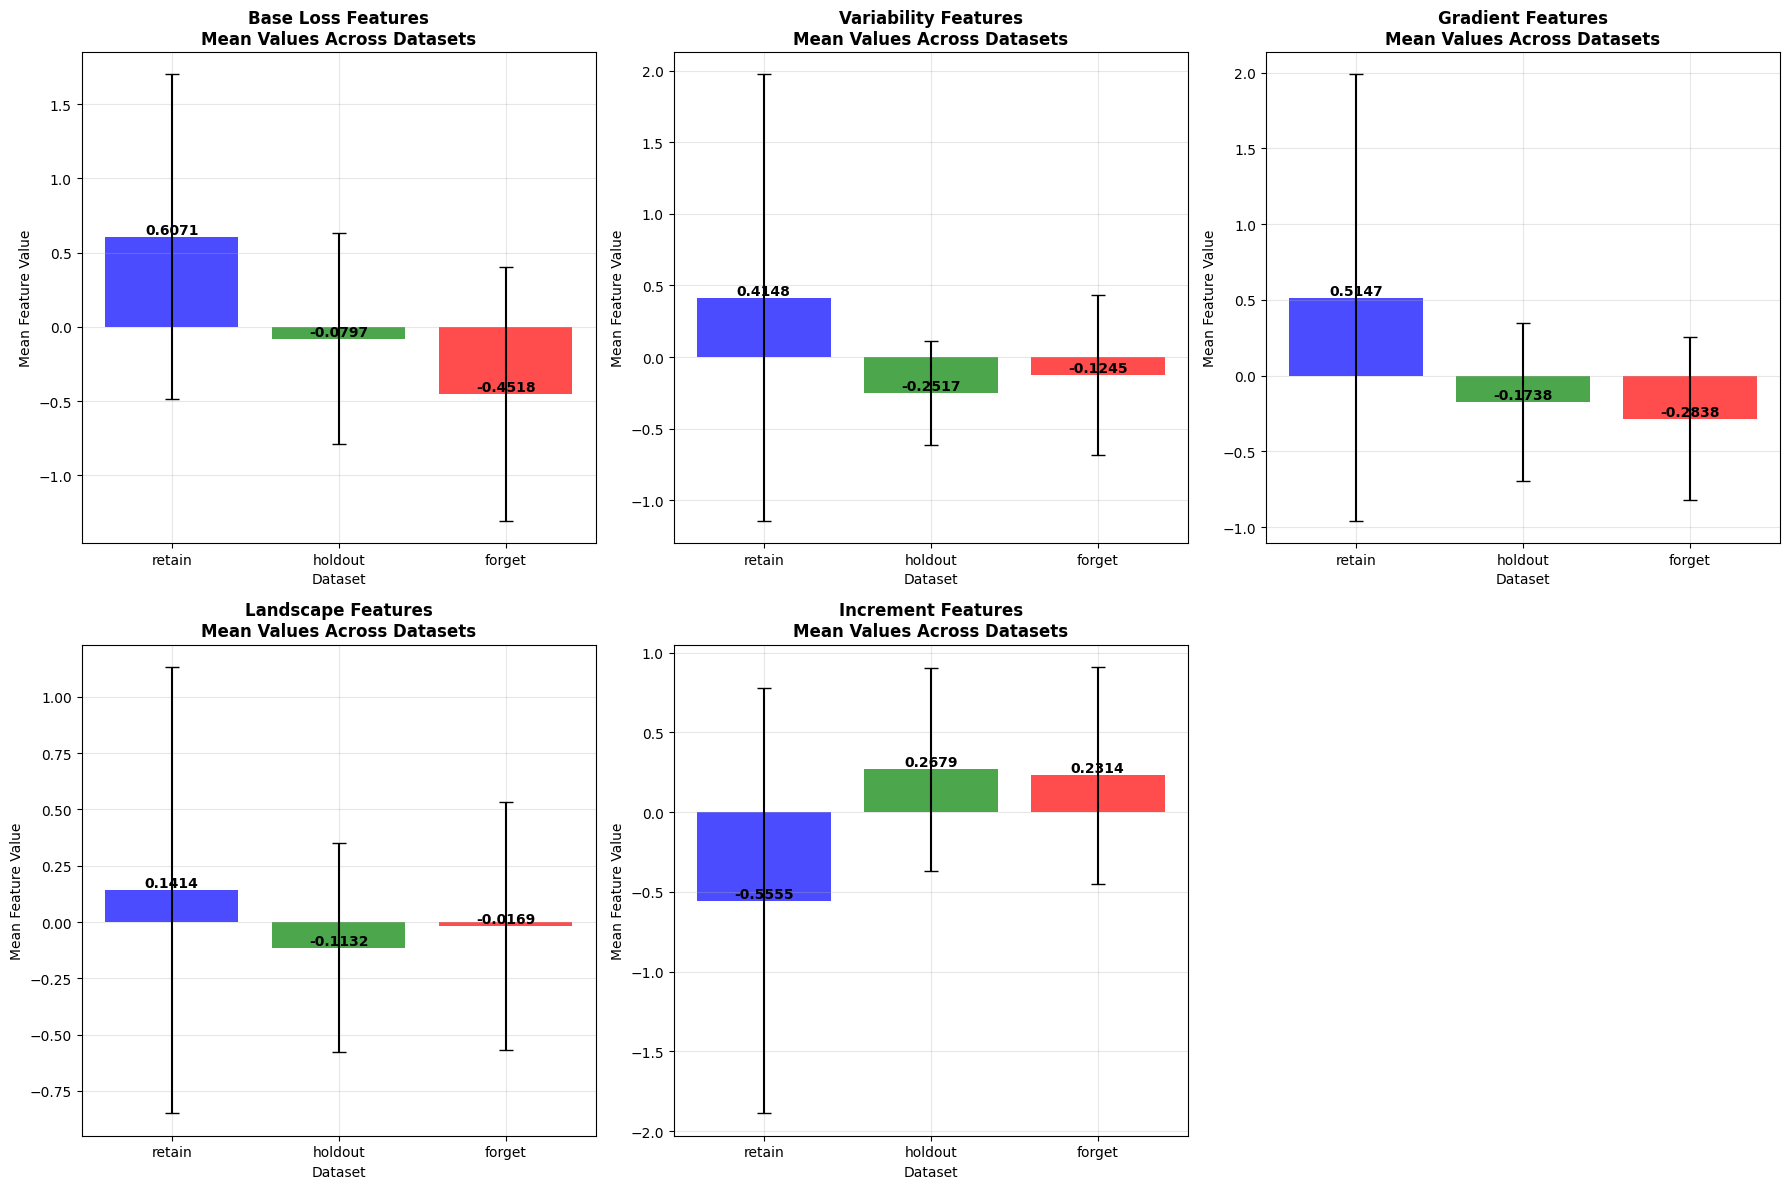

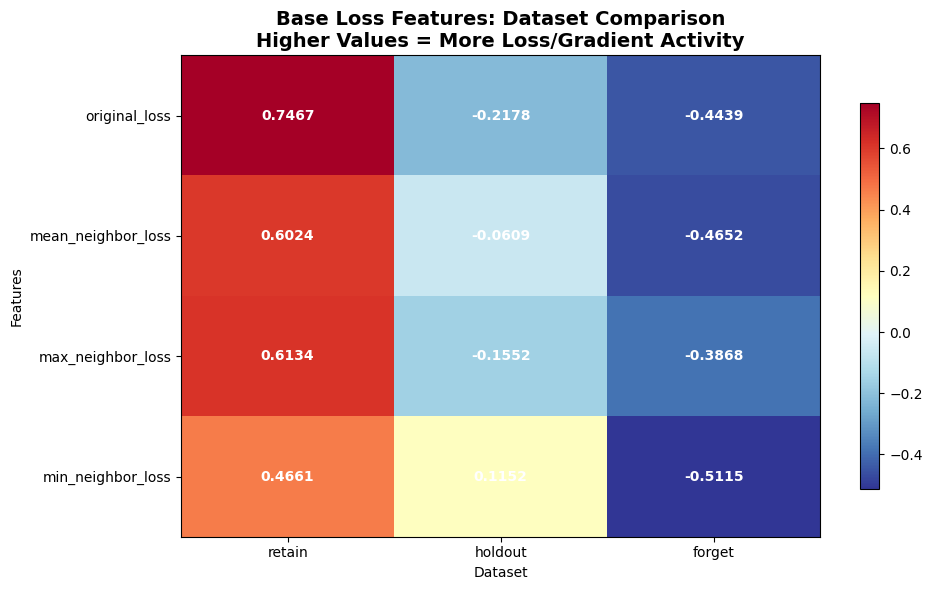

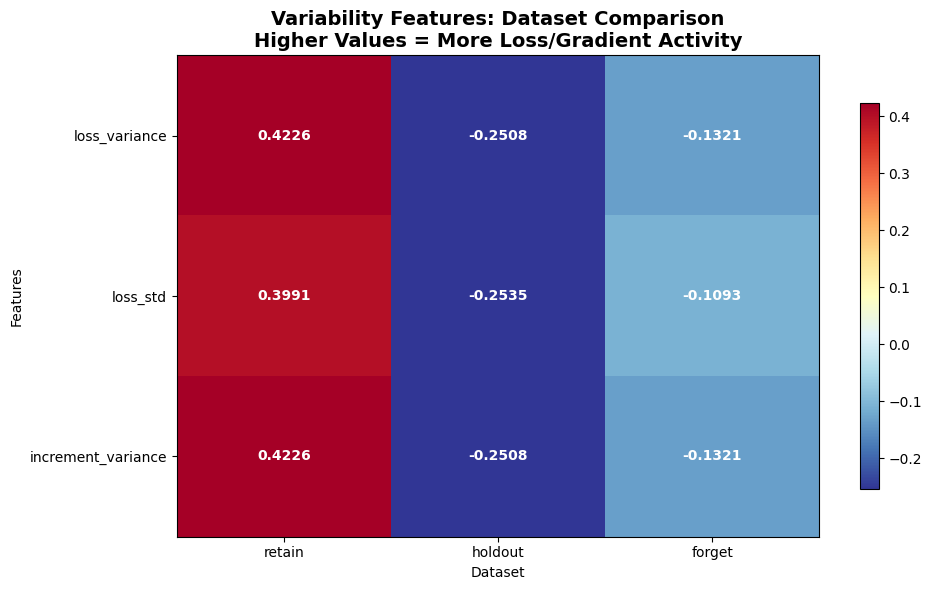

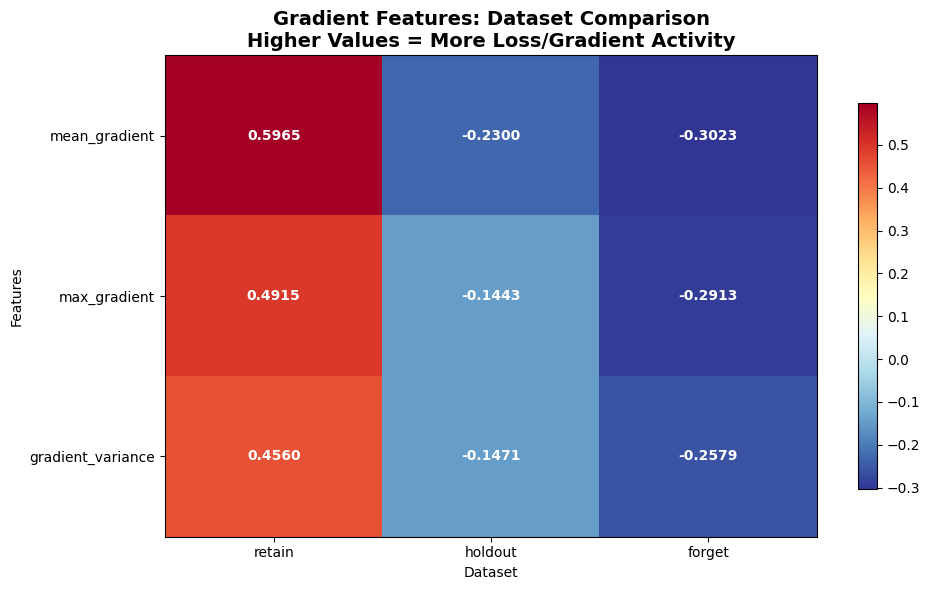

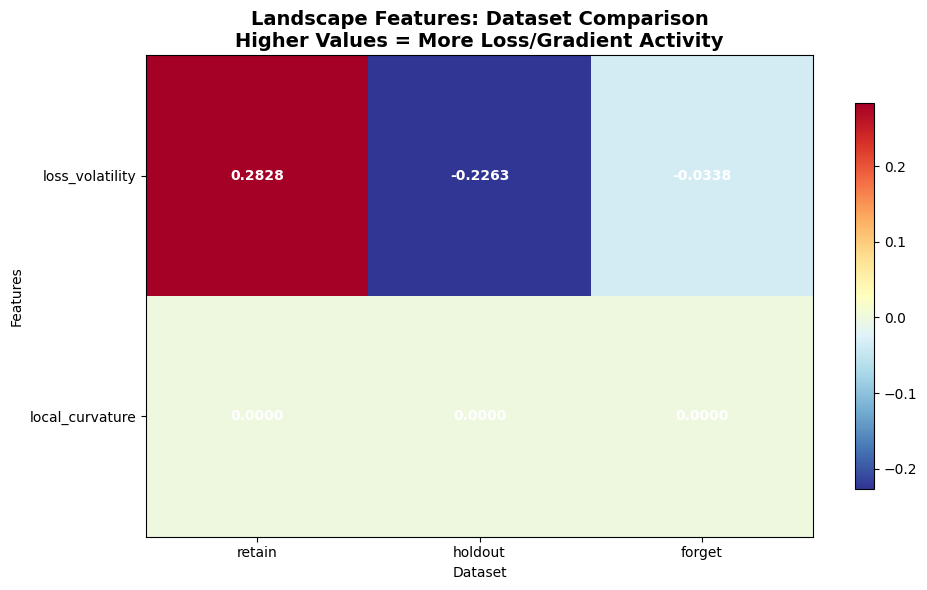

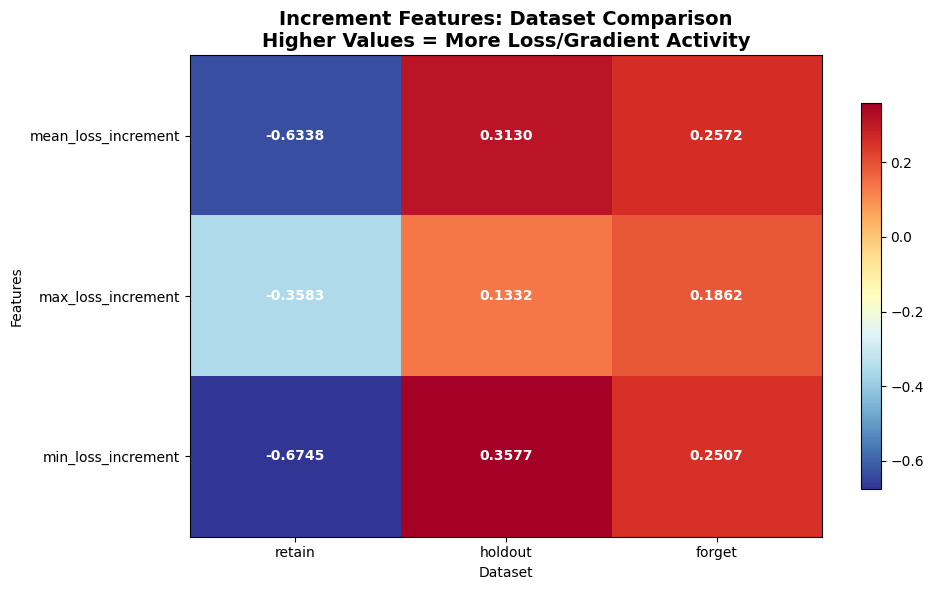

In [43]:
# Visualize ILL Category Analysis
def plot_ill_category_analysis(category_analysis):
    """
    Create comprehensive visualizations for ILL category analysis.
    """
    categories = list(category_analysis.keys())
    datasets = ['retain', 'holdout', 'forget']
    colors = {'retain': 'blue', 'holdout': 'green', 'forget': 'red'}
    
    # 1. Category-level means comparison
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, category in enumerate(categories):
        ax = axes[idx]
        
        category_means = []
        category_stds = []
        
        for dataset in datasets:
            if dataset in category_analysis[category]:
                category_means.append(category_analysis[category][dataset]['category_mean'])
                category_stds.append(category_analysis[category][dataset]['category_std'])
            else:
                category_means.append(0)
                category_stds.append(0)
        
        x_pos = np.arange(len(datasets))
        bars = ax.bar(x_pos, category_means, yerr=category_stds, 
                     color=[colors[d] for d in datasets], alpha=0.7, capsize=5)
        
        ax.set_title(f'{category} Features\nMean Values Across Datasets', fontweight='bold')
        ax.set_xlabel('Dataset')
        ax.set_ylabel('Mean Feature Value')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(datasets)
        ax.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, mean_val in zip(bars, category_means):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{mean_val:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # Hide unused subplot
    if len(categories) < len(axes):
        axes[-1].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'{plots_base_dir}/ill_category_means.png', bbox_inches='tight', dpi=150)
    plt.show()
    
    # 2. Feature-level heatmap for each category
    for category in categories:
        if category not in category_analysis:
            continue
            
        # Get feature names for this category
        feature_names = None
        for dataset in datasets:
            if dataset in category_analysis[category]:
                feature_names = category_analysis[category][dataset]['feature_names']
                break
        
        if not feature_names:
            continue
            
        # Create data matrix
        data_matrix = []
        for feature_idx in range(len(feature_names)):
            row = []
            for dataset in datasets:
                if dataset in category_analysis[category]:
                    row.append(category_analysis[category][dataset]['mean_values'][feature_idx])
                else:
                    row.append(0)
            data_matrix.append(row)
        
        data_matrix = np.array(data_matrix)
        
        # Plot heatmap
        fig, ax = plt.subplots(figsize=(10, max(6, len(feature_names)*0.8)))
        im = ax.imshow(data_matrix, cmap='RdYlBu_r', aspect='auto')
        
        ax.set_title(f'{category} Features: Dataset Comparison\nHigher Values = More Loss/Gradient Activity', 
                    fontweight='bold', fontsize=14)
        ax.set_xlabel('Dataset')
        ax.set_ylabel('Features')
        ax.set_xticks(range(len(datasets)))
        ax.set_yticks(range(len(feature_names)))
        ax.set_xticklabels(datasets)
        ax.set_yticklabels(feature_names)
        
        # Add text annotations
        for i in range(len(feature_names)):
            for j in range(len(datasets)):
                text = ax.text(j, i, f'{data_matrix[i, j]:.4f}',
                              ha="center", va="center", color="white", fontweight='bold')
        
        plt.colorbar(im, ax=ax, shrink=0.8)
        plt.tight_layout()
        plt.savefig(f'{plots_base_dir}/ill_{category.lower()}_features.png', bbox_inches='tight', dpi=150)
        plt.show()

# Plot ILL category analysis
plot_ill_category_analysis(category_analysis)

In [44]:
# Sentence Embedding Analysis for Semantic Landscape
def analyze_semantic_embeddings(forget_data, holdout_data, retain_data):
    """
    Analyze sentence embeddings to understand semantic patterns in loss landscapes.
    """
    from sentence_transformers import SentenceTransformer
    
    # Load a sentence transformer model
    try:
        embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
        print("Using SentenceTransformer for semantic analysis...")
    except:
        print("SentenceTransformer not available. Install with: pip install sentence-transformers")
        return None
    
    # Extract texts from data
    datasets = {
        'forget': [item['text'] for item in forget_data if item.get('valid_example', True)],
        'holdout': [item['text'] for item in holdout_data if item.get('valid_example', True)],
        'retain': [item['text'] for item in retain_data if item.get('valid_example', True)]
    }
    
    # Limit to reasonable sample size for computation
    max_samples = 500
    for dataset_name in datasets:
        if len(datasets[dataset_name]) > max_samples:
            datasets[dataset_name] = datasets[dataset_name][:max_samples]
            print(f"Limiting {dataset_name} to {max_samples} samples for embedding analysis")
    
    # Compute embeddings
    embedding_results = {}
    
    for dataset_name, texts in datasets.items():
        print(f"Computing embeddings for {dataset_name} dataset ({len(texts)} samples)...")
        embeddings = embedding_model.encode(texts, show_progress_bar=True)
        
        embedding_results[dataset_name] = {
            'embeddings': embeddings,
            'texts': texts,
            'embedding_mean': np.mean(embeddings, axis=0),
            'embedding_std': np.std(embeddings, axis=0),
            'centroid': np.mean(embeddings, axis=0),
            'intra_cluster_distance': np.mean(pdist(embeddings))
        }
    
    return embedding_results

# Run semantic embedding analysis
print("Analyzing sentence embeddings for semantic landscape patterns...")
try:
    semantic_results = analyze_semantic_embeddings(forget_data, holdout_data, retain_data)
except Exception as e:
    print(f"Semantic analysis failed: {e}")
    print("Continuing with other analyses...")
    semantic_results = None

Analyzing sentence embeddings for semantic landscape patterns...
Using SentenceTransformer for semantic analysis...
Semantic analysis failed: 'str' object has no attribute 'get'
Continuing with other analyses...
